## Imports

In [ ]:
%pip install seaborn
%pip install plotly
%pip install pandas
%pip install scikit-learn

In [29]:
from scipy import stats
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind
from scipy.stats import pointbiserialr
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler 
from scipy.stats import f_oneway
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve
)
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from scipy.stats import pearsonr
from scipy.stats import chi2_contingency, fisher_exact


warnings.filterwarnings('ignore')

## Summary Of Chart

Load Dataset, og = original

In [ ]:

ogdf = pd.read_csv(r"C:\Users\Cole.Vickers\Desktop\BankChurners.csv")


ogdf.describe()

In [ ]:
ogdf.info()

## Cleaning Data and Testing for logical boundaries


In [ ]:
new_df = ogdf.iloc[:, :-2].copy()


print(new_df.head())

In [33]:
outlier_ages = new_df[(new_df['Customer_Age'] > 120) | (new_df['Customer_Age'] < 18)]
col = next((c for c in new_df.columns if c.lower() == 'customer_age'), None)

if col is None:
   
    result = None
else:
    
    filtered = new_df[(new_df[col] > 100) | (new_df[col] < 18)]

    result = filtered if not filtered.empty else None

print(result)

None


In [34]:

count_0_24    = new_df[new_df['Months_on_book'] <= 24].shape[0]
count_25_48   = new_df[(new_df['Months_on_book'] >= 25) & (new_df['Months_on_book'] <= 48)].shape[0]
count_49_plus = new_df[new_df['Months_on_book'] > 48].shape[0]

print({
    '0–24 months':  count_0_24,
    '25–48 months': count_25_48,
    '49+ months':   count_49_plus
})


{'0–24 months': 847, '25–48 months': 8625, '49+ months': 655}


In [35]:


over_limit = new_df[new_df['Total_Revolving_Bal'] > new_df['Credit_Limit']]


result = None if over_limit.empty else over_limit['CLIENTNUM'].tolist()
print(result)


None


In [36]:

valid_cards = {'Blue', 'Gold', 'Silver', 'Platinum'}
invalid_cards = new_df[~new_df['Card_Category'].isin(valid_cards)]


result = None if invalid_cards.empty else invalid_cards['CLIENTNUM'].tolist()


print(result)


None


## Correlation Charts of Important Variables 

### Months Inactive

In [37]:
#Each different section creates a new copy of the df to avoid altering the original data
inactivity_df = new_df.copy()

# Filter out any missing values
inactivity_df = inactivity_df[inactivity_df['Months_Inactive_12_mon'].notna()]
inactivity_df = inactivity_df[inactivity_df['Attrition_Flag'].notna()]


existing_customers = inactivity_df[inactivity_df['Attrition_Flag'] == 'Existing Customer']['Months_Inactive_12_mon']
attrited_customers = inactivity_df[inactivity_df['Attrition_Flag'] == 'Attrited Customer']['Months_Inactive_12_mon']
colors = ['#2E8B57', '#DC143C']


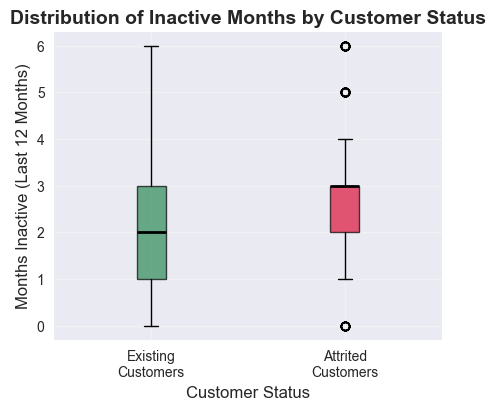

In [38]:

# 1. Box plot showing distribution of inactive months by attrition status
box_data = [existing_customers, attrited_customers]
box_labels = ['Existing\nCustomers', 'Attrited\nCustomers']

fig, ax1 = plt.subplots(figsize=(5, 4))
bp = ax1.boxplot(box_data, labels=box_labels, patch_artist=True)
ax1.set_title('Distribution of Inactive Months by Customer Status', fontsize=14, fontweight='bold')
ax1.set_xlabel('Customer Status', fontsize=12)
ax1.set_ylabel('Months Inactive (Last 12 Months)', fontsize=12)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)

plt.grid(alpha=0.3)
plt.show()


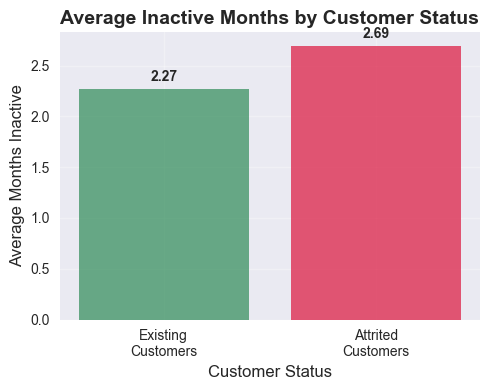

In [39]:

inactivity_df = new_df.copy()

# Filter out any missing values
inactivity_df = inactivity_df[inactivity_df['Months_Inactive_12_mon'].notna()]
inactivity_df = inactivity_df[inactivity_df['Attrition_Flag'].notna()]

# Calculate averages for each customer type
existing_customers = inactivity_df[inactivity_df['Attrition_Flag'] == 'Existing Customer']['Months_Inactive_12_mon']
attrited_customers = inactivity_df[inactivity_df['Attrition_Flag'] == 'Attrited Customer']['Months_Inactive_12_mon']

# Calculate the average inactive months for each group
avg_existing = existing_customers.mean()
avg_attrited = attrited_customers.mean()

# Store in correct order: [Existing, Attrited]
avg_inactive = [avg_existing, avg_attrited]

# Create the bar chart
colors = ['#2E8B57', '#DC143C']
fig, ax2 = plt.subplots(figsize=(5, 4))
bars = ax2.bar(range(len(avg_inactive)), avg_inactive, color=colors, alpha=0.7)

ax2.set_title('Average Inactive Months by Customer Status', fontsize=14, fontweight='bold')
ax2.set_xlabel('Customer Status', fontsize=12)
ax2.set_ylabel('Average Months Inactive', fontsize=12)
ax2.set_xticks(range(len(avg_inactive)))
ax2.set_xticklabels(['Existing\nCustomers', 'Attrited\nCustomers'])

# Add value labels on bars
for bar, value in zip(bars, avg_inactive):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{value:.2f}', ha='center', va='bottom', fontweight='bold')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

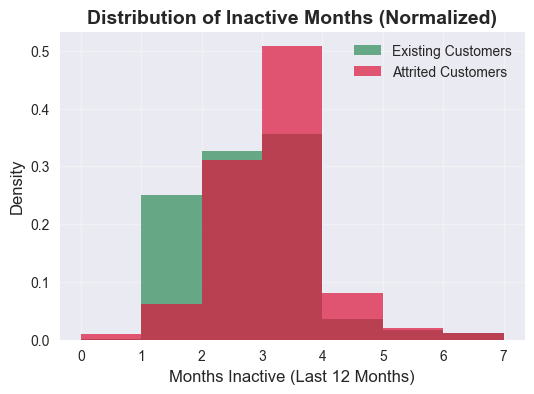

In [40]:

# 3. Histogram showing distribution of inactive months for both groups
fig, ax3 = plt.subplots(figsize=(6, 4))
bins = range(0, int(inactivity_df['Months_Inactive_12_mon'].max()) + 2)

ax3.hist(existing_customers, bins=bins, alpha=0.7, label='Existing Customers', color=colors[0], density=True)
ax3.hist(attrited_customers, bins=bins, alpha=0.7, label='Attrited Customers', color=colors[1], density=True)

ax3.set_title('Distribution of Inactive Months (Normalized)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Months Inactive (Last 12 Months)', fontsize=12)
ax3.set_ylabel('Density', fontsize=12)
ax3.legend()
ax3.grid(alpha=0.3)

plt.show()


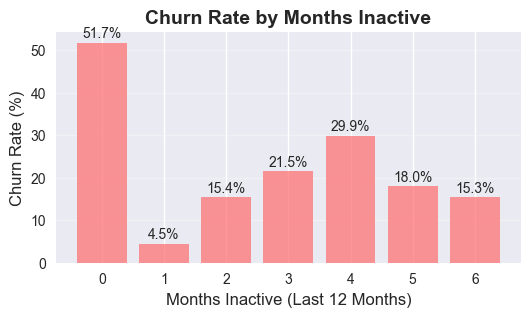

In [41]:

# 4. Churn rate by inactive months
inactive_months_range = sorted(inactivity_df['Months_Inactive_12_mon'].unique())
churn_rates = []

for months in inactive_months_range:
    subset = inactivity_df[inactivity_df['Months_Inactive_12_mon'] == months]
    total_customers = len(subset)
    attrited_customers_count = len(subset[subset['Attrition_Flag'] == 'Attrited Customer'])
    churn_rate = (attrited_customers_count / total_customers) * 100 if total_customers > 0 else 0
    churn_rates.append(churn_rate)

fig, ax4 = plt.subplots(figsize=(6, 3))
bars4 = ax4.bar(inactive_months_range, churn_rates, color='#FF6B6B', alpha=0.7)
ax4.set_title('Churn Rate by Months Inactive', fontsize=14, fontweight='bold')
ax4.set_xlabel('Months Inactive (Last 12 Months)', fontsize=12)
ax4.set_ylabel('Churn Rate (%)', fontsize=12)
ax4.set_xticks(inactive_months_range)

for bar, value in zip(bars4, churn_rates):
    if value > 0:
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 f'{value:.1f}%', ha='center', va='bottom', fontsize=10)

ax4.grid(axis='y', alpha=0.3)
plt.show()


In [42]:

# Print detailed statistics
print("=" * 70)
print("CUSTOMER INACTIVITY vs CHURN ANALYSIS")
print("=" * 70)

print(f"\nTotal customers analyzed: {len(inactivity_df):,}")

print(f"\nInactive Months Statistics by Customer Status:")
print("-" * 50)

stats_by_status = inactivity_df.groupby('Attrition_Flag')['Months_Inactive_12_mon'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)

for status in stats_by_status.index:
    row = stats_by_status.loc[status]
    print(f"\n{status}:")
    print(f"  Count: {row['count']:,}")
    print(f"  Average Inactive Months: {row['mean']:.2f}")
    print(f"  Median Inactive Months: {row['median']:.2f}")
    print(f"  Std Deviation: {row['std']:.2f}")
    print(f"  Range: {row['min']:.0f} - {row['max']:.0f} months")

# Print breakdown of attrited vs existing by each inactivity month
print("\nBreakdown by Months Inactive:")
print("-" * 50)
inactive_counts = inactivity_df.groupby(['Months_Inactive_12_mon', 'Attrition_Flag']).size().unstack(fill_value=0)

# Print headers
print(f"{'Months Inactive':<18}{'Existing Customers':>20}{'Attrited Customers':>22}")
print("-" * 60)

for month in sorted(inactive_counts.index):
    existing = inactive_counts.loc[month].get('Existing Customer', 0)
    attrited = inactive_counts.loc[month].get('Attrited Customer', 0)
    print(f"{month:<18}{existing:>20,}{attrited:>22,}")

# Correlation analysis
inactivity_df['Churn_Binary'] = (inactivity_df['Attrition_Flag'] == 'Attrited Customer').astype(int)
correlation = inactivity_df['Months_Inactive_12_mon'].corr(inactivity_df['Churn_Binary'])

print(f"\nCorrelation between Inactive Months and Churn: {correlation:.3f}")

if correlation > 0.3:
    strength = "strong positive"
elif correlation > 0.1:
    strength = "moderate positive"
elif correlation > -0.1:
    strength = "weak"
elif correlation > -0.3:
    strength = "moderate negative"
else:
    strength = "strong negative"

print(f"Correlation strength: {strength}")



CUSTOMER INACTIVITY vs CHURN ANALYSIS

Total customers analyzed: 10,127

Inactive Months Statistics by Customer Status:
--------------------------------------------------

Attrited Customer:
  Count: 1,627.0
  Average Inactive Months: 2.69
  Median Inactive Months: 3.00
  Std Deviation: 0.90
  Range: 0 - 6 months

Existing Customer:
  Count: 8,500.0
  Average Inactive Months: 2.27
  Median Inactive Months: 2.00
  Std Deviation: 1.02
  Range: 0 - 6 months

Breakdown by Months Inactive:
--------------------------------------------------
Months Inactive     Existing Customers    Attrited Customers
------------------------------------------------------------
0                                   14                    15
1                                2,133                   100
2                                2,777                   505
3                                3,020                   826
4                                  305                   130
5                               

odd that customers with 0 inactive months have such high churn rate, needs to be looked at multi factorily, general sentitment is consistent with idea that less active customer are more likely to churn. Even though there are far more existing customers, the amount of inactive customers at 4+ months are almost equal, suggesting inactive customers are more likely to churn

### Age

In [43]:

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


agecomp_df = new_df.copy()

# Drop rows with missing values in relevant columns
agecomp_df = agecomp_df[agecomp_df['Customer_Age'].notna()]
agecomp_df = agecomp_df[agecomp_df['Attrition_Flag'].notna()]

# Create churn indicator column
agecomp_df['Churn'] = agecomp_df['Attrition_Flag'].apply(lambda x: 1 if x == 'Attrited Customer' else 0)


# Calculate correlation
correlation = agecomp_df['Customer_Age'].corr(agecomp_df['Churn'])
print(f"\nPearson correlation between age and churn: {correlation:.4f}")



Pearson correlation between age and churn: 0.0182


In [44]:
# Create age bins and calculate churn rates
bin_size = 5
min_age = agecomp_df['Customer_Age'].min()
max_age = agecomp_df['Customer_Age'].max()

bins = range(int(min_age), int(max_age) + bin_size, bin_size)
agecomp_df['Age_Group'] = pd.cut(agecomp_df['Customer_Age'], bins=bins, right=False)

# Calculate churn statistics for each age group
age_churn_stats = agecomp_df.groupby('Age_Group').agg({
    'Churn': ['count', 'sum', 'mean'],
    'Customer_Age': 'mean'
}).round(4)

age_churn_stats.columns = ['Total_Customers', 'Churned_Customers', 'Churn_Rate', 'Avg_Age']
age_churn_stats['Churn_Rate_Percent'] = age_churn_stats['Churn_Rate'] * 100


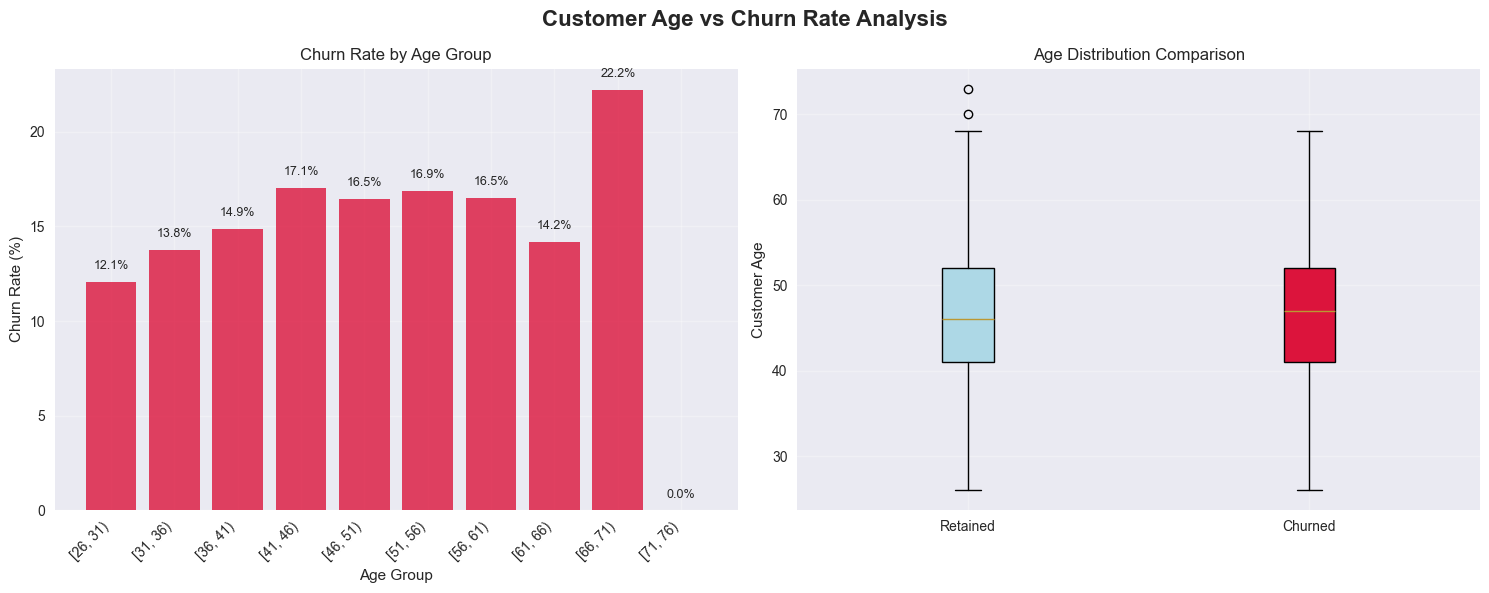

In [45]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Customer Age vs Churn Rate Analysis', fontsize=16, fontweight='bold')

churn_color = '#DC143C'

# 1. Churn rate by age bins (Bar chart)
ax1 = axes[0]
age_groups = [str(group) for group in age_churn_stats.index]
churn_rates = age_churn_stats['Churn_Rate_Percent'].values

bars = ax1.bar(range(len(age_groups)), churn_rates, color=churn_color, alpha=0.8)
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Churn Rate (%)')
ax1.set_title('Churn Rate by Age Group')
ax1.set_xticks(range(len(age_groups)))
ax1.set_xticklabels(age_groups, rotation=45, ha='right')
ax1.grid(True, alpha=0.3)

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# 2. Box plot
ax2 = axes[1]
churn_labels = ['Retained', 'Churned']
age_data = [agecomp_df[agecomp_df['Churn'] == 0]['Customer_Age'], agecomp_df[agecomp_df['Churn'] == 1]['Customer_Age']]

box_plot = ax2.boxplot(age_data, labels=churn_labels, patch_artist=True)
box_plot['boxes'][0].set_facecolor('lightblue')
box_plot['boxes'][1].set_facecolor(churn_color)

ax2.set_ylabel('Customer Age')
ax2.set_title('Age Distribution Comparison')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [46]:

print("\n=== STATISTICAL ANALYSIS ===")

churned_ages = agecomp_df[agecomp_df['Churn'] == 1]['Customer_Age']
retained_ages = agecomp_df[agecomp_df['Churn'] == 0]['Customer_Age']

from scipy import stats
t_stat, p_value = stats.ttest_ind(churned_ages, retained_ages)

print(f"Average age of churned customers: {churned_ages.mean():.1f} years")
print(f"Average age of retained customers: {retained_ages.mean():.1f} years")
print(f"T-test statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Correlation insight
if abs(correlation) > 0.1:
    direction = "positive" if correlation > 0 else "negative"
    strength = "strong" if abs(correlation) > 0.3 else "moderate"
    print(f"There is a {strength} {direction} correlation between age and churn ({correlation:.4f})")
else:
    print("There is little to no linear correlation between age and churn")

# Top 3 age groups by churn rate
age_stats_sorted = age_churn_stats.sort_values('Churn_Rate_Percent', ascending=False)
print(f"\nTop 3 age groups by churn rate:")
for i, (group, row) in enumerate(age_stats_sorted.head(3).iterrows()):
    print(f"   {i+1}. {group}: {row['Churn_Rate_Percent']:.1f}% "
          f"({row['Churned_Customers']}/{row['Total_Customers']} customers)")




=== STATISTICAL ANALYSIS ===
Average age of churned customers: 46.7 years
Average age of retained customers: 46.3 years
T-test statistic: 1.8320
P-value: 0.0670
There is little to no linear correlation between age and churn

Top 3 age groups by churn rate:
   1. [66, 71): 22.2% (2.0/9.0 customers)
   2. [41, 46): 17.1% (386.0/2264.0 customers)
   3. [51, 56): 16.9% (295.0/1747.0 customers)


Customer Distribution by Age Group:
Attrition_Flag  Attrited Customer  Existing Customer
Age_Group                                           
[26, 31)                       32                233
[31, 36)                       90                564
[36, 41)                      220               1258
[41, 46)                      386               1878
[46, 51)                      393               1995
[51, 56)                      295               1452
[56, 61)                      153                773
[61, 66)                       56                339
[66, 71)                        2                  7
[71, 76)                        0                  1

Total Customers: 10127

Churn Rates by Age Group:
[26, 31): 12.1% churn rate (32/265)
[31, 36): 13.8% churn rate (90/654)
[36, 41): 14.9% churn rate (220/1478)
[41, 46): 17.0% churn rate (386/2264)
[46, 51): 16.5% churn rate (393/2388)
[51, 56): 16.9% churn rate (295/1747)
[56, 61): 16.5% churn rate (153/926)
[61, 66): 14.2% 

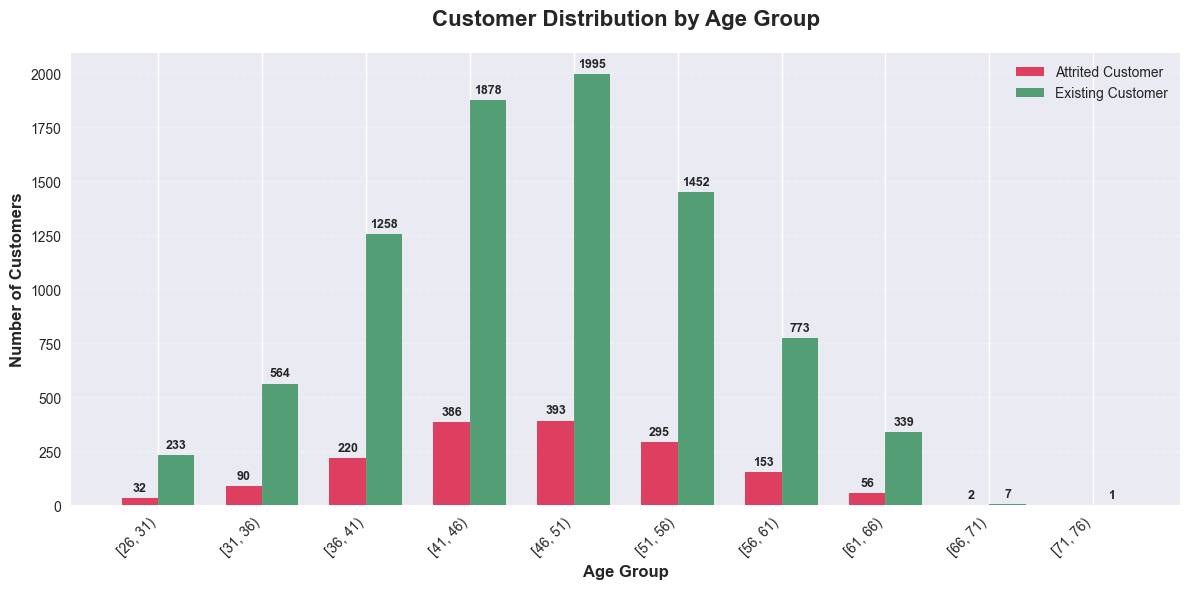

In [47]:

bin_size = 5
min_age = agecomp_df['Customer_Age'].min()
max_age = agecomp_df['Customer_Age'].max()

bins = range(int(min_age), int(max_age) + bin_size, bin_size)
agecomp_df['Age_Group'] = pd.cut(agecomp_df['Customer_Age'], bins=bins, right=False)

# Group by age group and attrition flag
age_attrition_counts = agecomp_df.groupby(['Age_Group', 'Attrition_Flag']).size().unstack(fill_value=0)

# Create the bar chart
fig, ax = plt.subplots(figsize=(12, 6))

# Set up the bar positions
age_groups = [str(group) for group in age_attrition_counts.index]
x_pos = np.arange(len(age_groups))
width = 0.35

# Create bars for each customer type
attrited_bars = ax.bar(x_pos - width/2, age_attrition_counts['Attrited Customer'], 
                      width, label='Attrited Customer', color='#DC143C', alpha=0.8)
existing_bars = ax.bar(x_pos + width/2, age_attrition_counts['Existing Customer'], 
                      width, label='Existing Customer', color='#2E8B57', alpha=0.8)

# Customize the chart
ax.set_title('Customer Distribution by Age Group', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Age Group', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Customers', fontsize=12, fontweight='bold')

# Set x-axis labels
ax.set_xticks(x_pos)
ax.set_xticklabels(age_groups, rotation=45, ha='right')

# Add legend
ax.legend(loc='upper right', fontsize=10)

# Add value labels on bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # Only add labels for non-zero bars
            ax.annotate(f'{int(height)}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),  # 3 points vertical offset
                       textcoords="offset points",
                       ha='center', va='bottom',
                       fontsize=9, fontweight='bold')

add_value_labels(attrited_bars)
add_value_labels(existing_bars)

# Add grid for better readability
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Improve layout
plt.tight_layout()

# Display summary statistics
print("Customer Distribution by Age Group:")
print(age_attrition_counts)
print(f"\nTotal Customers: {age_attrition_counts.sum().sum()}")

# Print churn rate per age group
print("\nChurn Rates by Age Group:")
for age_group in age_attrition_counts.index:
    total = age_attrition_counts.loc[age_group].sum()
    attrited = age_attrition_counts.loc[age_group, 'Attrited Customer']
    churn_rate = (attrited / total) * 100 if total > 0 else 0
    print(f"{age_group}: {churn_rate:.1f}% churn rate ({attrited}/{total})")

plt.show()

although churn rates increase while getting older, there is no strong correlation to make conslusions, especially given the small sample size of the highest churn rate group

### Gender

Hypothesis: There is no significant difference in churn rates between men and women

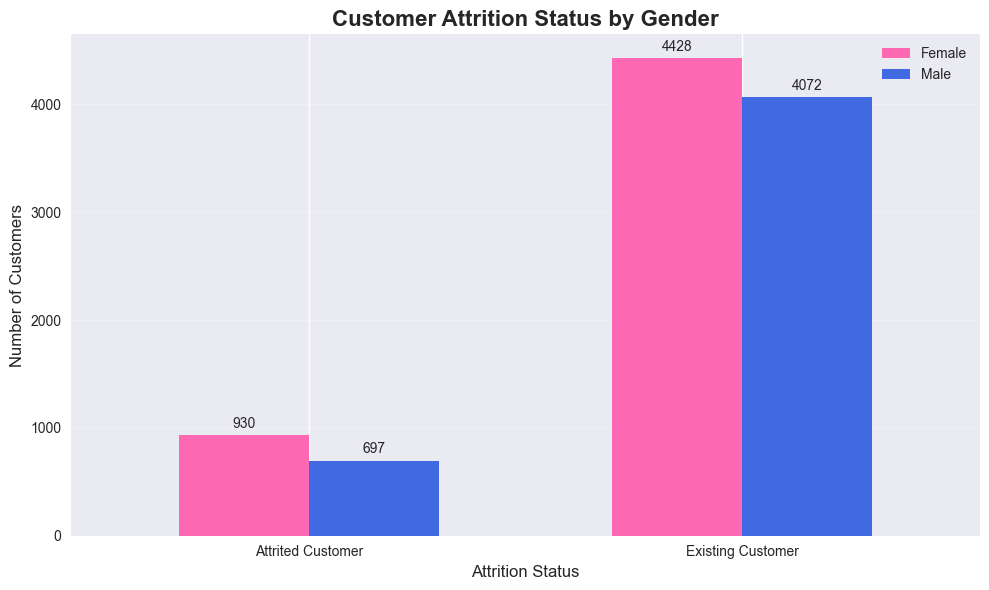

Dataset Summary:
Total customers: 10127
Male customers: 4769
Female customers: 5358
Attrited customers: 1627
Existing customers: 8500

Percentage breakdown by gender:
F: 17.4% attrited, 82.6% existing
M: 14.6% attrited, 85.4% existing

Attrition Status by Gender:
Gender                F     M
Attrition_Flag               
Attrited Customer   930   697
Existing Customer  4428  4072


In [144]:

gender_df = new_df.copy()

# Convert Attrition_Flag to binary (1 for Attrited, 0 for Existing)
gender_df['Attrition_Binary'] = gender_df['Attrition_Flag'].map({'Attrited Customer': 1, 'Existing Customer': 0})

# Convert Gender to binary (1 for Male, 0 for Female)
gender_df['Gender_Binary'] = gender_df['Gender'].map({'M': 1, 'F': 0})

age_bins = [18, 30, 50, 65, float('inf')]
age_labels = ['18-30', '31-50', '51-65', '65+']
gender_df['Age_Group'] = pd.cut(gender_df['Customer_Age'], bins=age_bins, labels=age_labels, right=False)

# Create the bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Group by attrition status and gender, then count
attrition_gender_counts = gender_df.groupby(['Attrition_Flag', 'Gender']).size().unstack(fill_value=0)

# Create the bar chart
attrition_gender_counts.plot(kind='bar', ax=ax, color=['#FF69B4', '#4169E1'], width=0.6)

# Customize the chart
ax.set_title('Customer Attrition Status by Gender', fontsize=16, fontweight='bold')
ax.set_xlabel('Attrition Status', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.legend(['Female', 'Male'], loc='upper right')
ax.tick_params(axis='x', rotation=0)

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

# Adjust layout and display
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Print summary statistics
print("Dataset Summary:")
print(f"Total customers: {len(gender_df)}")
print(f"Male customers: {gender_df['Gender_Binary'].sum()}")
print(f"Female customers: {len(gender_df) - gender_df['Gender_Binary'].sum()}")
print(f"Attrited customers: {gender_df['Attrition_Binary'].sum()}")
print(f"Existing customers: {len(gender_df) - gender_df['Attrition_Binary'].sum()}")

# Calculate percentages by gender and attrition status
gender_attrition_stats = gender_df.groupby(['Gender', 'Attrition_Flag']).size().unstack(fill_value=0)
gender_totals = gender_df.groupby('Gender').size()

print("\nPercentage breakdown by gender:")
for gender in gender_totals.index:
    total = gender_totals[gender]
    if 'Attrited Customer' in gender_attrition_stats.columns:
        attrited = gender_attrition_stats.loc[gender, 'Attrited Customer']
        attrited_pct = (attrited / total) * 100
    else:
        attrited_pct = 0
    
    if 'Existing Customer' in gender_attrition_stats.columns:
        existing = gender_attrition_stats.loc[gender, 'Existing Customer']
        existing_pct = (existing / total) * 100
    else:
        existing_pct = 0
    
    print(f"{gender}: {attrited_pct:.1f}% attrited, {existing_pct:.1f}% existing")

print("\nAttrition Status by Gender:")
print(attrition_gender_counts)


the 3% gap of females being more likely to churn is statistically significant, rejecting my hypothesis

### Marital Status

<Figure size 1000x600 with 0 Axes>

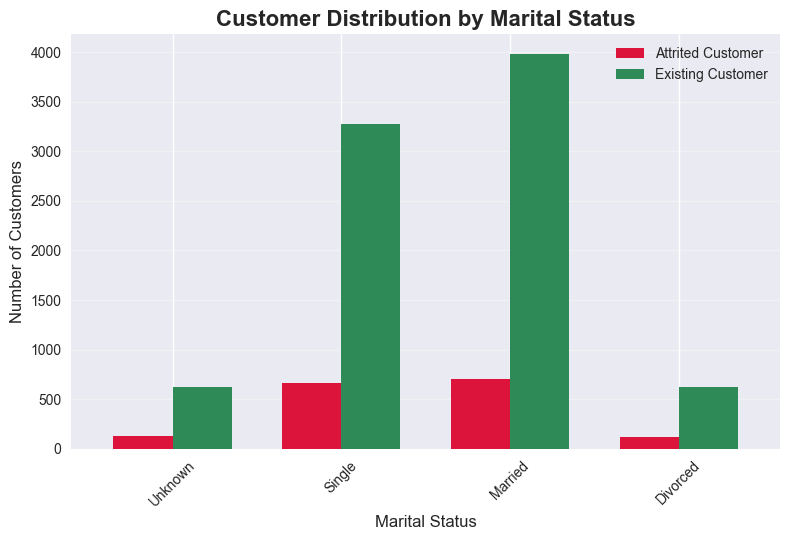


Churn Rates by Marital Status:
Unknown: 17.2% churn rate (129/749)
Single: 16.9% churn rate (668/3943)
Married: 15.1% churn rate (709/4687)
Divorced: 16.2% churn rate (121/748)


In [53]:

marital_df = new_df.copy()

# Create a count of customers by Marital_Status and Attrition_Flag
marital_counts = marital_df.groupby(['Marital_Status', 'Attrition_Flag']).size().unstack(fill_value=0)

# Ensure consistent order of marital statuses
marital_order = ['Unknown', 'Single', 'Married', 'Divorced']
marital_counts = marital_counts.reindex(marital_order)

# Plot the bar chart
plt.figure(figsize=(10, 6))
marital_counts.plot(kind='bar', stacked=False, color=['#DC143C', '#2E8B57'], width=0.7)
plt.title('Customer Distribution by Marital Status', fontsize=16, fontweight='bold')
plt.xlabel('Marital Status', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45)
plt.legend(['Attrited Customer', 'Existing Customer'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate churn rate per marital status
print("\nChurn Rates by Marital Status:")
for status in marital_order:
    if status in marital_counts.index:
        total = marital_counts.loc[status].sum()
        attrited = marital_counts.loc[status].get('Attrited Customer', 0)
        churn_rate = (attrited / total) * 100 if total > 0 else 0
        print(f"{status}: {churn_rate:.1f}% churn rate ({attrited}/{total})")
    else:
        print(f"{status}: 0.0% churn rate (0/0)")

### Dependents

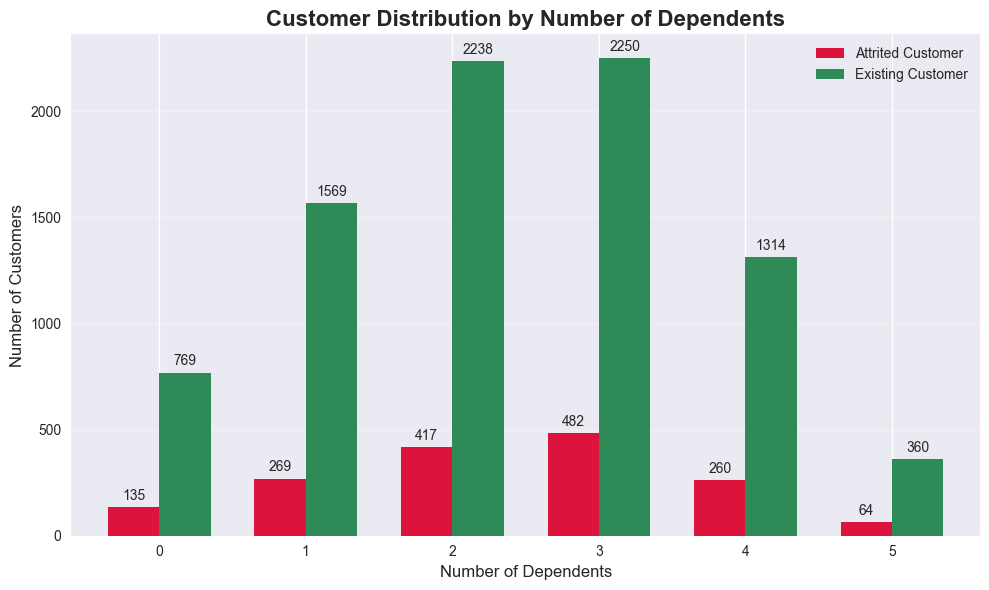


Correlation Analysis
Point Biserial Correlation Coefficient between Dependent_count and Churn: 0.019
P-value: 0.0560
 Not statistically significant.

Churn Rates by Number of Dependents:
0 dependents: 14.9% churn rate (135/904)
1 dependents: 14.6% churn rate (269/1838)
2 dependents: 15.7% churn rate (417/2655)
3 dependents: 17.6% churn rate (482/2732)
4 dependents: 16.5% churn rate (260/1574)
5 dependents: 15.1% churn rate (64/424)


In [54]:

dep_df = new_df.copy()

# Find the maximum number of dependents
max_dependents = dep_df['Dependent_count'].max()

# Create bins for each possible dependent count (0 to max)
bin_labels = list(range(0, max_dependents + 1))
dep_df['Dependent_Bin'] = pd.cut(dep_df['Dependent_count'], 
                                  bins=[i - 0.5 for i in range(0, max_dependents + 2)],
                                  labels=bin_labels)

# Group by dependent bin and attrition status
dep_bin_counts = dep_df.groupby(['Dependent_Bin', 'Attrition_Flag']).size().unstack(fill_value=0)

# Plot the bar chart
fig, ax = plt.subplots(figsize=(10, 6))
dep_bin_counts.plot(kind='bar', ax=ax, color=['#DC143C', '#2E8B57'], width=0.7)

ax.set_title('Customer Distribution by Number of Dependents', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Dependents', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.legend(['Attrited Customer', 'Existing Customer'], loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=0)


for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

# Correlation between Dependent_count and churn
dep_df['Churn_Binary'] = dep_df['Attrition_Flag'].apply(lambda x: 1 if x == 'Attrited Customer' else 0)
r, p_value = pointbiserialr(dep_df['Dependent_count'], dep_df['Churn_Binary'])

print("\nCorrelation Analysis")
print("=" * 50)
print(f"Point Biserial Correlation Coefficient between Dependent_count and Churn: {r:.3f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print(" Statistically significant correlation.")
else:
    print(" Not statistically significant.")

# Calculate churn rate by number of dependents
print("\nChurn Rates by Number of Dependents:") 
for dep in bin_labels:
    if dep in dep_bin_counts.index:
        total = dep_bin_counts.loc[dep].sum()
        attrited = dep_bin_counts.loc[dep].get('Attrited Customer', 0)
        churn_rate = (attrited / total) * 100 if total > 0 else 0
        print(f"{dep} dependents: {churn_rate:.1f}% churn rate ({attrited}/{total})")
    else:
        print(f"{dep} dependents: 0.0% churn rate (0/0)")


### Transaction Amount

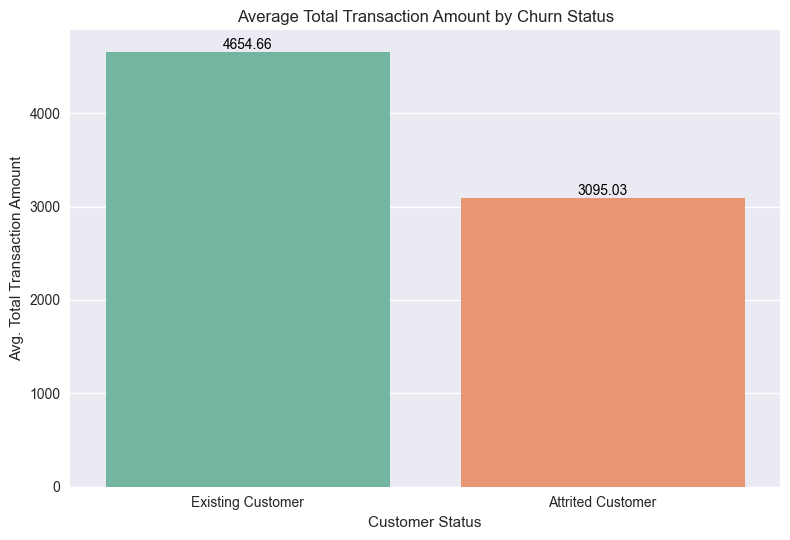

In [55]:

bar2_df = new_df.copy()
bar2_df['Churn'] = bar2_df['Attrition_Flag'].apply(lambda x: 1 if x == 'Attrited Customer' else 0)

avg_trans_amt = bar2_df.groupby('Churn')['Total_Trans_Amt'].mean().reset_index()
avg_trans_amt['Churn_Label'] = avg_trans_amt['Churn'].map({0: 'Existing Customer', 1: 'Attrited Customer'})


ax = sns.barplot(x='Churn_Label', y='Total_Trans_Amt', data=avg_trans_amt, palette='Set2')
plt.title('Average Total Transaction Amount by Churn Status')
plt.xlabel('Customer Status')
plt.ylabel('Avg. Total Transaction Amount')
plt.tight_layout()


for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, color='black')


Churn Rates by Transaction Amount Bin:
0-999: 88.3% churn rate (143/162)
1000-1999: 16.1% churn rate (329/2046)
2000-2999: 48.1% churn rate (812/1689)
3000-3999: 2.4% churn rate (34/1391)
4000-4999: 1.8% churn rate (53/2952)
5000-5999: 7.1% churn rate (31/437)
6000-6999: 68.0% churn rate (17/25)
7000-7999: 16.3% churn rate (55/337)
8000-8999: 35.7% churn rate (96/269)
9000-9999: 75.8% churn rate (47/62)
10001+: 1.3% churn rate (10/757)

Transaction Amount Summary:
- Minimum Transaction Amount: $510.00
- Maximum Transaction Amount: $18,484.00


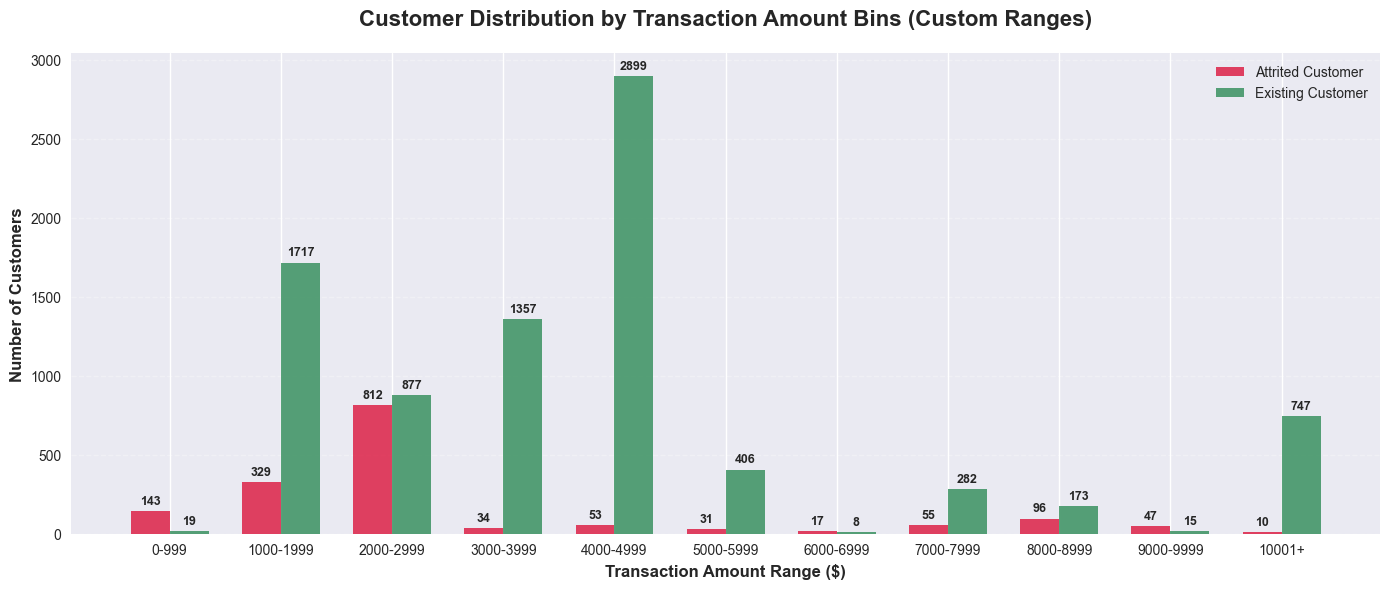

In [57]:
transamt_df = new_df.copy()

# Define custom bin edges
bin_edges = list(range(0, 10001, 1000)) + [float('inf')]
bin_labels = [f'{start}-{end-1}' for start, end in zip(bin_edges[:-2], bin_edges[1:-1])] + ['10001+']

# Create bins using pd.cut with custom edges
bins = pd.cut(transamt_df['Total_Trans_Amt'], bins=bin_edges, labels=bin_labels, include_lowest=True)
transamt_df['Bin'] = bins

# Group by bin and attrition status
bin_attrition_counts = transamt_df.groupby(['Bin', 'Attrition_Flag']).size().unstack(fill_value=0)

# Ensure all bins are present in the correct order
bin_attrition_counts = bin_attrition_counts.reindex(bin_labels, fill_value=0)

# Create the bar chart
fig, ax = plt.subplots(figsize=(14, 6))

# Set up the bar positions
x_pos = np.arange(len(bin_labels))
width = 0.35

# Create bars for each customer type
attrited_bars = ax.bar(x_pos - width/2, bin_attrition_counts['Attrited Customer'],
                       width, label='Attrited Customer', color='#DC143C', alpha=0.8)
existing_bars = ax.bar(x_pos + width/2, bin_attrition_counts['Existing Customer'],
                       width, label='Existing Customer', color='#2E8B57', alpha=0.8)

# Customize the chart
ax.set_title('Customer Distribution by Transaction Amount Bins (Custom Ranges)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Transaction Amount Range ($)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Customers', fontsize=12, fontweight='bold')

# Set x-axis labels
ax.set_xticks(x_pos)
ax.set_xticklabels(bin_labels)

# Add legend
ax.legend(loc='upper right', fontsize=10)

# Add value labels on bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),  # 3 points vertical offset
                   textcoords="offset points",
                   ha='center', va='bottom',
                   fontsize=9, fontweight='bold')

add_value_labels(attrited_bars)
add_value_labels(existing_bars)

# Add grid for better readability
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Improve layout
plt.tight_layout()

# Print churn rate per bin
print("\nChurn Rates by Transaction Amount Bin:")
for bin_name in bin_labels:
    total = bin_attrition_counts.loc[bin_name].sum()
    attrited = bin_attrition_counts.loc[bin_name, 'Attrited Customer']
    churn_rate = (attrited / total) * 100 if total > 0 else 0
    print(f"{bin_name}: {churn_rate:.1f}% churn rate ({attrited}/{total})")

# Print overall min and max transaction amount
min_amt = transamt_df['Total_Trans_Amt'].min()
max_amt = transamt_df['Total_Trans_Amt'].max()
print(f"\nTransaction Amount Summary:")
print(f"- Minimum Transaction Amount: ${min_amt:,.2f}")
print(f"- Maximum Transaction Amount: ${max_amt:,.2f}")

plt.show()


-correlation with attrition -0.17 weak


In [59]:

# Create a copy of the dataframe with required columns
avgtranssize_df = new_df[['Attrition_Flag', 'Total_Trans_Amt', 'Total_Trans_Ct']].copy()

# Step 1: Convert Attrition_Flag to binary
# 1 for 'Attrited Customer', 0 for 'Existing Customer'
avgtranssize_df['Attrition_Flag'] = avgtranssize_df['Attrition_Flag'].map({
    'Attrited Customer': 1,
    'Existing Customer': 0
})

# Step 2: Calculate average transaction size
avgtranssize_df['Avg_Trans_Size'] = avgtranssize_df['Total_Trans_Amt'] / avgtranssize_df['Total_Trans_Ct']

# Handle division by zero (if any transactions have 0 count)
avgtranssize_df['Avg_Trans_Size'] = avgtranssize_df['Avg_Trans_Size'].replace([np.inf, -np.inf], np.nan)

# Step 3: Summary of findings - Overall average transaction size
print("=== SUMMARY OF FINDINGS ===")
print("\nOverall Average Transaction Size by Customer Type:")
print("-" * 50)


attrited_avg = avgtranssize_df[avgtranssize_df['Attrition_Flag'] == 1]['Avg_Trans_Size'].mean()
existing_avg = avgtranssize_df[avgtranssize_df['Attrition_Flag'] == 0]['Avg_Trans_Size'].mean()

print(f"Attrited Customers: ${attrited_avg:.2f}")
print(f"Existing Customers: ${existing_avg:.2f}")
print(f"Difference: ${existing_avg - attrited_avg:.2f}")


=== SUMMARY OF FINDINGS ===

Overall Average Transaction Size by Customer Type:
--------------------------------------------------
Attrited Customers: $63.59
Existing Customers: $62.43
Difference: $-1.17




Average Transaction Size by Transaction Amount Bins:
------------------------------------------------------------
               Existing Customer  Attrited Customer
Trans_Amt_Bin                                      
0-999                      44.17              41.96
1000-1999                  44.26              45.49
2000-2999                  45.50              56.03
3000-3999                  53.41              68.76
4000-4999                  59.34              87.98
5000-5999                  65.57              89.66
6000-6999                  80.91             102.93
7000-7999                  87.44             111.58
8000-8999                  91.06             119.51
9000-9999                  91.68             134.54
10001+                    134.28             154.21


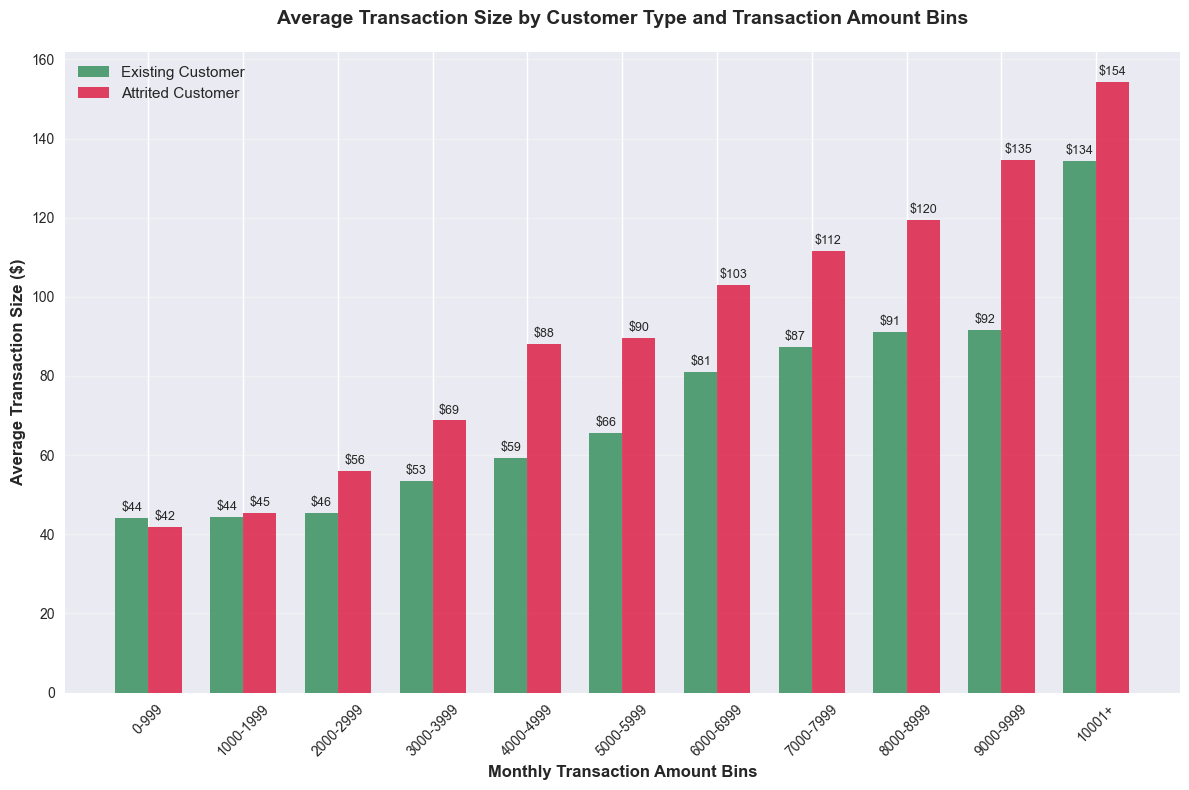

In [60]:

# Define custom bin edges
bin_edges = list(range(0, 10001, 1000)) + [float('inf')]
bin_labels = [f'{start}-{end-1}' for start, end in zip(bin_edges[:-2], bin_edges[1:-1])] + ['10001+']
# Create transaction amount bins
avgtranssize_df['Trans_Amt_Bin'] = pd.cut(avgtranssize_df['Total_Trans_Amt'], 
                                         bins=bin_edges, 
                                         labels=bin_labels, 
                                         right=True, 
                                         include_lowest=True)

# Step 5: Calculate average transaction size by bin and customer type
bin_analysis = avgtranssize_df.groupby(['Trans_Amt_Bin', 'Attrition_Flag'])['Avg_Trans_Size'].mean().reset_index()

# Pivot for easier plotting
bin_pivot = bin_analysis.pivot(index='Trans_Amt_Bin', columns='Attrition_Flag', values='Avg_Trans_Size')
bin_pivot.columns = ['Existing Customer', 'Attrited Customer']

print(f"\n\nAverage Transaction Size by Transaction Amount Bins:")
print("-" * 60)
print(bin_pivot.round(2))

# Step 6: Create visualization
plt.figure(figsize=(12, 8))

# Define colors
colors = {'Attrited Customer': '#DC143C', 'Existing Customer': '#2E8B57'}

# Create bar plot
x = np.arange(len(bin_labels))
width = 0.35

existing_values = bin_pivot['Existing Customer'].values
attrited_values = bin_pivot['Attrited Customer'].values

plt.bar(x - width/2, existing_values, width, label='Existing Customer', 
        color=colors['Existing Customer'], alpha=0.8)
plt.bar(x + width/2, attrited_values, width, label='Attrited Customer', 
        color=colors['Attrited Customer'], alpha=0.8)

# Customize the plot
plt.xlabel('Monthly Transaction Amount Bins', fontsize=12, fontweight='bold')
plt.ylabel('Average Transaction Size ($)', fontsize=12, fontweight='bold')
plt.title('Average Transaction Size by Customer Type and Transaction Amount Bins', 
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(x, bin_labels, rotation=45)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (existing_val, attrited_val) in enumerate(zip(existing_values, attrited_values)):
    if not pd.isna(existing_val):
        plt.text(i - width/2, existing_val + 1, f'${existing_val:.0f}', 
                ha='center', va='bottom', fontsize=9)
    if not pd.isna(attrited_val):
        plt.text(i + width/2, attrited_val + 1, f'${attrited_val:.0f}', 
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [62]:


# Show distribution across bins
print(f"\nCustomer Distribution by Transaction Amount Bins:")
print("-" * 50)
bin_distribution = avgtranssize_df.groupby(['Trans_Amt_Bin', 'Attrition_Flag']).size().unstack(fill_value=0)
bin_distribution.columns = ['Existing Customer', 'Attrited Customer']
print(bin_distribution)



Customer Distribution by Transaction Amount Bins:
--------------------------------------------------
               Existing Customer  Attrited Customer
Trans_Amt_Bin                                      
0-999                         19                143
1000-1999                   1717                329
2000-2999                    877                812
3000-3999                   1357                 34
4000-4999                   2899                 53
5000-5999                    406                 31
6000-6999                      8                 17
7000-7999                    282                 55
8000-8999                    173                 96
9000-9999                     15                 47
10001+                       747                 10


In [63]:

# Remove any rows with NaN values in key columns
correlation_df = avgtranssize_df.dropna(subset=['Avg_Trans_Size', 'Attrition_Flag']).copy()
# Pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(correlation_df['Avg_Trans_Size'], correlation_df['Attrition_Flag'])
print(f"Pearson Correlation Coefficient: {pearson_corr:.4f}")
print(f"Pearson p-value: {pearson_p:.6f}")

print(f"\n Correlation Strength:")
if abs(pearson_corr) < 0.1:
    corr_strength = "Very weak"
elif abs(pearson_corr) < 0.3:
    corr_strength = "Weak"
elif abs(pearson_corr) < 0.5:
    corr_strength = "Moderate"
elif abs(pearson_corr) < 0.7:
    corr_strength = "Strong"
else:
    corr_strength = "Very strong"

print(f"  Pearson correlation shows {corr_strength.lower()} {'positive' if pearson_corr > 0 else 'negative'} relationship")




Pearson Correlation Coefficient: 0.0162
Pearson p-value: 0.102098

 Correlation Strength:
  Pearson correlation shows very weak positive relationship


-those who earn more are also spending in bigger chunks, however overall transaction size has no correlation with churn rate
-find exact corr function method and if similarities or prior knowledge required 

### Transaction Count

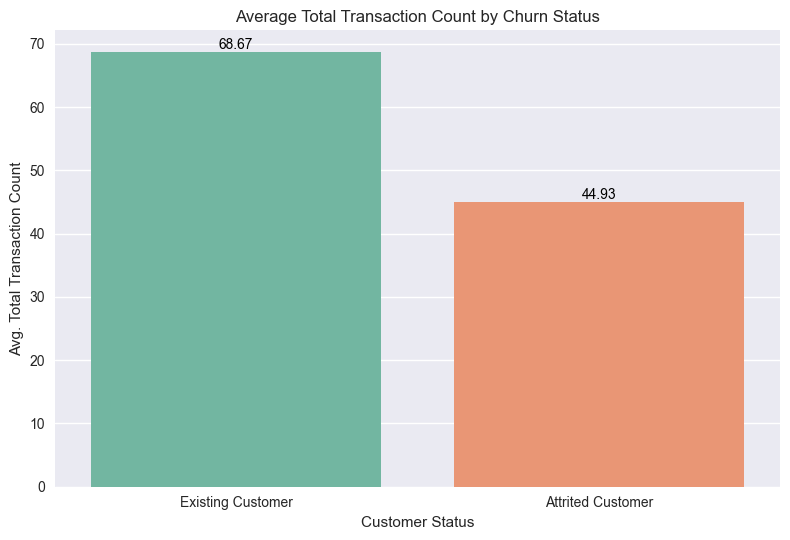

In [64]:

bar3_df = new_df.copy()
bar3_df['Churn'] = bar3_df['Attrition_Flag'].apply(lambda x: 1 if x == 'Attrited Customer' else 0)


avg_trans_ct = bar3_df.groupby('Churn')['Total_Trans_Ct'].mean().reset_index()
avg_trans_ct['Churn_Label'] = avg_trans_ct['Churn'].map({0: 'Existing Customer', 1: 'Attrited Customer'})

ax = sns.barplot(x='Churn_Label', y='Total_Trans_Ct', data=avg_trans_ct, palette='Set2')
plt.title('Average Total Transaction Count by Churn Status')
plt.xlabel('Customer Status')
plt.ylabel('Avg. Total Transaction Count')
plt.tight_layout()


for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, color='black')

plt.show()

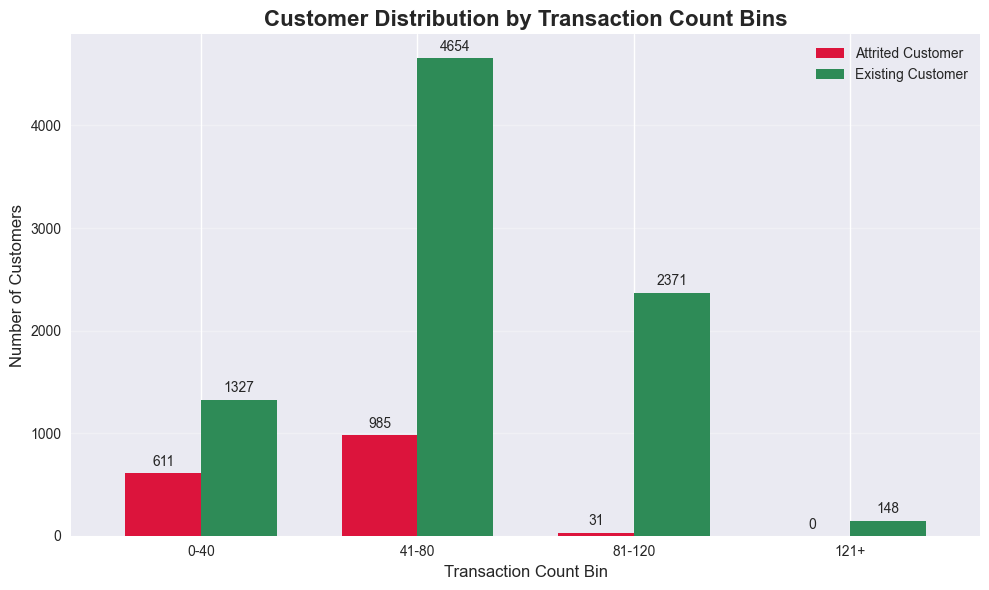


TRANSACTION COUNT BIN ANALYSIS

Total customers: 10127
Minimum Transaction Count: 10
Maximum Transaction Count: 139

0-40: 1938 customers, 31.5% churn rate (611/1938)
41-80: 5639 customers, 17.5% churn rate (985/5639)
81-120: 2402 customers, 1.3% churn rate (31/2402)
121+: 148 customers, 0.0% churn rate (0/148)

Average transaction counts by attrition status:
Existing Customer: 68.7 average transactions
Attrited Customer: 44.9 average transactions


In [143]:

trans_df = new_df.copy()

# Define custom bins and labels
bin_edges = [0, 40, 80, 120, float('inf')]
bin_labels = ['0-40', '41-80', '81-120', '121+']

# Bin the Total_Trans_Ct column
trans_df['Trans_Ct_Bin'] = pd.cut(trans_df['Total_Trans_Ct'], bins=bin_edges, labels=bin_labels, right=True, include_lowest=True)

# Group by bin and attrition status
bin_attrition_counts = trans_df.groupby(['Trans_Ct_Bin', 'Attrition_Flag']).size().unstack(fill_value=0)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bin_attrition_counts.plot(kind='bar', ax=ax, color=['#DC143C', '#2E8B57'], width=0.7)

ax.set_title('Customer Distribution by Transaction Count Bins', fontsize=16, fontweight='bold')
ax.set_xlabel('Transaction Count Bin', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.legend(['Attrited Customer', 'Existing Customer'], loc='upper right')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.3)

# Set x-axis labels
ax.set_xticklabels(bin_labels)

# Bar labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*60)
print("TRANSACTION COUNT BIN ANALYSIS")
print("="*60)
print(f"\nTotal customers: {len(trans_df)}")

# Print min and max transaction count
min_ct = trans_df['Total_Trans_Ct'].min()
max_ct = trans_df['Total_Trans_Ct'].max()
print(f"Minimum Transaction Count: {min_ct}")
print(f"Maximum Transaction Count: {max_ct}\n")

# Percentages per bin
for bin_label in bin_labels:
    total = trans_df[trans_df['Trans_Ct_Bin'] == bin_label].shape[0]
    attrited = trans_df[(trans_df['Trans_Ct_Bin'] == bin_label) & (trans_df['Attrition_Flag'] == 'Attrited Customer')].shape[0]
    churn_rate = (attrited / total) * 100 if total > 0 else 0
    print(f"{bin_label}: {total} customers, {churn_rate:.1f}% churn rate ({attrited}/{total})")

# Average transaction count by attrition status
print(f"\nAverage transaction counts by attrition status:")
for status in ['Existing Customer', 'Attrited Customer']:
    avg_ct = trans_df[trans_df['Attrition_Flag'] == status]['Total_Trans_Ct'].mean()
    print(f"{status}: {avg_ct:.1f} average transactions")



### Income Levels

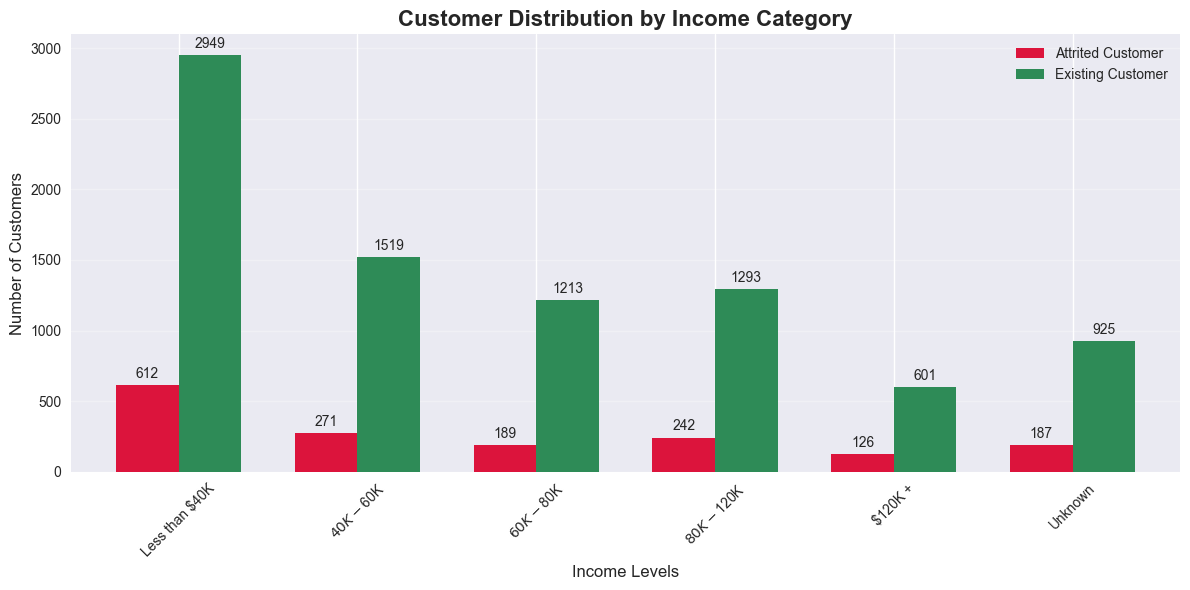


Churn rates by income category:
Less than $40K: 17.2% churn rate (612/3561)
$40K - $60K: 15.1% churn rate (271/1790)
$60K - $80K: 13.5% churn rate (189/1402)
$80K - $120K: 15.8% churn rate (242/1535)
$120K +: 17.3% churn rate (126/727)
Unknown: 16.8% churn rate (187/1112)

Income distribution by attrition status:

Existing Customer:
  Less than $40K: 2949 customers (34.7%)
  $40K - $60K: 1519 customers (17.9%)
  $60K - $80K: 1213 customers (14.3%)
  $80K - $120K: 1293 customers (15.2%)
  $120K +: 601 customers (7.1%)
  Unknown: 925 customers (10.9%)

Attrited Customer:
  Less than $40K: 612 customers (37.6%)
  $40K - $60K: 271 customers (16.7%)
  $60K - $80K: 189 customers (11.6%)
  $80K - $120K: 242 customers (14.9%)
  $120K +: 126 customers (7.7%)
  Unknown: 187 customers (11.5%)

Overall churn rate: 1312.1%


In [66]:



income_df = new_df.copy()

# Define the income category order for proper display
income_order = ['Less than $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', 
                '$120K +', 'Unknown']

# Create the bar chart
fig, ax = plt.subplots(figsize=(12, 6))

# Group by income category and attrition status
income_attrition_counts = income_df.groupby(['Income_Category', 'Attrition_Flag']).size().unstack(fill_value=0)

# Reorder the index to match our desired order
income_attrition_counts = income_attrition_counts.reindex(income_order, fill_value=0)


income_attrition_counts.plot(kind='bar', ax=ax, color=['#DC143C', '#2E8B57'], width=0.7)


ax.set_title('Customer Distribution by Income Category', fontsize=16, fontweight='bold')
ax.set_xlabel('Income Levels', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.legend(['Attrited Customer', 'Existing Customer'], loc='upper right')
ax.tick_params(axis='x', rotation=45)


for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)


ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate churn rates for each category
print(f"\nChurn rates by income category:")
for category in income_order:
    if category in income_df['Income_Category'].values:
        category_data = income_df[income_df['Income_Category'] == category]
        if len(category_data) > 0:
            attrited_count = len(category_data[category_data['Attrition_Flag'] == 'Attrited Customer'])
            total_count = len(category_data)
            churn_rate = (attrited_count / total_count) * 100
            print(f"{category}: {churn_rate:.1f}% churn rate ({attrited_count}/{total_count})")

# Average income statistics by attrition status
print(f"\nIncome distribution by attrition status:")
for status in ['Existing Customer', 'Attrited Customer']:
    status_data = income_df[income_df['Attrition_Flag'] == status]
    print(f"\n{status}:")
    income_dist = status_data['Income_Category'].value_counts()
    for income_cat in income_order:
        if income_cat in income_dist.index:
            count = income_dist[income_cat]
            percentage = (count / len(status_data)) * 100
            print(f"  {income_cat}: {count} customers ({percentage:.1f}%)")


total_attrited = len(income_df[income_df['Attrition_Flag'] == 'Attrited Customer'])
overall_churn_rate = (total_attrited / total_customers) * 100
print(f"\nOverall churn rate: {overall_churn_rate:.1f}%")


 as income increases, churn rate slighty drops, however the 80-120k range has a higher churn rate than 60-80k, possibly contradicting this, check sigificance

### Trns Count Change

Loading and preparing your dataset...
Total_Ct_Chng_Q4_Q1- Ratio of transaction count in Q4 vs. Q1 1= No change, >1 = Increase in transactions, <1 = Decrease
=== DATASET OVERVIEW ===
Total customers: 10127
Churned customers: 1627
Overall churn rate: 16.07%
Average transaction change ratio: 0.712
Transaction change ratio range: 0.000 - 3.714

Pearson correlation between transaction change ratio and churn: -0.2901


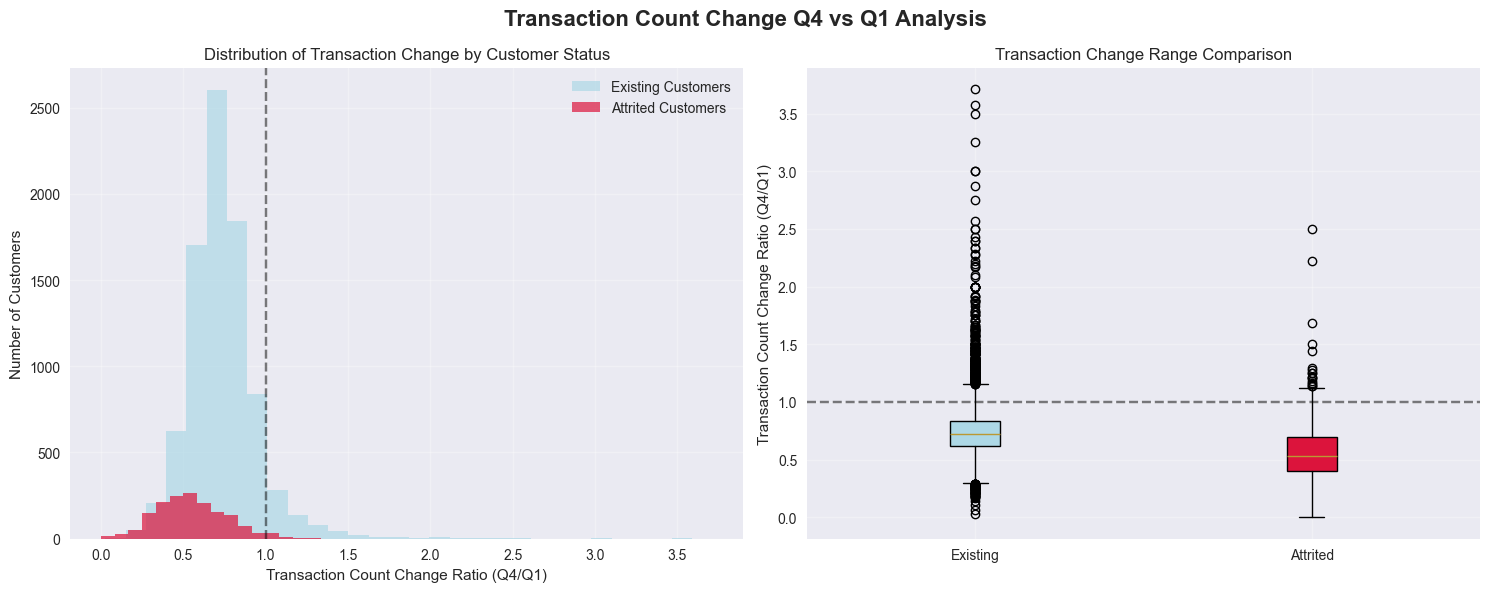


=== STATISTICAL ANALYSIS ===
Existing Customers:
  Mean transaction change ratio: 0.742
  Median transaction change ratio: 0.721

Attrited Customers:
  Mean transaction change ratio: 0.554
  Median transaction change ratio: 0.531
Transaction Change Patterns:
Existing Customers:
  - Increased transactions (>1.0): 7.4%
  - Decreased transactions (<1.0): 90.9%
  - Stable transactions (=1.0): 1.8%

Attrited Customers:
  - Increased transactions (>1.0): 2.6%
  - Decreased transactions (<1.0): 96.4%
  - Stable transactions (=1.0): 1.0%

Correlation Analysis:
There is a moderate negative correlation between transaction change ratio and churn (-0.2901)


In [67]:

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Loading and preparing your dataset...")
countchange_df = new_df.copy()

# Create binary churn column
countchange_df['Churn'] = countchange_df['Attrition_Flag'].apply(lambda x: 1 if x == 'Attrited Customer' else 0)

# Use the existing dataframe
df = countchange_df

# Basic dataset overview
print("Total_Ct_Chng_Q4_Q1- Ratio of transaction count in Q4 vs. Q1 1= No change, >1 = Increase in transactions, <1 = Decrease")
print("=== DATASET OVERVIEW ===")
print(f"Total customers: {len(df)}")
print(f"Churned customers: {df['Churn'].sum()}")
print(f"Overall churn rate: {df['Churn'].mean():.2%}")
print(f"Average transaction change ratio: {df['Total_Ct_Chng_Q4_Q1'].mean():.3f}")
print(f"Transaction change ratio range: {df['Total_Ct_Chng_Q4_Q1'].min():.3f} - {df['Total_Ct_Chng_Q4_Q1'].max():.3f}")

# Calculate correlation
correlation = df['Total_Ct_Chng_Q4_Q1'].corr(df['Churn'])
print(f"\nPearson correlation between transaction change ratio and churn: {correlation:.4f}")

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Transaction Count Change Q4 vs Q1 Analysis', fontsize=16, fontweight='bold')

churn_color = '#DC143C'
retain_color = 'lightblue'

# 1. Histogram showing distribution by churn status
ax1 = axes[0]
existing_data = df[df['Churn'] == 0]['Total_Ct_Chng_Q4_Q1']
attrited_data = df[df['Churn'] == 1]['Total_Ct_Chng_Q4_Q1']

ax1.hist(existing_data, alpha=0.7, bins=30, label='Existing Customers', color=retain_color)
ax1.hist(attrited_data, alpha=0.7, bins=30, label='Attrited Customers', color=churn_color)

ax1.set_xlabel('Transaction Count Change Ratio (Q4/Q1)')
ax1.set_ylabel('Number of Customers')
ax1.set_title('Distribution of Transaction Change by Customer Status')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add vertical line at ratio = 1.0 (no change)
ax1.axvline(x=1.0, color='black', linestyle='--', alpha=0.5, label='No Change (1.0)')

# 2. Box plot comparing ranges
ax2 = axes[1]
customer_labels = ['Existing', 'Attrited']
transaction_data = [existing_data, attrited_data]

box_plot = ax2.boxplot(transaction_data, labels=customer_labels, patch_artist=True)
box_plot['boxes'][0].set_facecolor(retain_color)
box_plot['boxes'][1].set_facecolor(churn_color)

ax2.set_ylabel('Transaction Count Change Ratio (Q4/Q1)')
ax2.set_title('Transaction Change Range Comparison')
ax2.grid(True, alpha=0.3)

# Add horizontal line at ratio = 1.0 (no change)
ax2.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='No Change (1.0)')

plt.tight_layout()
plt.show()

# Statistical analysis
print("\n=== STATISTICAL ANALYSIS ===")

# Basic statistics for each group
print("Existing Customers:")
print(f"  Mean transaction change ratio: {existing_data.mean():.3f}")
print(f"  Median transaction change ratio: {existing_data.median():.3f}")


print("\nAttrited Customers:")
print(f"  Mean transaction change ratio: {attrited_data.mean():.3f}")
print(f"  Median transaction change ratio: {attrited_data.median():.3f}")


# Calculate percentage of customers with different change patterns
existing_increase = (existing_data > 1.0).mean() * 100
existing_decrease = (existing_data < 1.0).mean() * 100
existing_stable = (existing_data == 1.0).mean() * 100

attrited_increase = (attrited_data > 1.0).mean() * 100
attrited_decrease = (attrited_data < 1.0).mean() * 100
attrited_stable = (attrited_data == 1.0).mean() * 100

print("Transaction Change Patterns:")
print(f"Existing Customers:")
print(f"  - Increased transactions (>1.0): {existing_increase:.1f}%")
print(f"  - Decreased transactions (<1.0): {existing_decrease:.1f}%")
print(f"  - Stable transactions (=1.0): {existing_stable:.1f}%")

print(f"\nAttrited Customers:")
print(f"  - Increased transactions (>1.0): {attrited_increase:.1f}%")
print(f"  - Decreased transactions (<1.0): {attrited_decrease:.1f}%")
print(f"  - Stable transactions (=1.0): {attrited_stable:.1f}%")

# Correlation insights
if abs(correlation) > 0.1:
    direction = "positive" if correlation > 0 else "negative"
    strength = "strong" if abs(correlation) > 0.3 else "moderate" if abs(correlation) > 0.1 else "weak"
    print(f"\nCorrelation Analysis:")
    print(f"There is a {strength} {direction} correlation between transaction change ratio and churn ({correlation:.4f})")
else:
    print(f"\nCorrelation Analysis:")
    print("There is little to no linear correlation between transaction change ratio and churn")


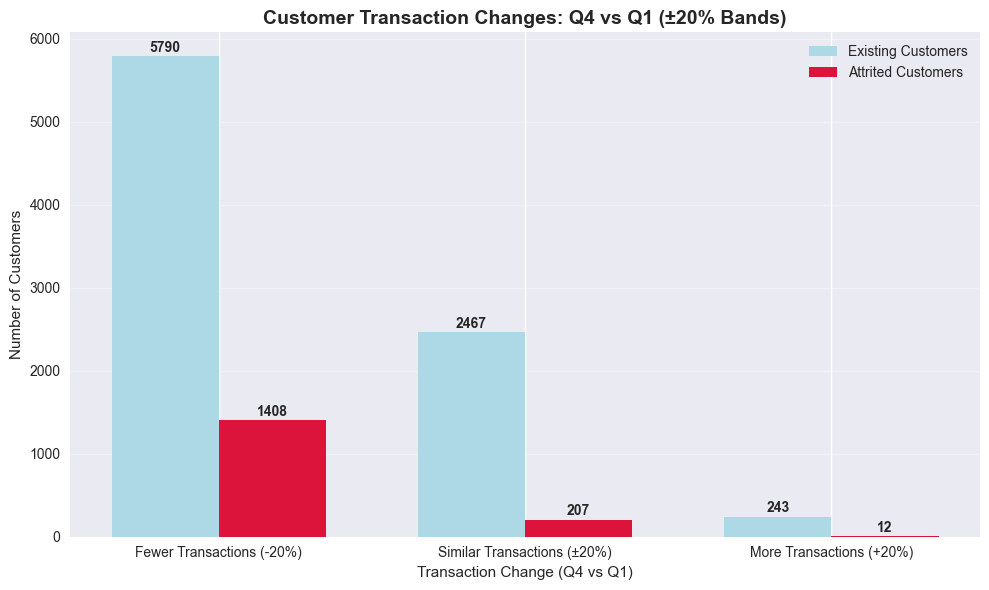

=== TRANSACTION CHANGE SUMMARY (±20% Bands) ===
Total customers analyzed: 10127

Categories explained:
• Fewer Transactions (-20%): Q4 had 20%+ fewer transactions than Q1
• Similar Transactions (±20%): Q4 within ±20% of Q1 transaction count
• More Transactions (+20%): Q4 had 20%+ more transactions than Q1

Fewer Transactions (-20%):
  Total customers: 7198
  Existing: 5790 (80.4%)
  Attrited: 1408 (19.6%)
  Churn rate: 19.6%

Similar Transactions (±20%):
  Total customers: 2674
  Existing: 2467 (92.3%)
  Attrited: 207 (7.7%)
  Churn rate: 7.7%

More Transactions (+20%):
  Total customers: 255
  Existing: 243 (95.3%)
  Attrited: 12 (4.7%)
  Churn rate: 4.7%



In [150]:
# Simple Transaction Change Visualization
plt.style.use('seaborn-v0_8')

# Create categories based on transaction change with +/- 20% tolerance
def categorize_change(ratio):
    if ratio > 1.20:  # More than 20% increase
        return 'More Transactions (+20%)'
    elif ratio < 0.80:  # More than 20% decrease
        return 'Fewer Transactions (-20%)'
    else:  # Within +/- 20% range
        return 'Similar Transactions (±20%)'

# Apply categorization
df['Transaction_Change_Category'] = df['Total_Ct_Chng_Q4_Q1'].apply(categorize_change)

# Count customers in each category by churn status
change_summary = df.groupby(['Transaction_Change_Category', 'Attrition_Flag']).size().unstack(fill_value=0)

# Create simple bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Colors
churn_color = '#DC143C'
retain_color = 'lightblue'

# Create grouped bar chart
categories = ['Fewer Transactions (-20%)', 'Similar Transactions (±20%)', 'More Transactions (+20%)']
x_pos = range(len(categories))

existing_counts = [change_summary.loc[cat, 'Existing Customer'] for cat in categories]
attrited_counts = [change_summary.loc[cat, 'Attrited Customer'] for cat in categories]

width = 0.35
ax.bar([x - width/2 for x in x_pos], existing_counts, width, 
       label='Existing Customers', color=retain_color)
ax.bar([x + width/2 for x in x_pos], attrited_counts, width, 
       label='Attrited Customers', color=churn_color)

ax.set_xlabel('Transaction Change (Q4 vs Q1)')
ax.set_ylabel('Number of Customers')
ax.set_title('Customer Transaction Changes: Q4 vs Q1 (±20% Bands)', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (existing, attrited) in enumerate(zip(existing_counts, attrited_counts)):
    ax.text(i - width/2, existing + 50, str(existing), ha='center', fontweight='bold')
    ax.text(i + width/2, attrited + 50, str(attrited), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print simple summary
print("=== TRANSACTION CHANGE SUMMARY (±20% Bands) ===")
print(f"Total customers analyzed: {len(df)}")
print()
print("Categories explained:")
print("• Fewer Transactions (-20%): Q4 had 20%+ fewer transactions than Q1")
print("• Similar Transactions (±20%): Q4 within ±20% of Q1 transaction count")
print("• More Transactions (+20%): Q4 had 20%+ more transactions than Q1")
print()

for category in categories:
    existing = change_summary.loc[category, 'Existing Customer']
    attrited = change_summary.loc[category, 'Attrited Customer']
    total = existing + attrited
    churn_rate = (attrited / total) * 100
    
    print(f"{category}:")
    print(f"  Total customers: {total}")
    print(f"  Existing: {existing} ({(existing/total)*100:.1f}%)")
    print(f"  Attrited: {attrited} ({(attrited/total)*100:.1f}%)")
    print(f"  Churn rate: {churn_rate:.1f}%")
    print()

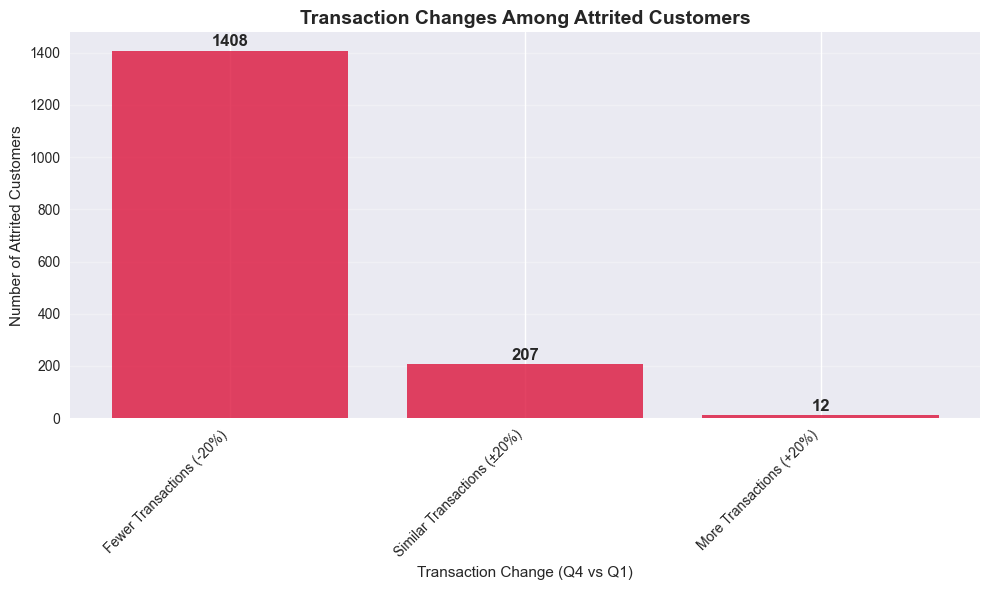

=== TRANSACTION CHANGE SUMMARY - ATTRITED CUSTOMERS ONLY ===
Total attrited customers analyzed: 1627

Categories explained:
• Fewer Transactions (-20%): Q4 had 20%+ fewer transactions than Q1
• Similar Transactions (±20%): Q4 within ±20% of Q1 transaction count
• More Transactions (+20%): Q4 had 20%+ more transactions than Q1

Fewer Transactions (-20%):
  Count: 1408
  Percentage of attrited customers: 86.5%

Similar Transactions (±20%):
  Count: 207
  Percentage of attrited customers: 12.7%

More Transactions (+20%):
  Count: 12
  Percentage of attrited customers: 0.7%

=== KEY INSIGHTS ===
Most common pattern among attrited customers: Fewer Transactions (-20%)
This represents 86.5% of all attrited customers


In [154]:
# Simple Transaction Change Visualization - Attrited Customers Only
plt.style.use('seaborn-v0_8')

# Filter for only attrited customers
attrited_df = df[df['Attrition_Flag'] == 'Attrited Customer'].copy()

# Create categories based on transaction change with +/- 20% tolerance
def categorize_change(ratio):
    if ratio > 1.20:  # More than 20% increase
        return 'More Transactions (+20%)'
    elif ratio < 0.80:  # More than 20% decrease
        return 'Fewer Transactions (-20%)'
    else:  # Within +/- 20% range
        return 'Similar Transactions (±20%)'

# Apply categorization
attrited_df['Transaction_Change_Category'] = attrited_df['Total_Ct_Chng_Q4_Q1'].apply(categorize_change)

# Count attrited customers in each category
change_counts = attrited_df['Transaction_Change_Category'].value_counts()

# Create simple bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Color for attrited customers
churn_color = '#DC143C'

# Create bar chart
categories = ['Fewer Transactions (-20%)', 'Similar Transactions (±20%)', 'More Transactions (+20%)']
counts = [change_counts.get(cat, 0) for cat in categories]

bars = ax.bar(categories, counts, color=churn_color, alpha=0.8)

ax.set_xlabel('Transaction Change (Q4 vs Q1)')
ax.set_ylabel('Number of Attrited Customers')
ax.set_title('Transaction Changes Among Attrited Customers', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 5,
            f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print summary for attrited customers only
print("=== TRANSACTION CHANGE SUMMARY - ATTRITED CUSTOMERS ONLY ===")
print(f"Total attrited customers analyzed: {len(attrited_df)}")
print()
print("Categories explained:")
print("• Fewer Transactions (-20%): Q4 had 20%+ fewer transactions than Q1")
print("• Similar Transactions (±20%): Q4 within ±20% of Q1 transaction count")
print("• More Transactions (+20%): Q4 had 20%+ more transactions than Q1")
print()

total_attrited = len(attrited_df)
for category in categories:
    count = change_counts.get(category, 0)
    percentage = (count / total_attrited) * 100
    
    print(f"{category}:")
    print(f"  Count: {count}")
    print(f"  Percentage of attrited customers: {percentage:.1f}%")
    print()

# Additional insight
print("=== KEY INSIGHTS ===")
most_common = change_counts.idxmax()
most_common_pct = (change_counts.max() / total_attrited) * 100
print(f"Most common pattern among attrited customers: {most_common}")
print(f"This represents {most_common_pct:.1f}% of all attrited customers")

This remains consistent with the theory of less active customers are more likely to churn showing that when engagement decreases over the year churn rate increases. attrited had a lower mean and median although mean can be skewed here due to large number of outliers for both groups

### Trns Amt Change

=== DATASET OVERVIEW ===
Total customers: 10127
Churned customers: 1627
Overall churn rate: 16.07%
Average transaction amount change ratio: 0.760
Transaction amount change ratio range: 0.000 - 3.397

Pearson correlation between transaction amount change ratio and churn: -0.1311


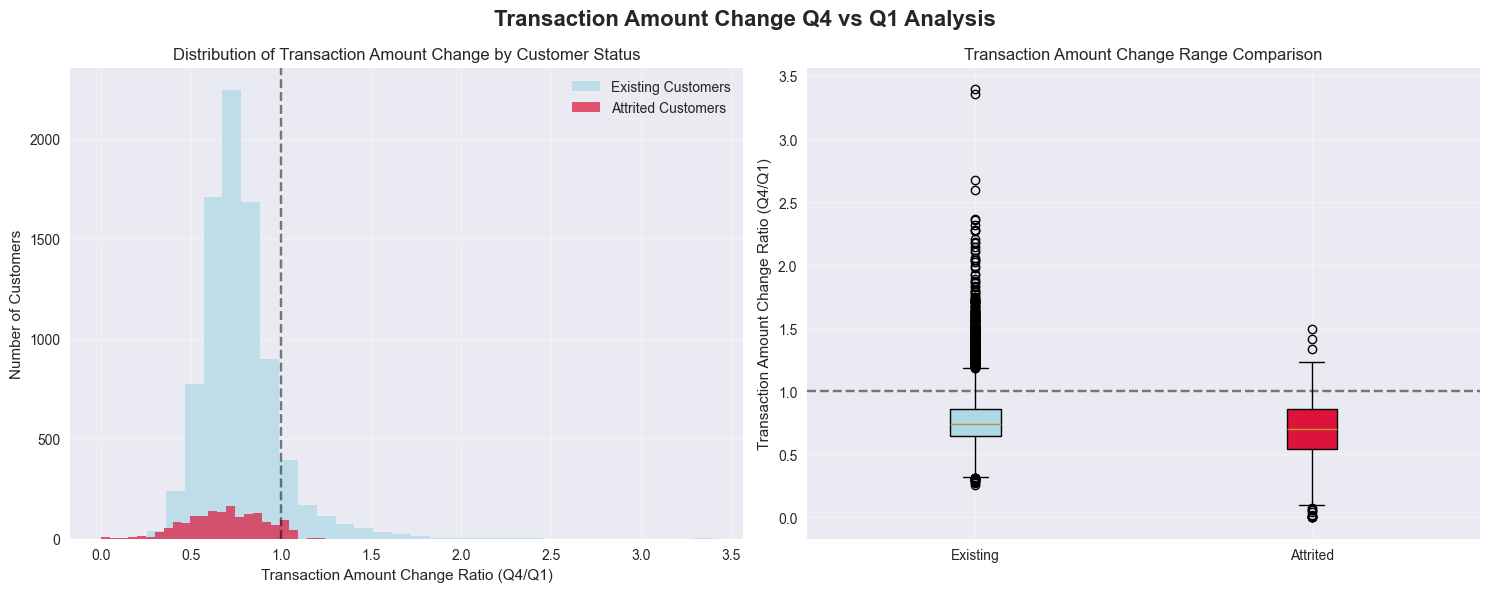


=== STATISTICAL ANALYSIS ===
Existing Customers:
  Mean transaction amount change ratio: 0.773
  Median transaction amount change ratio: 0.743

Attrited Customers:
  Mean transaction amount change ratio: 0.694
  Median transaction amount change ratio: 0.701
Transaction Amount Change Patterns:
Existing Customers:
  - Increased spending (>1.0): 10.0%
  - Decreased spending (<1.0): 89.9%
  - Stable spending (=1.0): 0.1%

Attrited Customers:
  - Increased spending (>1.0): 8.7%
  - Decreased spending (<1.0): 91.3%
  - Stable spending (=1.0): 0.0%

Correlation Analysis:
There is a moderate negative correlation between transaction amount change ratio and churn (-0.1311)


In [68]:

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

amtchange_df = new_df.copy()

# Create binary churn column
amtchange_df['Churn'] = amtchange_df['Attrition_Flag'].apply(lambda x: 1 if x == 'Attrited Customer' else 0)

# Use the existing dataframe
df = amtchange_df

# Basic dataset overview
print("=== DATASET OVERVIEW ===")
print(f"Total customers: {len(df)}")
print(f"Churned customers: {df['Churn'].sum()}")
print(f"Overall churn rate: {df['Churn'].mean():.2%}")
print(f"Average transaction amount change ratio: {df['Total_Amt_Chng_Q4_Q1'].mean():.3f}")
print(f"Transaction amount change ratio range: {df['Total_Amt_Chng_Q4_Q1'].min():.3f} - {df['Total_Amt_Chng_Q4_Q1'].max():.3f}")

# Calculate correlation
correlation = df['Total_Amt_Chng_Q4_Q1'].corr(df['Churn'])
print(f"\nPearson correlation between transaction amount change ratio and churn: {correlation:.4f}")

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Transaction Amount Change Q4 vs Q1 Analysis', fontsize=16, fontweight='bold')

churn_color = '#DC143C'
retain_color = 'lightblue'

# 1. Histogram showing distribution by churn status
ax1 = axes[0]
existing_data = df[df['Churn'] == 0]['Total_Amt_Chng_Q4_Q1']
attrited_data = df[df['Churn'] == 1]['Total_Amt_Chng_Q4_Q1']

ax1.hist(existing_data, alpha=0.7, bins=30, label='Existing Customers', color=retain_color)
ax1.hist(attrited_data, alpha=0.7, bins=30, label='Attrited Customers', color=churn_color)

ax1.set_xlabel('Transaction Amount Change Ratio (Q4/Q1)')
ax1.set_ylabel('Number of Customers')
ax1.set_title('Distribution of Transaction Amount Change by Customer Status')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add vertical line at ratio = 1.0 (no change)
ax1.axvline(x=1.0, color='black', linestyle='--', alpha=0.5, label='No Change (1.0)')

# 2. Box plot comparing ranges
ax2 = axes[1]
customer_labels = ['Existing', 'Attrited']
transaction_data = [existing_data, attrited_data]

box_plot = ax2.boxplot(transaction_data, labels=customer_labels, patch_artist=True)
box_plot['boxes'][0].set_facecolor(retain_color)
box_plot['boxes'][1].set_facecolor(churn_color)

ax2.set_ylabel('Transaction Amount Change Ratio (Q4/Q1)')
ax2.set_title('Transaction Amount Change Range Comparison')
ax2.grid(True, alpha=0.3)

# Add horizontal line at ratio = 1.0 (no change)
ax2.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='No Change (1.0)')

plt.tight_layout()
plt.show()


print("\n=== STATISTICAL ANALYSIS ===")

print("Existing Customers:")
print(f"  Mean transaction amount change ratio: {existing_data.mean():.3f}")
print(f"  Median transaction amount change ratio: {existing_data.median():.3f}")


print("\nAttrited Customers:")
print(f"  Mean transaction amount change ratio: {attrited_data.mean():.3f}")
print(f"  Median transaction amount change ratio: {attrited_data.median():.3f}")


# Calculate percentage of customers with different change patterns
existing_increase = (existing_data > 1.0).mean() * 100
existing_decrease = (existing_data < 1.0).mean() * 100
existing_stable = (existing_data == 1.0).mean() * 100

attrited_increase = (attrited_data > 1.0).mean() * 100
attrited_decrease = (attrited_data < 1.0).mean() * 100
attrited_stable = (attrited_data == 1.0).mean() * 100

print("Transaction Amount Change Patterns:")
print(f"Existing Customers:")
print(f"  - Increased spending (>1.0): {existing_increase:.1f}%")
print(f"  - Decreased spending (<1.0): {existing_decrease:.1f}%")
print(f"  - Stable spending (=1.0): {existing_stable:.1f}%")

print(f"\nAttrited Customers:")
print(f"  - Increased spending (>1.0): {attrited_increase:.1f}%")
print(f"  - Decreased spending (<1.0): {attrited_decrease:.1f}%")
print(f"  - Stable spending (=1.0): {attrited_stable:.1f}%")

# Correlation insights
if abs(correlation) > 0.1:
    direction = "positive" if correlation > 0 else "negative"
    strength = "strong" if abs(correlation) > 0.3 else "moderate" if abs(correlation) > 0.1 else "weak"
    print(f"\nCorrelation Analysis:")
    print(f"There is a {strength} {direction} correlation between transaction amount change ratio and churn ({correlation:.4f})")
else:
    print(f"\nCorrelation Analysis:")
    print("There is little to no linear correlation between transaction amount change ratio and churn")



while these numbers continue to align with the theory of less engagement higher churn rate, this data is not as strong because the gap in median is much less and the correlation is weaker than transaction count change. Transaction amounts should always be considered with income as general theory would say those who make more spend more after basic living expenses are covered

### Income vs Trns Amt

Hypothesis: Those who earn more, spend more

In [69]:

income_spending_df = new_df.copy()


income_order = ['Less than $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +']

# Filter out any missing values
income_spending_df = income_spending_df[income_spending_df['Income_Category'].notna()]
income_spending_df = income_spending_df[income_spending_df['Total_Trans_Amt'].notna()]


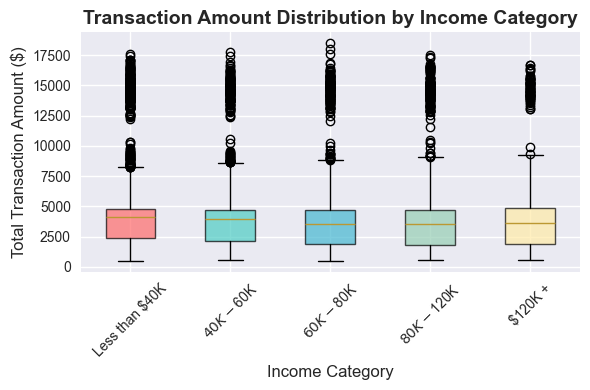

In [70]:

# Create box plot of transaction amounts by income category
fig, ax1 = plt.subplots(figsize=(6, 4))

box_data = [income_spending_df[income_spending_df['Income_Category'] == category]['Total_Trans_Amt'].values 
            for category in income_order if category in income_spending_df['Income_Category'].values]
box_labels = [category for category in income_order if category in income_spending_df['Income_Category'].values]

bp = ax1.boxplot(box_data, labels=box_labels, patch_artist=True)
ax1.set_title('Transaction Amount Distribution by Income Category', fontsize=14, fontweight='bold')
ax1.set_xlabel('Income Category', fontsize=12)
ax1.set_ylabel('Total Transaction Amount ($)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Color the boxes
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.tight_layout()
plt.show()


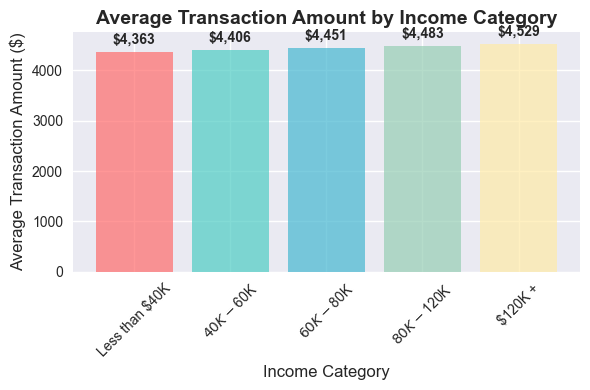

In [71]:
# Create bar chart of average transaction amount by income category
fig, ax2 = plt.subplots(figsize=(6, 4))

avg_spending = income_spending_df.groupby('Income_Category')['Total_Trans_Amt'].mean()
avg_spending = avg_spending.reindex([cat for cat in income_order if cat in avg_spending.index])

bars = ax2.bar(range(len(avg_spending)), avg_spending.values, color=colors[:len(avg_spending)], alpha=0.7)
ax2.set_title('Average Transaction Amount by Income Category', fontsize=14, fontweight='bold')
ax2.set_xlabel('Income Category', fontsize=12)
ax2.set_ylabel('Average Transaction Amount ($)', fontsize=12)
ax2.set_xticks(range(len(avg_spending)))
ax2.set_xticklabels(avg_spending.index, rotation=45)

# Add value labels on bars
for bar, value in zip(bars, avg_spending.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
             f'${value:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


Analysis of Variance is used to compare the means of three or more groups to determine if there's a statistically significant difference between them. It analyzes the variance between groups to assess whether the observed variance between group means is larger than what would be expected by random chance. 

In [72]:

# Summary statistics
stats_df = income_spending_df.groupby('Income_Category')['Total_Trans_Amt'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)

# Reorder by income level
stats_df = stats_df.reindex([cat for cat in income_order if cat in stats_df.index])

for category in stats_df.index:
    row = stats_df.loc[category]
    print(f"\n{category}:")
    print(f"  Customers: {row['count']:,}")
    print(f"  Average Amount: ${row['mean']:,.2f}")
    print(f"  Median Amount: ${row['median']:,.2f}")

# Customer count summary
customer_counts = income_spending_df['Income_Category'].value_counts()
customer_counts = customer_counts.reindex([cat for cat in income_order if cat in customer_counts.index])

print(f"\nCustomer Distribution by Income Category:")
print("-" * 50)
for category, count in customer_counts.items():
    percentage = (count / len(income_spending_df)) * 100
    print(f"{category}: {count:,} customers ({percentage:.1f}%)")

# Correlation between income level (numeric) and transaction amount
income_mapping = {category: i for i, category in enumerate(income_order)}
income_numeric = income_spending_df['Income_Category'].map(income_mapping)

correlation = income_numeric.corr(income_spending_df['Total_Trans_Amt'])
print(f"\nCorrelation Analysis:")
print("-" * 30)
print(f"Correlation coefficient: {correlation:.3f}")

if correlation > 0.3:
    strength = "strong positive"
elif correlation > 0.1:
    strength = "moderate positive"
elif correlation > -0.1:
    strength = "weak"
elif correlation > -0.3:
    strength = "moderate negative"
else:
    strength = "strong negative"

print(f"Correlation strength: {strength}")

# ========== STATISTICAL SIGNIFICANCE TEST ==========

print("\n" + "="*60)
print("ONE-WAY ANOVA TEST")
print("="*60)
print("Testing if there are significant differences in transaction amounts across income categories")

# Prepare data for ANOVA - create separate arrays for each income category
income_groups = []
group_names = []

for category in income_order:
    if category in income_spending_df['Income_Category'].values:
        group_data = income_spending_df[income_spending_df['Income_Category'] == category]['Total_Trans_Amt']
        if len(group_data) > 0:  # Only include groups with data
            income_groups.append(group_data)
            group_names.append(category)


# Perform one-way ANOVA
f_statistic, p_value = f_oneway(*income_groups)

print(f"\nANOVA Results:")
print("-" * 30)
print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value:.6f}")


# Interpret results
alpha = 0.05
if p_value < alpha:
    print(f"\n✓ SIGNIFICANT: There IS a statistically significant difference in transaction amounts across income categories (p < {alpha})")
    print("  This means that at least one income group has a significantly different mean transaction amount.")
else:
    print(f"\n✗ NOT SIGNIFICANT: There is NO statistically significant difference in transaction amounts across income categories (p ≥ {alpha})")
    print("  This means all income groups have similar mean transaction amounts.")

# Calculate effect size (eta-squared)
# eta-squared = SS_between / SS_total
grand_mean = income_spending_df['Total_Trans_Amt'].mean()
n_total = len(income_spending_df)

# Calculate sum of squares between groups
ss_between = sum([len(group) * (group.mean() - grand_mean)**2 for group in income_groups])

# Calculate sum of squares within groups  
ss_within = sum([((group - group.mean())**2).sum() for group in income_groups])

# Calculate total sum of squares
ss_total = ss_between + ss_within



# Additional descriptive statistics
print(f"\nDescriptive Statistics Summary:")
print("-" * 30)
overall_mean = income_spending_df['Total_Trans_Amt'].mean()
overall_std = income_spending_df['Total_Trans_Amt'].std()

print(f"Overall mean transaction amount: ${overall_mean:,.2f}")
print(f"Overall standard deviation: ${overall_std:,.2f}")

print(f"\nMean transaction amount by income category:")
for i, group in enumerate(income_groups):
    group_mean = group.mean()
    difference_from_overall = group_mean - overall_mean
    print(f"  {group_names[i]}: ${group_mean:,.2f} (difference: ${difference_from_overall:+,.2f})")




Less than $40K:
  Customers: 3,561.0
  Average Amount: $4,363.42
  Median Amount: $4,099.00

$40K - $60K:
  Customers: 1,790.0
  Average Amount: $4,405.62
  Median Amount: $3,967.00

$60K - $80K:
  Customers: 1,402.0
  Average Amount: $4,450.71
  Median Amount: $3,552.50

$80K - $120K:
  Customers: 1,535.0
  Average Amount: $4,482.96
  Median Amount: $3,525.00

$120K +:
  Customers: 727.0
  Average Amount: $4,529.47
  Median Amount: $3,643.00

Customer Distribution by Income Category:
--------------------------------------------------
Less than $40K: 3,561 customers (35.2%)
$40K - $60K: 1,790 customers (17.7%)
$60K - $80K: 1,402 customers (13.8%)
$80K - $120K: 1,535 customers (15.2%)
$120K +: 727 customers (7.2%)

Correlation Analysis:
------------------------------
Correlation coefficient: 0.016
Correlation strength: weak

ONE-WAY ANOVA TEST
Testing if there are significant differences in transaction amounts across income categories

ANOVA Results:
------------------------------
F-st

given people in general have same level of basic expenses (food, bills, rent etc), the high income groups are only spending $400 on average more, which seems odd compared to general logic that someone making 120k would only spend $400 more a year than someone making $40k, but this is a mock dataset. This makes me rethink the hypothesis of higher spending = higher income, however I am still not able to correlate spending to churning, or strongly correlate income to churning

### Months on Book

In [73]:

tenure_df = new_df.copy()

# Filter missing values
tenure_df = tenure_df[tenure_df['Months_on_book'].notna()]
tenure_df = tenure_df[tenure_df['Attrition_Flag'].notna()]


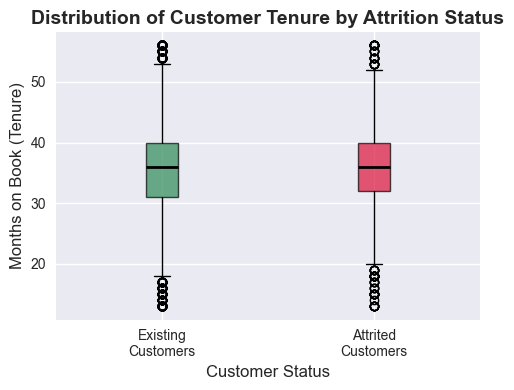

In [74]:
# Prepare box plot data
existing_customers = tenure_df[tenure_df['Attrition_Flag'] == 'Existing Customer']['Months_on_book']
attrited_customers = tenure_df[tenure_df['Attrition_Flag'] == 'Attrited Customer']['Months_on_book']

fig, ax1 = plt.subplots(figsize=(5, 4))

box_data = [existing_customers, attrited_customers]
box_labels = ['Existing\nCustomers', 'Attrited\nCustomers']

bp = ax1.boxplot(box_data, labels=box_labels, patch_artist=True)
ax1.set_title('Distribution of Customer Tenure by Attrition Status', fontsize=14, fontweight='bold')
ax1.set_xlabel('Customer Status', fontsize=12)
ax1.set_ylabel('Months on Book (Tenure)', fontsize=12)

# Color and style
colors = ['#2E8B57', '#DC143C']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)

plt.tight_layout()
plt.show()


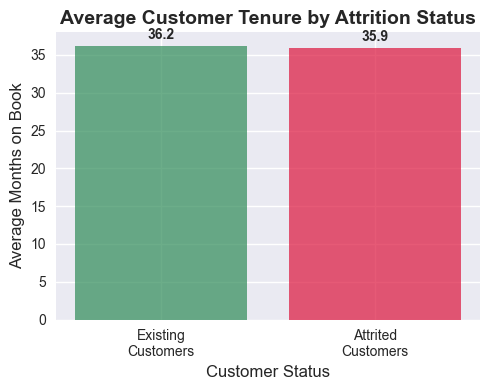

In [75]:
fig, ax2 = plt.subplots(figsize=(5, 4))

avg_tenure = tenure_df.groupby('Attrition_Flag')['Months_on_book'].mean()
bars = ax2.bar(range(len(avg_tenure)), avg_tenure.values, color=colors, alpha=0.7)

ax2.set_title('Average Customer Tenure by Attrition Status', fontsize=14, fontweight='bold')
ax2.set_xlabel('Customer Status', fontsize=12)
ax2.set_ylabel('Average Months on Book', fontsize=12)
ax2.set_xticks(range(len(avg_tenure)))
ax2.set_xticklabels(['Existing\nCustomers', 'Attrited\nCustomers'])

for bar, value in zip(bars, avg_tenure.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{value:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


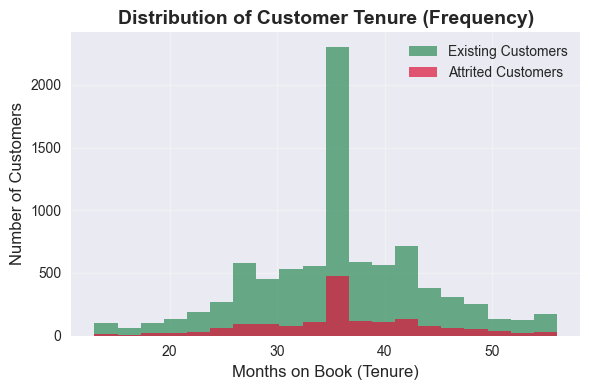

In [76]:
fig, ax3 = plt.subplots(figsize=(6, 4))

ax3.hist(existing_customers, bins=20, alpha=0.7, label='Existing Customers', color='#2E8B57')
ax3.hist(attrited_customers, bins=20, alpha=0.7, label='Attrited Customers', color='#DC143C')

ax3.set_title('Distribution of Customer Tenure (Frequency)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Months on Book (Tenure)', fontsize=12)
ax3.set_ylabel('Number of Customers', fontsize=12)
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()


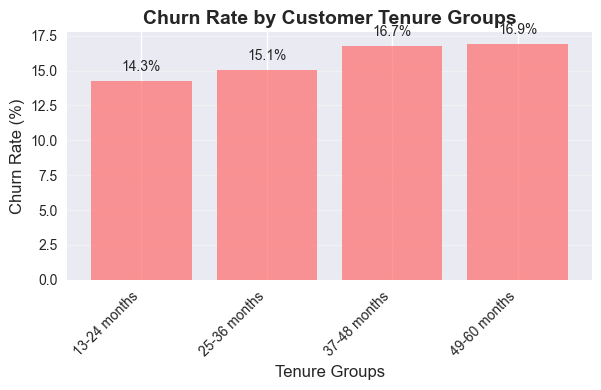

In [77]:
# Define bins and labels
tenure_bins = [0, 12, 24, 36, 48, 60, float('inf')]
tenure_labels = ['0-12 months', '13-24 months', '25-36 months', '37-48 months', '49-60 months', '60+ months']

# Assign groups
tenure_df['Tenure_Group'] = pd.cut(tenure_df['Months_on_book'], bins=tenure_bins, labels=tenure_labels, right=False)

# Calculate churn rate per group
churn_by_tenure = []
tenure_groups = []

for group in tenure_labels:
    subset = tenure_df[tenure_df['Tenure_Group'] == group]
    if len(subset) > 0:
        total_customers = len(subset)
        attrited_count = len(subset[subset['Attrition_Flag'] == 'Attrited Customer'])
        churn_rate = (attrited_count / total_customers) * 100
        churn_by_tenure.append(churn_rate)
        tenure_groups.append(group)

# Plot
fig, ax4 = plt.subplots(figsize=(6, 4))
bars4 = ax4.bar(range(len(churn_by_tenure)), churn_by_tenure, color='#FF6B6B', alpha=0.7)

ax4.set_title('Churn Rate by Customer Tenure Groups', fontsize=14, fontweight='bold')
ax4.set_xlabel('Tenure Groups', fontsize=12)
ax4.set_ylabel('Churn Rate (%)', fontsize=12)
ax4.set_xticks(range(len(tenure_groups)))
ax4.set_xticklabels(tenure_groups, rotation=45, ha='right')
ax4.grid(axis='y', alpha=0.3)

# Value labels
for bar, value in zip(bars4, churn_by_tenure):
    if value > 0:
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 f'{value:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


In [78]:
print("=" * 70)
print("CUSTOMER TENURE vs CHURN ANALYSIS")
print("=" * 70)

print(f"\nTotal customers analyzed: {len(tenure_df):,}")

# Descriptive stats by churn status
print(f"\nTenure Statistics by Customer Status:")
print("-" * 45)

stats_by_status = tenure_df.groupby('Attrition_Flag')['Months_on_book'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)

for status in stats_by_status.index:
    row = stats_by_status.loc[status]
    print(f"\n{status}:")
    print(f"  Count: {row['count']:,}")
    print(f"  Average Tenure: {row['mean']:.1f} months ({row['mean']/12:.1f} years)")
    print(f"  Median Tenure: {row['median']:.1f} months ({row['median']/12:.1f} years)")
    print(f"  Std Deviation: {row['std']:.1f} months")
    print(f"  Range: {row['min']:.0f} - {row['max']:.0f} months")
# Encode churn as binary
tenure_df['Churn_Binary'] = (tenure_df['Attrition_Flag'] == 'Attrited Customer').astype(int)

# Correlation
correlation = tenure_df['Months_on_book'].corr(tenure_df['Churn_Binary'])

print(f"\nCorrelation between Tenure and Churn: {correlation:.3f}")

if correlation > 0.3:
    strength = "strong positive"
elif correlation > 0.1:
    strength = "moderate positive"
elif correlation > -0.1:
    strength = "weak"
elif correlation > -0.3:
    strength = "moderate negative"
else:
    strength = "strong negative"

print(f"Correlation strength: {strength}")


CUSTOMER TENURE vs CHURN ANALYSIS

Total customers analyzed: 10,127

Tenure Statistics by Customer Status:
---------------------------------------------

Attrited Customer:
  Count: 1,627.0
  Average Tenure: 36.2 months (3.0 years)
  Median Tenure: 36.0 months (3.0 years)
  Std Deviation: 7.8 months
  Range: 13 - 56 months

Existing Customer:
  Count: 8,500.0
  Average Tenure: 35.9 months (3.0 years)
  Median Tenure: 36.0 months (3.0 years)
  Std Deviation: 8.0 months
  Range: 13 - 56 months

Correlation between Tenure and Churn: 0.014
Correlation strength: weak


There is no correlation with months with the bank and churn rate, even though ~85% of customers are within 2-4 years of being acquired, the % of churn rate slightly increases over time, but is not significant. 

### Relationship Count

In [79]:
relcount_df = new_df.copy()

# Filter out any missing values
relcount_df = relcount_df[relcount_df['Total_Relationship_Count'].notna()]
relcount_df = relcount_df[relcount_df['Attrition_Flag'].notna()]


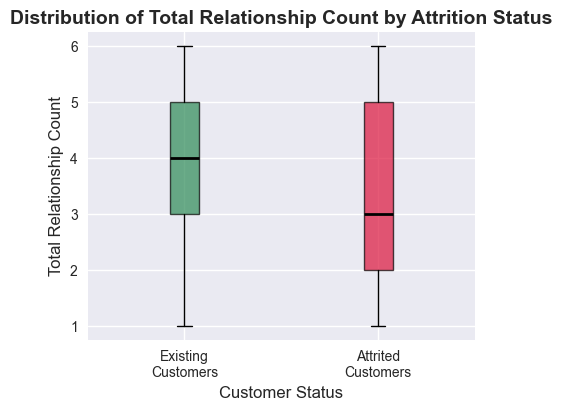

In [80]:


fig, ax1 = plt.subplots(figsize=(5, 4))

# 1. Box plot showing distribution of relationship count by attrition status
existing_customers = relcount_df[relcount_df['Attrition_Flag'] == 'Existing Customer']['Total_Relationship_Count']
attrited_customers = relcount_df[relcount_df['Attrition_Flag'] == 'Attrited Customer']['Total_Relationship_Count']

box_data = [existing_customers, attrited_customers]
box_labels = ['Existing\nCustomers', 'Attrited\nCustomers']

bp = ax1.boxplot(box_data, labels=box_labels, patch_artist=True)
ax1.set_title('Distribution of Total Relationship Count by Attrition Status', fontsize=14, fontweight='bold')
ax1.set_xlabel('Customer Status', fontsize=12)
ax1.set_ylabel('Total Relationship Count', fontsize=12)

# Color the boxes
colors = ['#2E8B57', '#DC143C']  # Green for existing, red for attrited
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Make median lines darker and more visible
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)


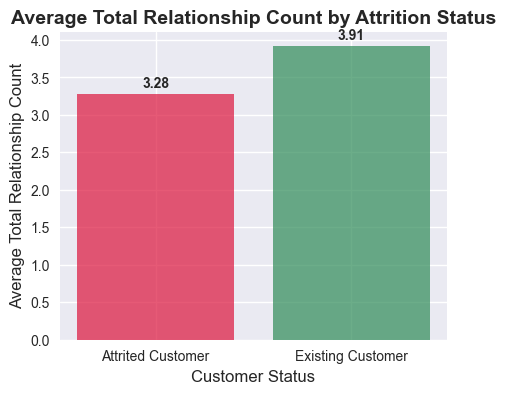

In [81]:
fig, ax2 = plt.subplots(figsize=(5, 4))
# 2. Bar chart showing average relationship count by attrition status
avg_relcount = relcount_df.groupby('Attrition_Flag')['Total_Relationship_Count'].mean()

bar_colors = ['#DC143C' if 'Attrited' in status else '#2E8B57' for status in avg_relcount.index]
bars = ax2.bar(range(len(avg_relcount)), avg_relcount.values, color=bar_colors, alpha=0.7)
ax2.set_title('Average Total Relationship Count by Attrition Status', fontsize=14, fontweight='bold')
ax2.set_xlabel('Customer Status', fontsize=12)
ax2.set_ylabel('Average Total Relationship Count', fontsize=12)
ax2.set_xticks(range(len(avg_relcount)))

ax2.set_xticklabels(avg_relcount.index)


for bar, value in zip(bars, avg_relcount.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{value:.2f}', ha='center', va='bottom', fontweight='bold')


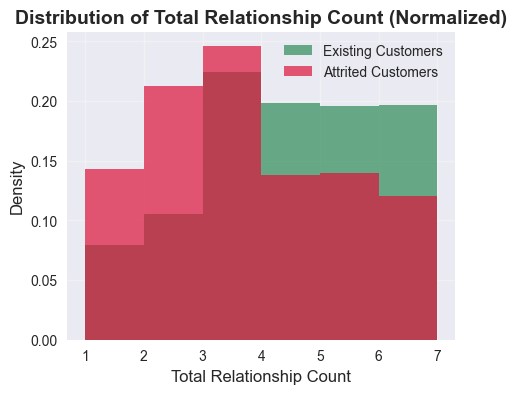

In [82]:
fig, ax3 = plt.subplots(figsize=(5, 4))
# 3. Histogram showing distribution of relationship count for both groups
ax3.hist(existing_customers, bins=range(1, int(relcount_df['Total_Relationship_Count'].max()) + 2), 
         alpha=0.7, label='Existing Customers', color='#2E8B57', density=True)
ax3.hist(attrited_customers, bins=range(1, int(relcount_df['Total_Relationship_Count'].max()) + 2), 
         alpha=0.7, label='Attrited Customers', color='#DC143C', density=True)

ax3.set_title('Distribution of Total Relationship Count (Normalized)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Total Relationship Count', fontsize=12)
ax3.set_ylabel('Density', fontsize=12)
ax3.legend()
ax3.grid(alpha=0.3)


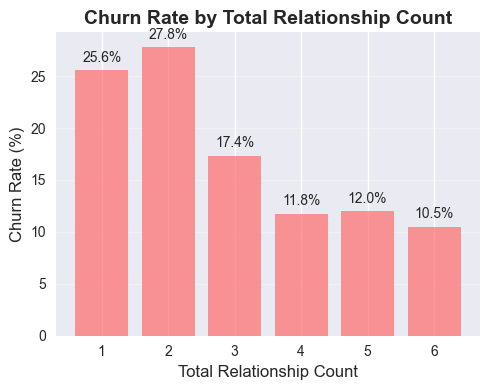

In [83]:
fig, ax4 = plt.subplots(figsize=(5, 4))
# 4. Churn rate by relationship count

unique_counts = sorted(relcount_df['Total_Relationship_Count'].unique())
churn_by_count = []
count_labels = []

for count in unique_counts:
    subset = relcount_df[relcount_df['Total_Relationship_Count'] == count]
    if len(subset) > 0:
        total_customers = len(subset)
        attrited_count = len(subset[subset['Attrition_Flag'] == 'Attrited Customer'])
        churn_rate = (attrited_count / total_customers) * 100
        churn_by_count.append(churn_rate)
        count_labels.append(str(int(count)))

bars4 = ax4.bar(range(len(churn_by_count)), churn_by_count, color='#FF6B6B', alpha=0.7)
ax4.set_title('Churn Rate by Total Relationship Count', fontsize=14, fontweight='bold')
ax4.set_xlabel('Total Relationship Count', fontsize=12)
ax4.set_ylabel('Churn Rate (%)', fontsize=12)
ax4.set_xticks(range(len(count_labels)))
ax4.set_xticklabels(count_labels)


for bar, value in zip(bars4, churn_by_count):
    if value > 0:
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 f'{value:.1f}%', ha='center', va='bottom', fontsize=10)

ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [84]:

# Print detailed statistics
print("=" * 70)
print("TOTAL RELATIONSHIP COUNT vs CHURN ANALYSIS")
print("=" * 70)

print(f"\nTotal customers analyzed: {len(relcount_df):,}")

# Basic statistics by attrition status
print(f"\nRelationship Count Statistics by Customer Status:")
print("-" * 55)

stats_by_status = relcount_df.groupby('Attrition_Flag')['Total_Relationship_Count'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)

for status in stats_by_status.index:
    row = stats_by_status.loc[status]
    print(f"\n{status}:")
    print(f"  Count: {row['count']:,}")
    print(f"  Average Relationship Count: {row['mean']:.2f}")
    print(f"  Median Relationship Count: {row['median']:.2f}")
    print(f"  Std Deviation: {row['std']:.2f}")
    print(f"  Range: {row['min']:.0f} - {row['max']:.0f}")

# Calculate correlation between relationship count and churn (binary encoding)
relcount_df['Churn_Binary'] = (relcount_df['Attrition_Flag'] == 'Attrited Customer').astype(int)
correlation = relcount_df['Total_Relationship_Count'].corr(relcount_df['Churn_Binary'])

print(f"\nCorrelation between Total Relationship Count and Churn: {correlation:.3f}")

if correlation > 0.3:
    strength = "strong positive"
elif correlation > 0.1:
    strength = "moderate positive"
elif correlation > -0.1:
    strength = "weak"
elif correlation > -0.3:
    strength = "moderate negative"
else:
    strength = "strong negative"

print(f"Correlation strength: {strength}")



# Customer engagement insights
print(f"\nCustomer Engagement Insights:")
print("-" * 30)

# Calculate distribution of relationship counts
for count in unique_counts:
    subset = relcount_df[relcount_df['Total_Relationship_Count'] == count]
    percentage = len(subset) / len(relcount_df) * 100
    print(f"Customers with {int(count)} relationship(s): {len(subset):,} ({percentage:.1f}%)")


TOTAL RELATIONSHIP COUNT vs CHURN ANALYSIS

Total customers analyzed: 10,127

Relationship Count Statistics by Customer Status:
-------------------------------------------------------

Attrited Customer:
  Count: 1,627.0
  Average Relationship Count: 3.28
  Median Relationship Count: 3.00
  Std Deviation: 1.58
  Range: 1 - 6

Existing Customer:
  Count: 8,500.0
  Average Relationship Count: 3.91
  Median Relationship Count: 4.00
  Std Deviation: 1.53
  Range: 1 - 6

Correlation between Total Relationship Count and Churn: -0.150
Correlation strength: moderate negative

Customer Engagement Insights:
------------------------------
Customers with 1 relationship(s): 910 (9.0%)
Customers with 2 relationship(s): 1,243 (12.3%)
Customers with 3 relationship(s): 2,305 (22.8%)
Customers with 4 relationship(s): 1,912 (18.9%)
Customers with 5 relationship(s): 1,891 (18.7%)
Customers with 6 relationship(s): 1,866 (18.4%)


there is a negative correlation between churn rate and relationship count. This could suggest clients with several products are "more invested" in the bank and are less likely to churn. more relationships could also imply more active customers, tying into the theory of existing customers are active customers. Relationship count should be examined with transaction count. This will be explored below

### Trns Count vs Relationships

Hypothesis: Those who have more products (relationships) will be more active with the banks

In [85]:
trans_rel_df = new_df.copy()

# Filter out any missing values
trans_rel_df = trans_rel_df[trans_rel_df['Total_Relationship_Count'].notna()]
trans_rel_df = trans_rel_df[trans_rel_df['Total_Trans_Ct'].notna()]


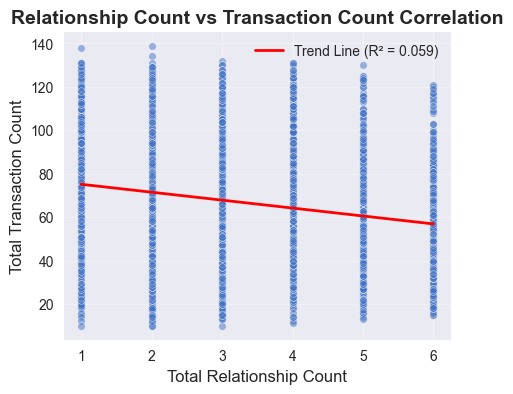

In [86]:


fig, ax1 = plt.subplots(figsize=(5, 4))

# 1. Scatter plot showing correlation between relationship count and transaction count
ax1.scatter(trans_rel_df['Total_Relationship_Count'], trans_rel_df['Total_Trans_Ct'], 
           alpha=0.5, s=30, c='#4472C4', edgecolors='white', linewidth=0.5)

# Add trend line
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(trans_rel_df['Total_Relationship_Count'], 
                                                        trans_rel_df['Total_Trans_Ct'])
line_x = np.linspace(trans_rel_df['Total_Relationship_Count'].min(), 
                     trans_rel_df['Total_Relationship_Count'].max(), 100)
line_y = slope * line_x + intercept
ax1.plot(line_x, line_y, color='red', linewidth=2, label=f'Trend Line (R² = {r_value**2:.3f})')

ax1.set_title('Relationship Count vs Transaction Count Correlation', fontsize=14, fontweight='bold')
ax1.set_xlabel('Total Relationship Count', fontsize=12)
ax1.set_ylabel('Total Transaction Count', fontsize=12)
ax1.legend()
ax1.grid(alpha=0.3)


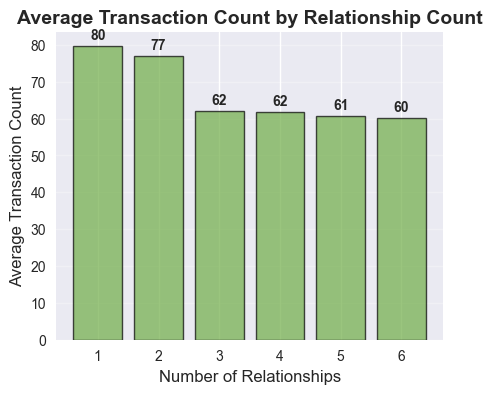

In [87]:
fig, ax3 = plt.subplots(figsize=(5, 4))
# 3. Bar chart showing average transaction count by relationship count
avg_trans_by_rel = trans_rel_df.groupby('Total_Relationship_Count')['Total_Trans_Ct'].agg(['mean', 'count'])
avg_trans_by_rel = avg_trans_by_rel[avg_trans_by_rel['count'] >= 10]  # Filter for sufficient sample size

bars = ax3.bar(range(len(avg_trans_by_rel)), avg_trans_by_rel['mean'], 
               color='#70AD47', alpha=0.7, edgecolor='black', linewidth=1)
ax3.set_title('Average Transaction Count by Relationship Count', fontsize=14, fontweight='bold')
ax3.set_xlabel('Number of Relationships', fontsize=12)
ax3.set_ylabel('Average Transaction Count', fontsize=12)
ax3.set_xticks(range(len(avg_trans_by_rel)))
ax3.set_xticklabels([f'{int(idx)}' for idx in avg_trans_by_rel.index])

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, avg_trans_by_rel['mean'])):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{value:.0f}', ha='center', va='bottom', fontweight='bold')

ax3.grid(axis='y', alpha=0.3)


In [88]:

# Print detailed statistics
print("=" * 80)
print("RELATIONSHIP COUNT vs TRANSACTION COUNT ANALYSIS")
print("=" * 80)

print(f"\nTotal customers analyzed: {len(trans_rel_df):,}")

# Calculate correlation
correlation = trans_rel_df['Total_Relationship_Count'].corr(trans_rel_df['Total_Trans_Ct'])
print(f"\nCorrelation between Relationship Count and Transaction Count: {correlation:.4f}")

if correlation > 0.7:
    strength = "very strong positive"
elif correlation > 0.5:
    strength = "strong positive"
elif correlation > 0.3:
    strength = "moderate positive"
elif correlation > 0.1:
    strength = "weak positive"
elif correlation > -0.1:
    strength = "negligible"
elif correlation > -0.3:
    strength = "weak negative"
elif correlation > -0.5:
    strength = "moderate negative"
elif correlation > -0.7:
    strength = "strong negative"
else:
    strength = "very strong negative"

print(f"Correlation strength: {strength}")
print(f"R-squared value: {correlation**2:.4f} ({correlation**2*100:.2f}% of variance explained)")


RELATIONSHIP COUNT vs TRANSACTION COUNT ANALYSIS

Total customers analyzed: 10,127

Correlation between Relationship Count and Transaction Count: -0.2419
Correlation strength: weak negative
R-squared value: 0.0585 (5.85% of variance explained)


This contradicts my hypothesis above. high activity does not mean high relationship count

### Contact Count

In [89]:
contacts_df = new_df.copy()

# Filter out any missing values
contacts_df = contacts_df[contacts_df['Contacts_Count_12_mon'].notna()]
contacts_df = contacts_df[contacts_df['Attrition_Flag'].notna()]


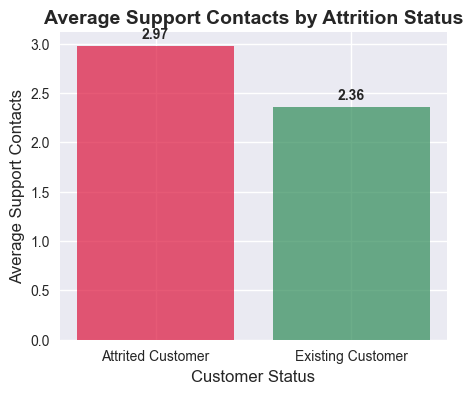

In [90]:

# Create figure with subplots
fig, ax2 = plt.subplots(figsize=(5, 4))

# 2. Bar chart showing average contacts by attrition status
avg_contacts = contacts_df.groupby('Attrition_Flag')['Contacts_Count_12_mon'].mean()
# Create color mapping based on the actual order from groupby
bar_colors = ['#DC143C' if 'Attrited' in status else '#2E8B57' for status in avg_contacts.index]
bars = ax2.bar(range(len(avg_contacts)), avg_contacts.values, color=bar_colors, alpha=0.7)
ax2.set_title('Average Support Contacts by Attrition Status', fontsize=14, fontweight='bold')
ax2.set_xlabel('Customer Status', fontsize=12)
ax2.set_ylabel('Average Support Contacts', fontsize=12)
ax2.set_xticks(range(len(avg_contacts)))
ax2.set_xticklabels(avg_contacts.index)

# Add value labels on bars
for bar, value in zip(bars, avg_contacts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{value:.2f}', ha='center', va='bottom', fontweight='bold')


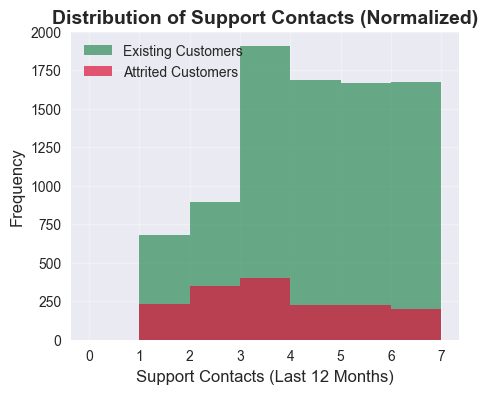

In [91]:
fig, ax3 = plt.subplots(figsize=(5, 4))
# 3. Histogram showing distribution of contacts for both groups
max_contacts = int(contacts_df['Contacts_Count_12_mon'].max())
bins = range(0, max_contacts + 2)

ax3.hist(existing_customers, bins=bins, alpha=0.7, label='Existing Customers', 
         color='#2E8B57', density=False)
ax3.hist(attrited_customers, bins=bins, alpha=0.7, label='Attrited Customers', 
         color='#DC143C', density=False)

ax3.set_title('Distribution of Support Contacts (Normalized)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Support Contacts (Last 12 Months)', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.legend()
ax3.grid(alpha=0.3)


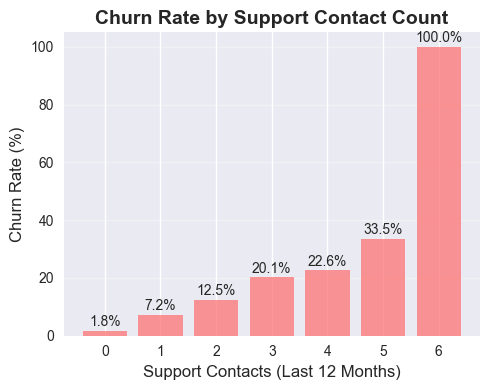

In [92]:
fig, ax4 = plt.subplots(figsize=(5, 4))
# 4. Churn rate by contact count
unique_contacts = sorted(contacts_df['Contacts_Count_12_mon'].unique())
churn_by_contacts = []
contact_labels = []

for contact_count in unique_contacts:
    subset = contacts_df[contacts_df['Contacts_Count_12_mon'] == contact_count]
    if len(subset) > 0:
        total_customers = len(subset)
        attrited_count = len(subset[subset['Attrition_Flag'] == 'Attrited Customer'])
        churn_rate = (attrited_count / total_customers) * 100
        churn_by_contacts.append(churn_rate)
        contact_labels.append(str(int(contact_count)))

bars4 = ax4.bar(range(len(churn_by_contacts)), churn_by_contacts, color='#FF6B6B', alpha=0.7)
ax4.set_title('Churn Rate by Support Contact Count', fontsize=14, fontweight='bold')
ax4.set_xlabel('Support Contacts (Last 12 Months)', fontsize=12)
ax4.set_ylabel('Churn Rate (%)', fontsize=12)
ax4.set_xticks(range(len(contact_labels)))
ax4.set_xticklabels(contact_labels)

# Add value labels on bars
for bar, value in zip(bars4, churn_by_contacts):
    if value > 0:
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 f'{value:.1f}%', ha='center', va='bottom', fontsize=10)

ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [93]:

# Print detailed statistics
print("=" * 80)
print("CUSTOMER SUPPORT CONTACTS vs ATTRITION ANALYSIS")
print("=" * 80)

print(f"\nTotal customers analyzed: {len(contacts_df):,}")

# Basic statistics by attrition status
print(f"\nSupport Contact Statistics by Customer Status:")
print("-" * 55)

stats_by_status = contacts_df.groupby('Attrition_Flag')['Contacts_Count_12_mon'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)

for status in stats_by_status.index:
    row = stats_by_status.loc[status]
    print(f"\n{status}:")
    print(f"  Count: {row['count']:,}")
    print(f"  Average Contacts: {row['mean']:.2f}")
    print(f"  Median Contacts: {row['median']:.2f}")
    print(f"  Std Deviation: {row['std']:.2f}")
    print(f"  Range: {row['min']:.0f} - {row['max']:.0f}")

# Calculate correlation between contacts and churn (binary encoding)
contacts_df['Churn_Binary'] = (contacts_df['Attrition_Flag'] == 'Attrited Customer').astype(int)
correlation = contacts_df['Contacts_Count_12_mon'].corr(contacts_df['Churn_Binary'])

print(f"\nCorrelation between Support Contacts and Churn: {correlation:.4f}")

if correlation > 0.3:
    strength = "strong positive"
elif correlation > 0.1:
    strength = "moderate positive"
elif correlation > -0.1:
    strength = "weak"
elif correlation > -0.3:
    strength = "moderate negative"
else:
    strength = "strong negative"

print(f"Correlation strength: {strength}")

# Detailed breakdown by contact count
print(f"\nDetailed Breakdown by Support Contact Count:")
print("-" * 70)
print(f"{'Contacts':<10} {'Total':<8} {'Existing':<10} {'Attrited':<10} {'Churn Rate':<12}")
print("-" * 70)

for contact_count in unique_contacts:
    subset = contacts_df[contacts_df['Contacts_Count_12_mon'] == contact_count]
    if len(subset) > 0:
        total = len(subset)
        existing = len(subset[subset['Attrition_Flag'] == 'Existing Customer'])
        attrited = len(subset[subset['Attrition_Flag'] == 'Attrited Customer'])
        churn_rate = (attrited / total) * 100
        
        print(f"{int(contact_count):<10} {total:<8} {existing:<10} {attrited:<10} {churn_rate:<12.1f}%")


CUSTOMER SUPPORT CONTACTS vs ATTRITION ANALYSIS

Total customers analyzed: 10,127

Support Contact Statistics by Customer Status:
-------------------------------------------------------

Attrited Customer:
  Count: 1,627.0
  Average Contacts: 2.97
  Median Contacts: 3.00
  Std Deviation: 1.09
  Range: 0 - 6

Existing Customer:
  Count: 8,500.0
  Average Contacts: 2.36
  Median Contacts: 2.00
  Std Deviation: 1.08
  Range: 0 - 5

Correlation between Support Contacts and Churn: 0.2045
Correlation strength: moderate positive

Detailed Breakdown by Support Contact Count:
----------------------------------------------------------------------
Contacts   Total    Existing   Attrited   Churn Rate  
----------------------------------------------------------------------
0          399      392        7          1.8         %
1          1499     1391       108        7.2         %
2          3227     2824       403        12.5        %
3          3380     2699       681        20.1        %
4    

When contacting the bank you are generally looking for support about a topic, if there is multiple contacts, it could be interpreted as someone having issues problem solving, leading to a frustrated customer and thus high change of churning, given churn rate steadily increases with amount of contacts

### Revolving Balance

In [94]:
balance_df = new_df.copy()

# Filter out any missing values
balance_df = balance_df[balance_df['Total_Revolving_Bal'].notna()]
balance_df = balance_df[balance_df['Attrition_Flag'].notna()]


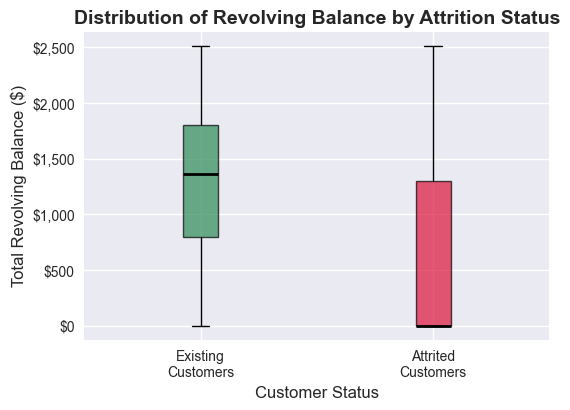

In [95]:

# Create figure with subplots
fig,ax1 = plt.subplots(figsize=(6,4))

# 1. Box plot showing distribution of revolving balance by attrition status
existing_customers = balance_df[balance_df['Attrition_Flag'] == 'Existing Customer']['Total_Revolving_Bal']
attrited_customers = balance_df[balance_df['Attrition_Flag'] == 'Attrited Customer']['Total_Revolving_Bal']

box_data = [existing_customers, attrited_customers]
box_labels = ['Existing\nCustomers', 'Attrited\nCustomers']

bp = ax1.boxplot(box_data, labels=box_labels, patch_artist=True)
ax1.set_title('Distribution of Revolving Balance by Attrition Status', fontsize=14, fontweight='bold')
ax1.set_xlabel('Customer Status', fontsize=12)
ax1.set_ylabel('Total Revolving Balance ($)', fontsize=12)

# Color the boxes
colors = ['#2E8B57', '#DC143C']  # Green for existing, red for attrited
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Make median lines darker and more visible
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)

# Format y-axis to show dollar amounts
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))


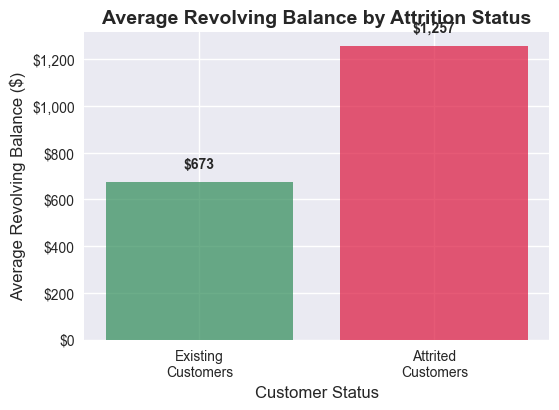

In [96]:
fig,ax2 = plt.subplots(figsize=(6,4))
# 2. Bar chart showing average revolving balance by attrition status
avg_balance = balance_df.groupby('Attrition_Flag')['Total_Revolving_Bal'].mean()
bars = ax2.bar(range(len(avg_balance)), avg_balance.values, color=colors, alpha=0.7)
ax2.set_title('Average Revolving Balance by Attrition Status', fontsize=14, fontweight='bold')
ax2.set_xlabel('Customer Status', fontsize=12)
ax2.set_ylabel('Average Revolving Balance ($)', fontsize=12)
ax2.set_xticks(range(len(avg_balance)))
ax2.set_xticklabels(['Existing\nCustomers', 'Attrited\nCustomers'])

# Add value labels on bars
for bar, value in zip(bars, avg_balance.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'${value:,.0f}', ha='center', va='bottom', fontweight='bold')

# Format y-axis to show dollar amounts
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))


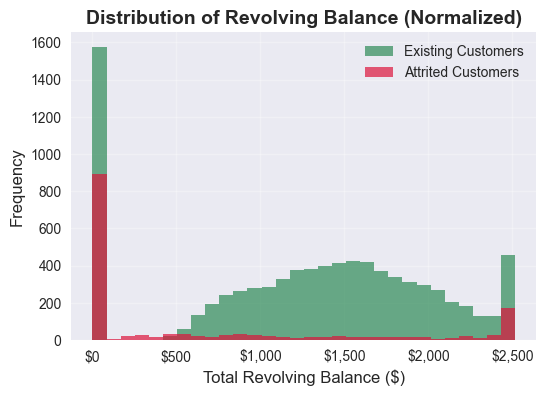

In [97]:
fig,ax3 = plt.subplots(figsize=(6,4))
# 3. Histogram showing distribution of revolving balance for both groups
ax3.hist(existing_customers, bins=30, alpha=0.7, label='Existing Customers', 
         color='#2E8B57', density=False)
ax3.hist(attrited_customers, bins=30, alpha=0.7, label='Attrited Customers', 
         color='#DC143C', density=False)

ax3.set_title('Distribution of Revolving Balance (Normalized)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Total Revolving Balance ($)', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.legend()
ax3.grid(alpha=0.3)


ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))


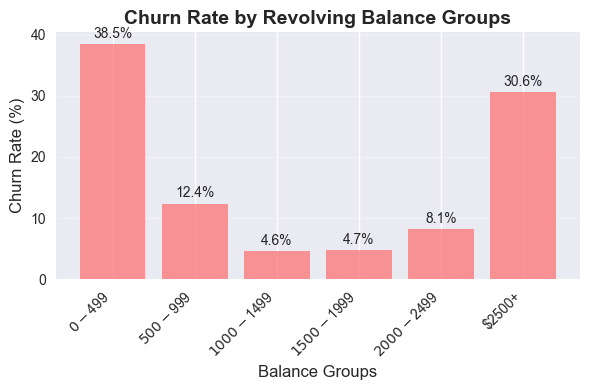

In [98]:
fig,ax4 = plt.subplots(figsize=(6,4))
# 4. Churn rate by revolving balance groups (binned)
# Create balance bins - customize these ranges based on your data distribution
balance_bins = [0, 500, 1000, 1500, 2000, 2500, float('inf')]
balance_labels = ['$0-$499', '$500-$999', '$1000-$1499', '$1500-$1999', '$2000-$2499', '$2500+']

balance_df['Balance_Group'] = pd.cut(balance_df['Total_Revolving_Bal'], bins=balance_bins, labels=balance_labels, right=False)

# Calculate churn rates by balance group
churn_by_balance = []
balance_groups = []

for group in balance_labels:
    subset = balance_df[balance_df['Balance_Group'] == group]
    if len(subset) > 0:
        total_customers = len(subset)
        attrited_count = len(subset[subset['Attrition_Flag'] == 'Attrited Customer'])
        churn_rate = (attrited_count / total_customers) * 100
        churn_by_balance.append(churn_rate)
        balance_groups.append(group)

bars4 = ax4.bar(range(len(churn_by_balance)), churn_by_balance, color='#FF6B6B', alpha=0.7)
ax4.set_title('Churn Rate by Revolving Balance Groups', fontsize=14, fontweight='bold')
ax4.set_xlabel('Balance Groups', fontsize=12)
ax4.set_ylabel('Churn Rate (%)', fontsize=12)
ax4.set_xticks(range(len(balance_groups)))
ax4.set_xticklabels(balance_groups, rotation=45, ha='right')

# Add value labels on bars
for bar, value in zip(bars4, churn_by_balance):
    if value > 0:
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 f'{value:.1f}%', ha='center', va='bottom', fontsize=10)

ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [99]:

# Print detailed statistics
print("=" * 70)
print("TOTAL REVOLVING BALANCE vs CHURN ANALYSIS")
print("=" * 70)

print(f"\nTotal customers analyzed: {len(balance_df):,}")

# Basic statistics by attrition status
print(f"\nRevolving Balance Statistics by Customer Status:")
print("-" * 55)

stats_by_status = balance_df.groupby('Attrition_Flag')['Total_Revolving_Bal'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)

for status in stats_by_status.index:
    row = stats_by_status.loc[status]
    print(f"\n{status}:")
    print(f"  Count: {row['count']:,}")
    print(f"  Average Balance: ${row['mean']:,.2f}")
    print(f"  Median Balance: ${row['median']:,.2f}")
    print(f"  Std Deviation: ${row['std']:,.2f}")
    print(f"  Range: ${row['min']:,.2f} - ${row['max']:,.2f}")

# Calculate correlation between revolving balance and churn (binary encoding)
balance_df['Churn_Binary'] = (balance_df['Attrition_Flag'] == 'Attrited Customer').astype(int)
correlation = balance_df['Total_Revolving_Bal'].corr(balance_df['Churn_Binary'])

print(f"\nCorrelation between Revolving Balance and Churn: {correlation:.3f}")

if correlation > 0.3:
    strength = "strong positive"
elif correlation > 0.1:
    strength = "moderate positive"
elif correlation > -0.1:
    strength = "weak"
elif correlation > -0.3:
    strength = "moderate negative"
else:
    strength = "strong negative"

print(f"Correlation strength: {strength}")




TOTAL REVOLVING BALANCE vs CHURN ANALYSIS

Total customers analyzed: 10,127

Revolving Balance Statistics by Customer Status:
-------------------------------------------------------

Attrited Customer:
  Count: 1,627.0
  Average Balance: $672.82
  Median Balance: $0.00
  Std Deviation: $921.39
  Range: $0.00 - $2,517.00

Existing Customer:
  Count: 8,500.0
  Average Balance: $1,256.60
  Median Balance: $1,364.00
  Std Deviation: $757.75
  Range: $0.00 - $2,517.00

Correlation between Revolving Balance and Churn: -0.263
Correlation strength: moderate negative


### Avg Open to Buy

In [100]:


open_to_buy_df = new_df.copy()

# Filter out any missing values
open_to_buy_df = open_to_buy_df[open_to_buy_df['Avg_Open_To_Buy'].notna()]
open_to_buy_df = open_to_buy_df[open_to_buy_df['Attrition_Flag'].notna()]


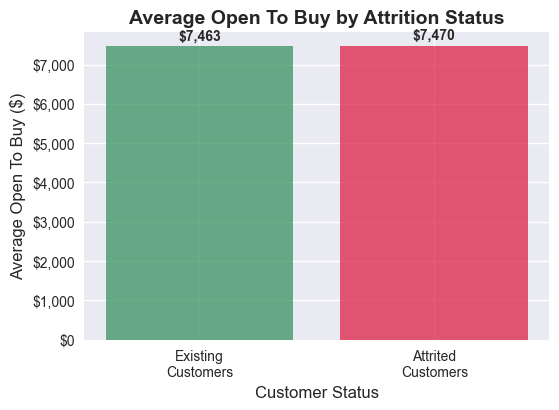

In [101]:

fig,ax2 = plt.subplots(figsize=(6, 4))

# 2. Bar chart showing average open to buy by attrition status
avg_open_to_buy = open_to_buy_df.groupby('Attrition_Flag')['Avg_Open_To_Buy'].mean()
bars = ax2.bar(range(len(avg_open_to_buy)), avg_open_to_buy.values, color=colors, alpha=0.7)
ax2.set_title('Average Open To Buy by Attrition Status', fontsize=14, fontweight='bold')
ax2.set_xlabel('Customer Status', fontsize=12)
ax2.set_ylabel('Average Open To Buy ($)', fontsize=12)
ax2.set_xticks(range(len(avg_open_to_buy)))
ax2.set_xticklabels(['Existing\nCustomers', 'Attrited\nCustomers'])


for bar, value in zip(bars, avg_open_to_buy.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
             f'${value:,.0f}', ha='center', va='bottom', fontweight='bold')


ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))


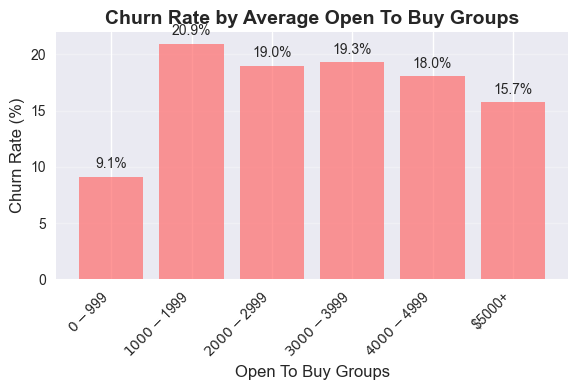

In [102]:
fig,ax4 = plt.subplots(figsize=(6, 4))
# 4. Churn rate by average open to buy groups (binned)
# Create balance bins - customize these ranges based on your data distribution
open_to_buy_bins = [0, 1000, 2000, 3000, 4000, 5000, float('inf')]
open_to_buy_labels = ['$0-$999', '$1000-$1999', '$2000-$2999', '$3000-$3999', '$4000-$4999', '$5000+']

open_to_buy_df['Open_To_Buy_Group'] = pd.cut(open_to_buy_df['Avg_Open_To_Buy'], bins=open_to_buy_bins, labels=open_to_buy_labels, right=False)

# Calculate churn rates by open to buy group
churn_by_open_to_buy = []
open_to_buy_groups = []

for group in open_to_buy_labels:
    subset = open_to_buy_df[open_to_buy_df['Open_To_Buy_Group'] == group]
    if len(subset) > 0:
        total_customers = len(subset)
        attrited_count = len(subset[subset['Attrition_Flag'] == 'Attrited Customer'])
        churn_rate = (attrited_count / total_customers) * 100
        churn_by_open_to_buy.append(churn_rate)
        open_to_buy_groups.append(group)

bars4 = ax4.bar(range(len(churn_by_open_to_buy)), churn_by_open_to_buy, color='#FF6B6B', alpha=0.7)
ax4.set_title('Churn Rate by Average Open To Buy Groups', fontsize=14, fontweight='bold')
ax4.set_xlabel('Open To Buy Groups', fontsize=12)
ax4.set_ylabel('Churn Rate (%)', fontsize=12)
ax4.set_xticks(range(len(open_to_buy_groups)))
ax4.set_xticklabels(open_to_buy_groups, rotation=45, ha='right')

# Add value labels on bars
for bar, value in zip(bars4, churn_by_open_to_buy):
    if value > 0:
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 f'{value:.1f}%', ha='center', va='bottom', fontsize=10)

ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [103]:

# Print detailed statistics
print("=" * 70)
print("AVERAGE OPEN TO BUY vs CHURN ANALYSIS")
print("=" * 70)

print(f"\nTotal customers analyzed: {len(open_to_buy_df):,}")

# Basic statistics by attrition status
print(f"\nAverage Open To Buy Statistics by Customer Status:")
print("-" * 55)

stats_by_status = open_to_buy_df.groupby('Attrition_Flag')['Avg_Open_To_Buy'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)

for status in stats_by_status.index:
    row = stats_by_status.loc[status]
    print(f"\n{status}:")
    print(f"  Count: {row['count']:,}")
    print(f"  Average Open To Buy: ${row['mean']:,.2f}")
    print(f"  Median Open To Buy: ${row['median']:,.2f}")
    print(f"  Std Deviation: ${row['std']:,.2f}")
    print(f"  Range: ${row['min']:,.2f} - ${row['max']:,.2f}")

# Calculate correlation between average open to buy and churn (binary encoding)
open_to_buy_df['Churn_Binary'] = (open_to_buy_df['Attrition_Flag'] == 'Attrited Customer').astype(int)
correlation = open_to_buy_df['Avg_Open_To_Buy'].corr(open_to_buy_df['Churn_Binary'])

print(f"\nCorrelation between Average Open To Buy and Churn: {correlation:.3f}")

if correlation > 0.3:
    strength = "strong positive"
elif correlation > 0.1:
    strength = "moderate positive"
elif correlation > -0.1:
    strength = "weak"
elif correlation > -0.3:
    strength = "moderate negative"
else:
    strength = "strong negative"

print(f"Correlation strength: {strength}")

# Detailed breakdown by open to buy groups
print(f"\nDetailed Breakdown by Open To Buy Groups:")
print("-" * 70)
print(f"{'Open To Buy Group':<20} {'Total':<8} {'Existing':<10} {'Attrited':<10} {'Churn Rate':<12}")
print("-" * 70)

for group in open_to_buy_labels:
    subset = open_to_buy_df[open_to_buy_df['Open_To_Buy_Group'] == group]
    if len(subset) > 0:
        total = len(subset)
        existing = len(subset[subset['Attrition_Flag'] == 'Existing Customer'])
        attrited = len(subset[subset['Attrition_Flag'] == 'Attrited Customer'])
        churn_rate = (attrited / total) * 100
        
        print(f"{group:<20} {total:<8} {existing:<10} {attrited:<10} {churn_rate:<12.1f}%")



AVERAGE OPEN TO BUY vs CHURN ANALYSIS

Total customers analyzed: 10,127

Average Open To Buy Statistics by Customer Status:
-------------------------------------------------------

Attrited Customer:
  Count: 1,627.0
  Average Open To Buy: $7,463.22
  Median Open To Buy: $3,488.00
  Std Deviation: $9,109.21
  Range: $3.00 - $34,516.00

Existing Customer:
  Count: 8,500.0
  Average Open To Buy: $7,470.27
  Median Open To Buy: $3,469.50
  Std Deviation: $9,087.67
  Range: $15.00 - $34,516.00

Correlation between Average Open To Buy and Churn: -0.000
Correlation strength: weak

Detailed Breakdown by Open To Buy Groups:
----------------------------------------------------------------------
Open To Buy Group    Total    Existing   Attrited   Churn Rate  
----------------------------------------------------------------------
$0-$999              1958     1780       178        9.1         %
$1000-$1999          1875     1483       392        20.9        %
$2000-$2999          880      713    

### Utilization Ratio

In [104]:

util_df = new_df.copy()

# Drop missing values
util_df = util_df[util_df['Avg_Utilization_Ratio'].notna() & util_df['Attrition_Flag'].notna()]

# Create churn binary
util_df['Churn_Binary'] = (util_df['Attrition_Flag'] == 'Attrited Customer').astype(int)



Text(0, 0.5, 'Avg Utilization Ratio')

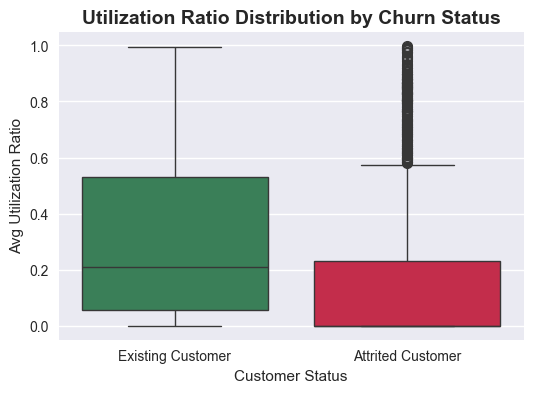

In [105]:

fig,ax1 = plt.subplots(figsize=(6, 4))

# 1. Box plot
sns.boxplot(x='Attrition_Flag', y='Avg_Utilization_Ratio', data=util_df,
            palette={'Existing Customer': '#2E8B57', 'Attrited Customer': '#DC143C'}, ax=ax1)
ax1.set_title('Utilization Ratio Distribution by Churn Status', fontsize=14, fontweight='bold')
ax1.set_xlabel('Customer Status')
ax1.set_ylabel('Avg Utilization Ratio')


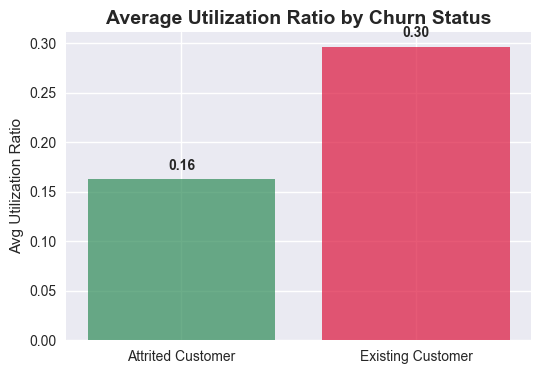

In [106]:

# 2. Bar chart of mean utilization
fig,ax2 = plt.subplots(figsize=(6, 4))
mean_util = util_df.groupby('Attrition_Flag')['Avg_Utilization_Ratio'].mean()
ax2.bar(mean_util.index, mean_util.values, color=['#2E8B57', '#DC143C'], alpha=0.7)
ax2.set_title('Average Utilization Ratio by Churn Status', fontsize=14, fontweight='bold')
ax2.set_ylabel('Avg Utilization Ratio')

for i, val in enumerate(mean_util.values):
    ax2.text(i, val + 0.01, f'{val:.2f}', ha='center', fontweight='bold')


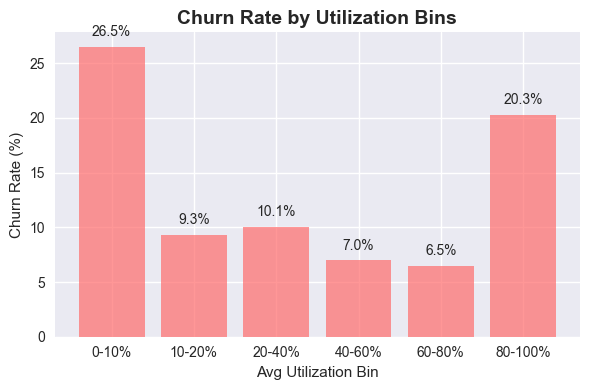

In [107]:

# 4. Binned churn rates
fig,ax4 = plt.subplots(figsize=(6, 4))
bins = [0, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ['0-10%', '10-20%', '20-40%', '40-60%', '60-80%', '80-100%']
util_df['Util_Bin'] = pd.cut(util_df['Avg_Utilization_Ratio'], bins=bins, labels=labels, right=False)

churn_rates = util_df.groupby('Util_Bin')['Churn_Binary'].mean() * 100
counts = util_df['Util_Bin'].value_counts().reindex(labels)

ax4.bar(labels, churn_rates, color='#FF6B6B', alpha=0.7)
ax4.set_title('Churn Rate by Utilization Bins', fontsize=14, fontweight='bold')
ax4.set_ylabel('Churn Rate (%)')
ax4.set_xlabel('Avg Utilization Bin')

for i, val in enumerate(churn_rates):
    ax4.text(i, val + 1, f'{val:.1f}%', ha='center')

plt.tight_layout()
plt.show()


In [108]:

# Print key stats
print("=" * 70)
print("UTILIZATION RATIO vs CHURN ANALYSIS")
print("=" * 70)


# Correlation
corr = util_df['Avg_Utilization_Ratio'].corr(util_df['Churn_Binary'])
print(f"\nCorrelation (Utilization vs Churn): {corr:.3f}")
if corr > 0.3:
    strength = "strong positive"
elif corr > 0.1:
    strength = "moderate positive"
elif corr > -0.1:
    strength = "weak"
elif corr > -0.3:
    strength = "moderate negative"
else:
    strength = "strong negative"
print(f"Correlation strength: {strength}")




UTILIZATION RATIO vs CHURN ANALYSIS

Correlation (Utilization vs Churn): -0.178
Correlation strength: moderate negative


### Credit Limit

In [110]:

# Create a dataframe for credit limit analysis
credit_df = new_df.copy()

# Calculate correlation between credit limit and churn (binary encoding)
credit_df['Churn_Binary'] = (credit_df['Attrition_Flag'] == 'Attrited Customer').astype(int)
correlation = credit_df['Credit_Limit'].corr(credit_df['Churn_Binary'])

print(f"\nCorrelation between Credit Limit and Churn: {correlation:.3f}")

if correlation > 0.3:
    strength = "strong positive"
elif correlation > 0.1:
    strength = "moderate positive"
elif correlation > -0.1:
    strength = "weak"
elif correlation > -0.3:
    strength = "moderate negative"
else:
    strength = "strong negative"

print(f"Correlation strength: {strength}")


Correlation between Credit Limit and Churn: -0.024
Correlation strength: weak


Credit Limit Range:
Minimum: $1,438
Maximum: $34,516

Attrition Rate by Credit Limit Range:
--------------------------------------------------
  $0-$2,500: 20.9% churn rate (506/2,421 customers)
  $2,501-$5,000: 14.3% churn rate (420/2,938 customers)
  $5,001-$7,500: 14.2% churn rate (169/1,191 customers)
  $7,501-$10,000: 16.2% churn rate (133/823 customers)
  $10,001-$12,500: 14.6% churn rate (76/521 customers)
  $12,501-$15,000: 16.4% churn rate (69/420 customers)
  $15,001-$17,500: 12.9% churn rate (38/294 customers)
  $17,501-$20,000: 12.5% churn rate (32/255 customers)
  $20,001-$22,500: 6.6% churn rate (13/196 customers)
  $22,501-$25,000: 17.0% churn rate (30/176 customers)
  $25,001+: 15.8% churn rate (141/892 customers)

Additional Insights:
------------------------------
Highest churn rate: $0-$2,500 (20.9%)
Lowest churn rate: $20,001-$22,500 (6.6%)

Median Credit Limit by Customer Type:
  Attrited Customers: $4,178
  Existing Customers: $4,644
  Difference: $+466


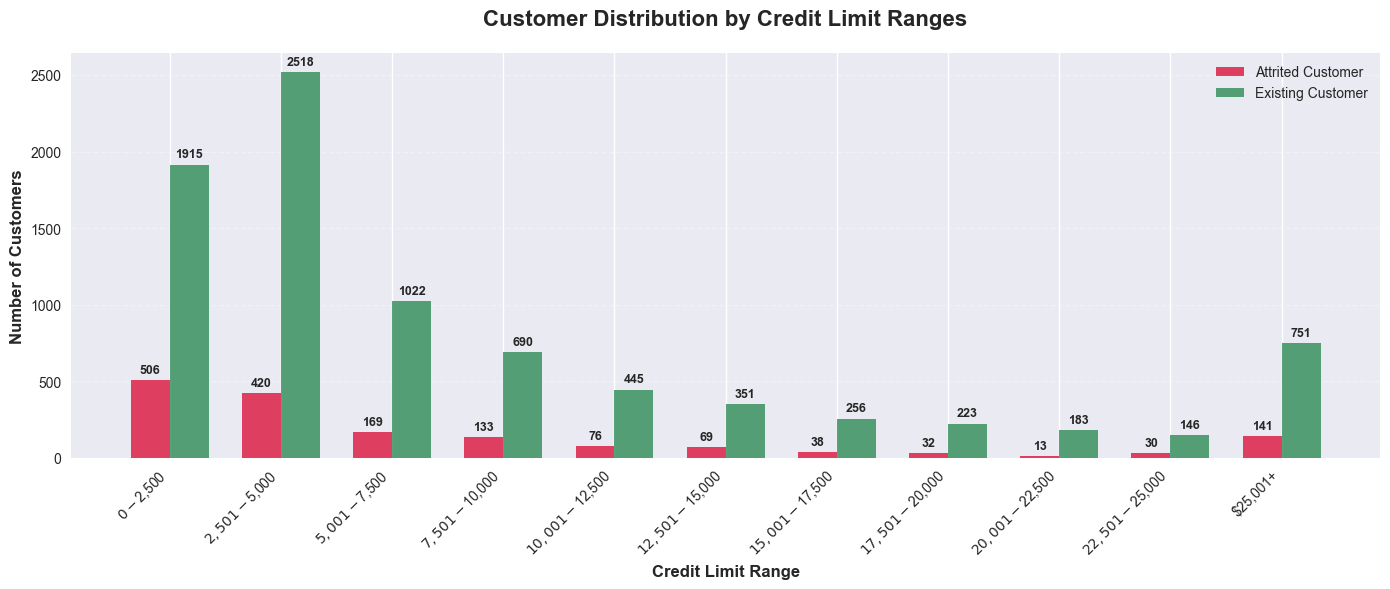

In [111]:

# Get min and max credit limits
min_credit = credit_df['Credit_Limit'].min()
max_credit = credit_df['Credit_Limit'].max()

print(f"Credit Limit Range:")
print(f"Minimum: ${min_credit:,.0f}")
print(f"Maximum: ${max_credit:,.0f}")

# Define logical bin edges based on common credit limit ranges
# These are typical credit limit tiers that make business sense
# Create bin edges increasing by $2,500 each time until $25,000+, then one final bin for $25,000+
bin_edges = [0] + list(range(2500, 25001, 2500)) + [float('inf')]
bin_labels = [
    '$0-$2,500', '$2,501-$5,000', '$5,001-$7,500', '$7,501-$10,000',
    '$10,001-$12,500', '$12,501-$15,000', '$15,001-$17,500', '$17,501-$20,000',
    '$20,001-$22,500', '$22,501-$25,000', '$25,001+'
]

# Create bins using pd.cut
credit_df['Credit_Bin'] = pd.cut(credit_df['Credit_Limit'], 
                                bins=bin_edges, 
                                labels=bin_labels, 
                                include_lowest=True)


# Group by bin and attrition flag
bin_attrition_counts = credit_df.groupby(['Credit_Bin', 'Attrition_Flag']).size().unstack(fill_value=0)

# Ensure all bins are present in the correct order
bin_attrition_counts = bin_attrition_counts.reindex(bin_labels, fill_value=0)

# Create the bar chart
fig, ax = plt.subplots(figsize=(14, 6))

# Set up the bar positions
x_pos = np.arange(len(bin_labels))
width = 0.35

# Create bars for each customer type
attrited_bars = ax.bar(x_pos - width/2, bin_attrition_counts['Attrited Customer'], 
                      width, label='Attrited Customer', color='#DC143C', alpha=0.8)
existing_bars = ax.bar(x_pos + width/2, bin_attrition_counts['Existing Customer'], 
                      width, label='Existing Customer', color='#2E8B57', alpha=0.8)

# Customize the chart
ax.set_title('Customer Distribution by Credit Limit Ranges', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Credit Limit Range', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Customers', fontsize=12, fontweight='bold')

# Set x-axis labels with rotation for better readability
ax.set_xticks(x_pos)
ax.set_xticklabels(bin_labels, rotation=45, ha='right')

# Add legend
ax.legend(loc='upper right', fontsize=10)

# Add value labels on bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # Only add labels for non-zero bars
            ax.annotate(f'{int(height)}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),  # 3 points vertical offset
                       textcoords="offset points",
                       ha='center', va='bottom',
                       fontsize=9, fontweight='bold')

add_value_labels(attrited_bars)
add_value_labels(existing_bars)

# Add grid for better readability
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Improve layout
plt.tight_layout()

# Print attrition rates by bin
print(f"\nAttrition Rate by Credit Limit Range:")
print("-" * 50)
for bin_name in bin_labels:
    if bin_name in bin_attrition_counts.index:
        total = bin_attrition_counts.loc[bin_name].sum()
        attrited = bin_attrition_counts.loc[bin_name, 'Attrited Customer']
        rate = (attrited / total * 100) if total > 0 else 0
        print(f"  {bin_name}: {rate:.1f}% churn rate ({attrited:,}/{total:,} customers)")
    else:
        print(f"  {bin_name}: No customers in this range")

# Calculate some additional insights
print(f"\nAdditional Insights:")
print("-" * 30)

# Find bins with highest and lowest attrition rates
bin_rates = {}
for bin_name in bin_labels:
    if bin_name in bin_attrition_counts.index:
        total = bin_attrition_counts.loc[bin_name].sum()
        if total > 0:
            attrited = bin_attrition_counts.loc[bin_name, 'Attrited Customer']
            rate = (attrited / total * 100)
            bin_rates[bin_name] = rate

if bin_rates:
    highest_churn_bin = max(bin_rates, key=bin_rates.get)
    lowest_churn_bin = min(bin_rates, key=bin_rates.get)
    
    print(f"Highest churn rate: {highest_churn_bin} ({bin_rates[highest_churn_bin]:.1f}%)")
    print(f"Lowest churn rate: {lowest_churn_bin} ({bin_rates[lowest_churn_bin]:.1f}%)")

# Show median credit limit for each customer type
print(f"\nMedian Credit Limit by Customer Type:")
attrited_median = credit_df[credit_df['Attrition_Flag'] == 'Attrited Customer']['Credit_Limit'].median()
existing_median = credit_df[credit_df['Attrition_Flag'] == 'Existing Customer']['Credit_Limit'].median()

print(f"  Attrited Customers: ${attrited_median:,.0f}")
print(f"  Existing Customers: ${existing_median:,.0f}")
print(f"  Difference: ${existing_median - attrited_median:+,.0f}")

plt.show()


### Credit Limit vs Utilization Ratio

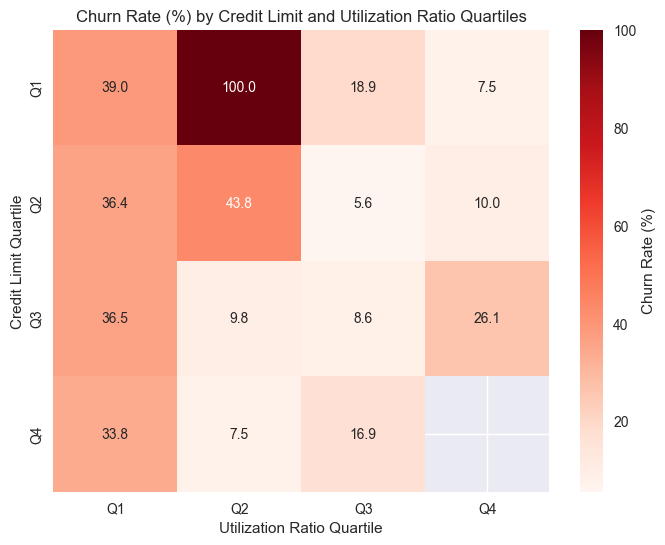

In [112]:

combined_df = new_df.copy()

# Calculate quartiles for Credit_Limit
Q1_CL = combined_df['Credit_Limit'].quantile(0.25)
Q2_CL = combined_df['Credit_Limit'].quantile(0.50)
Q3_CL = combined_df['Credit_Limit'].quantile(0.75)

# Calculate quartiles for Avg_Utilization_Ratio
Q1_UR = combined_df['Avg_Utilization_Ratio'].quantile(0.25)
Q2_UR = combined_df['Avg_Utilization_Ratio'].quantile(0.50)
Q3_UR = combined_df['Avg_Utilization_Ratio'].quantile(0.75)

# Categorize into quartiles
def categorize_quartile(value, Q1, Q2, Q3):
    if value < Q1:
        return 'Q1'
    elif value < Q2:
        return 'Q2'
    elif value < Q3:
        return 'Q3'
    else:
        return 'Q4'

# Apply categorization
combined_df['CreditLimit_Quartile'] = combined_df['Credit_Limit'].apply(lambda x: categorize_quartile(x, Q1_CL, Q2_CL, Q3_CL))
combined_df['Utilization_Quartile'] = combined_df['Avg_Utilization_Ratio'].apply(lambda x: categorize_quartile(x, Q1_UR, Q2_UR, Q3_UR))

# Churn flag (1 = Attrited, 0 = Existing)
combined_df['Churn_Flag'] = combined_df['Attrition_Flag'].apply(lambda x: 1 if x == 'Attrited Customer' else 0)

# Group and pivot for heatmap
churn_quartiles = combined_df.groupby(['CreditLimit_Quartile', 'Utilization_Quartile'])['Churn_Flag'].mean().unstack()

# Reorder for consistent axes
quartile_order = ['Q1', 'Q2', 'Q3', 'Q4']
churn_quartiles = churn_quartiles.reindex(index=quartile_order, columns=quartile_order)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(churn_quartiles * 100, annot=True, fmt=".1f", cmap='Reds', cbar_kws={'label': 'Churn Rate (%)'})
plt.title('Churn Rate (%) by Credit Limit and Utilization Ratio Quartiles')
plt.xlabel('Utilization Ratio Quartile')
plt.ylabel('Credit Limit Quartile')
plt.show()



### Trans Ct vs Util

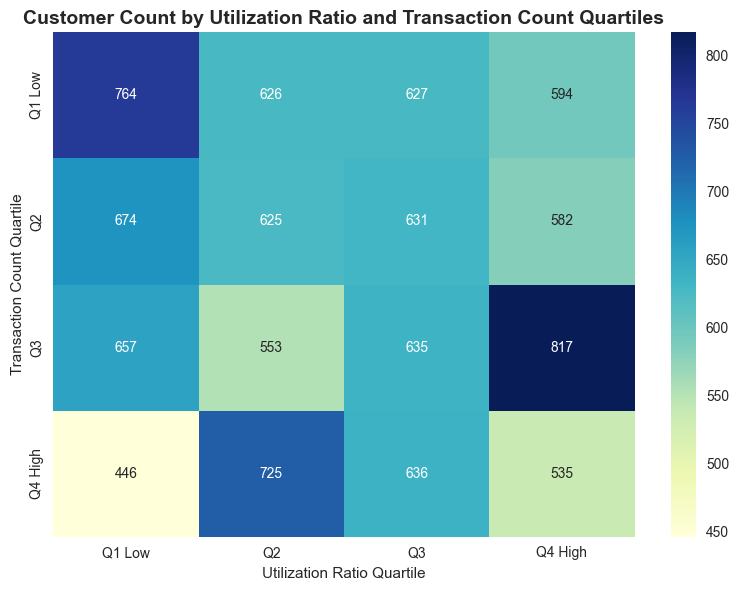

In [113]:

ctutil_df = new_df.copy()

# Create quartiles for Avg_Utilization_Ratio and Total_Trans_Ct
ctutil_df['Util_Quartile'] = pd.qcut(ctutil_df['Avg_Utilization_Ratio'], q=4, labels=['Q1 Low', 'Q2', 'Q3', 'Q4 High'])
ctutil_df['Trans_Quartile'] = pd.qcut(ctutil_df['Total_Trans_Ct'], q=4, labels=['Q1 Low', 'Q2', 'Q3', 'Q4 High'])

# Create a heatmap-style pivot table
heatmap_data = ctutil_df.pivot_table(
    index='Trans_Quartile',
    columns='Util_Quartile',
    values='CLIENTNUM',  # using count of customers
    aggfunc='count'
)

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap='YlGnBu', cbar=True)
plt.title('Customer Count by Utilization Ratio and Transaction Count Quartiles', fontsize=14, fontweight='bold')
plt.xlabel('Utilization Ratio Quartile')
plt.ylabel('Transaction Count Quartile')
plt.tight_layout()
plt.show()


Pearson Correlation Coefficient: 0.00
P-value: 0.7752


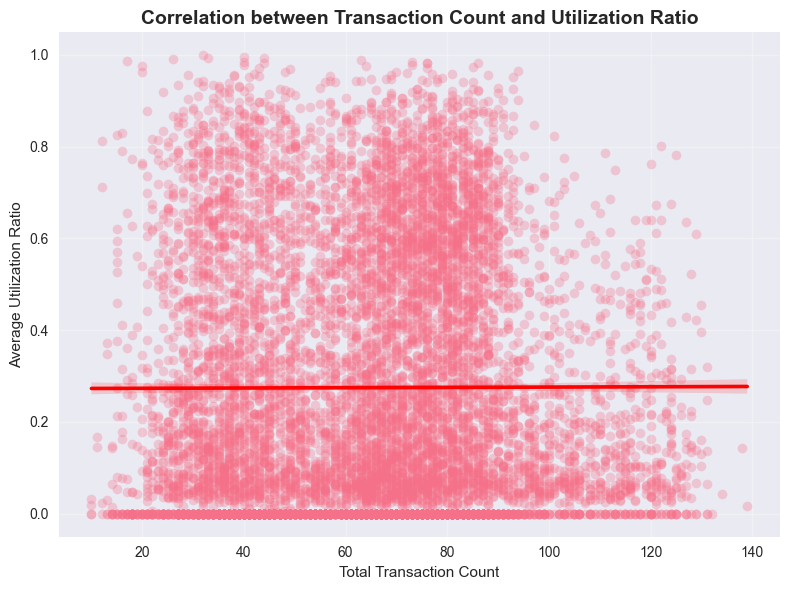

In [114]:

# Calculate correlation coefficient
corr, p_value = pearsonr(ctutil_df['Total_Trans_Ct'], ctutil_df['Avg_Utilization_Ratio'])
print(f"Pearson Correlation Coefficient: {corr:.2f}")
print(f"P-value: {p_value:.4f}")

# Create a regression plot to visualize correlation
plt.figure(figsize=(8, 6))
sns.regplot(x='Total_Trans_Ct', y='Avg_Utilization_Ratio', data=ctutil_df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Correlation between Transaction Count and Utilization Ratio', fontsize=14, fontweight='bold')
plt.xlabel('Total Transaction Count')
plt.ylabel('Average Utilization Ratio')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Credit Summary

-Relvolving Balances had a negative correlation with churn rate. This could mean customers who are using most of their credit are "sticky" and maybe cannot afford to switch, and they are heavy reliant on their credit card.

-Avg Open to buy and credit limit have no correlation, but utilization ratio does, suggesting that the amount of credit you have is not as important as how much of it you use

-Utilization Ratio had slight negative correlation but attrited customers had a higher avg utlization ratio because of many outliers, the iqr was lower. This was an unusual find as you would expect this to be positive and allign with revolving balance. Thhis requires more analysis.

-Low utilization + churn could mean inactive customer not using much before leaving. Maybe they were not interested in product, using another, did not see value in maintaining account.

-Low utlization + Low credit limit = highest churn rate, this is suggesting people have low engagement for whatever reason. However there is no correlation between utlization ratio and total transaction count

-Overall uncertainty of how credit metrics align with churn rates

### Card Category

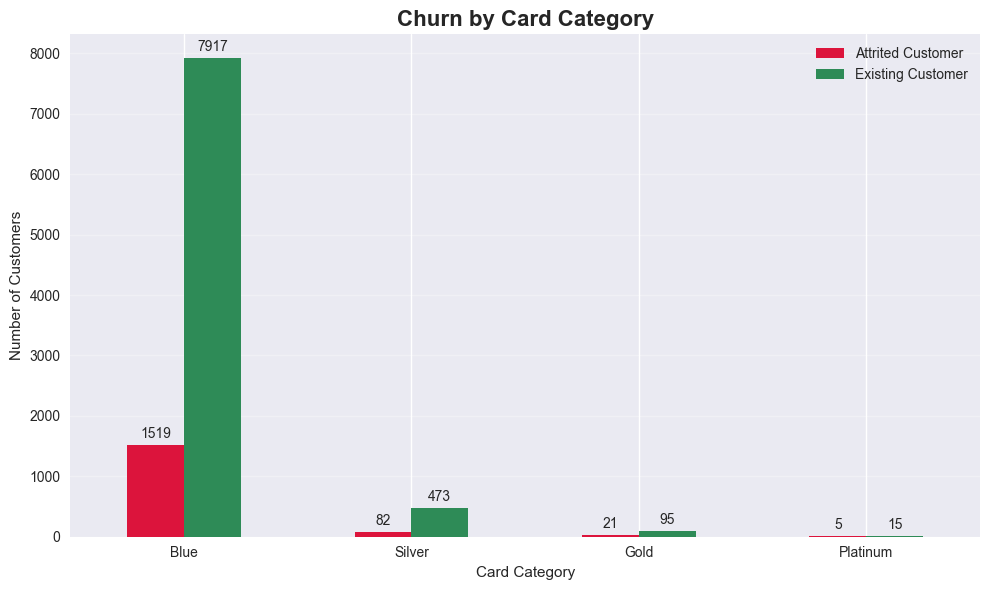


CHURN RATE BY CARD CATEGORY
Blue: 16.1% churn rate (1519/9436 customers)
Silver: 14.8% churn rate (82/555 customers)
Gold: 18.1% churn rate (21/116 customers)
Platinum: 25.0% churn rate (5/20 customers)


In [115]:

card_df = new_df.copy()

# Group by Card_Category and Attrition_Flag
card_counts = card_df.groupby(['Card_Category', 'Attrition_Flag']).size().unstack(fill_value=0)

# Sort by total customers for better readability
card_counts['Total'] = card_counts.sum(axis=1)
card_counts = card_counts.sort_values('Total', ascending=False)
card_counts.drop(columns='Total', inplace=True)

# Plot the bar chart
ax = card_counts.plot(kind='bar', figsize=(10, 6), color=['#DC143C', '#2E8B57'])

plt.title('Churn by Card Category', fontsize=16, fontweight='bold')
plt.xlabel('Card Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(['Attrited Customer', 'Existing Customer'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.show()

# Print churn rate summary
print("\n" + "="*50)
print("CHURN RATE BY CARD CATEGORY")
print("="*50)

for category in card_counts.index:
    existing = card_counts.loc[category, 'Existing Customer']
    attrited = card_counts.loc[category, 'Attrited Customer']
    total = existing + attrited
    churn_rate = (attrited / total) * 100 if total > 0 else 0
    print(f"{category}: {churn_rate:.1f}% churn rate ({attrited}/{total} customers)")


Dependents have no correlation with churn rate

### Education Level

<Figure size 1000x600 with 0 Axes>

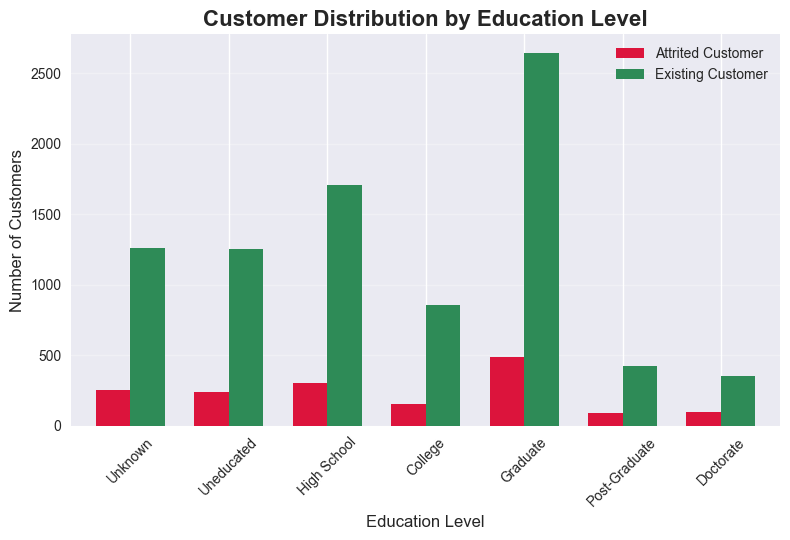


Churn Rates by Education Level:
Unknown: 16.9% churn rate (256/1519)
Uneducated: 15.9% churn rate (237/1487)
High School: 15.2% churn rate (306/2013)
College: 15.2% churn rate (154/1013)
Graduate: 15.6% churn rate (487/3128)
Post-Graduate: 17.8% churn rate (92/516)
Doctorate: 21.1% churn rate (95/451)


In [116]:


edu_df = new_df.copy()

# Create a count of customers by Education_Level and Attrition_Flag
edu_counts = edu_df.groupby(['Education_Level', 'Attrition_Flag']).size().unstack(fill_value=0)

# Ensure consistent order of education levels
edu_order = [
    'Unknown', 'Uneducated', 'High School', 'College',
    'Graduate', 'Post-Graduate', 'Doctorate'
]
edu_counts = edu_counts.reindex(edu_order)

# Plot the bar chart
plt.figure(figsize=(10, 6))
edu_counts.plot(kind='bar', stacked=False, color=['#DC143C', '#2E8B57'], width=0.7)
plt.title('Customer Distribution by Education Level', fontsize=16, fontweight='bold')
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45)
plt.legend(['Attrited Customer', 'Existing Customer'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate churn rate per education level
print("\nChurn Rates by Education Level:")
for level in edu_order:
    total = edu_counts.loc[level].sum()
    attrited = edu_counts.loc[level]['Attrited Customer']
    churn_rate = (attrited / total) * 100 if total > 0 else 0
    print(f"{level}: {churn_rate:.1f}% churn rate ({attrited}/{total})")


## Correlation Matrix

Show heatmap of all variables and their correlation to each other but espesically tp attrition flag

In [ ]:

corrmatrix_df = df.copy()

# Encode categorical variables
# Manual encoding for Attrition Flag to ensure correct mapping
corrmatrix_df['Attrition_Flag_Encoded'] = corrmatrix_df['Attrition_Flag'].map({
    'Attrited Customer': 1,  # 1 = Churned
    'Existing Customer': 0   # 0 = Retained
})


# Encode Gender
le_gender = LabelEncoder()
corrmatrix_df['Gender_Encoded'] = le_gender.fit_transform(corrmatrix_df['Gender'])
print(f"\nGender Encoding:")
print(f"Classes: {le_gender.classes_}")

# Encode Education Level with ordinal mapping (maintaining order)
education_mapping = {
    'Unknown': 0,
    'Uneducated': 1,
    'High School': 2,
    'College': 3,
    'Graduate': 4,
    'Post-Graduate': 5,
    'Doctorate': 6
}
corrmatrix_df['Education_Level_Encoded'] = corrmatrix_df['Education_Level'].map(education_mapping)

# Encode Marital Status
le_marital = LabelEncoder()
corrmatrix_df['Marital_Status_Encoded'] = le_marital.fit_transform(corrmatrix_df['Marital_Status'])
print(f"\nMarital Status Encoding:")
print(f"Classes: {le_marital.classes_}")

# Encode Income Category with ordinal mapping
income_mapping = {
    'Unknown': 0,
    'Less than $40K': 1,
    '$40K - $60K': 2,
    '$60K - $80K': 3,
    '$80K - $120K': 4,
    '$120K +': 5
}
corrmatrix_df['Income_Category_Encoded'] = corrmatrix_df['Income_Category'].map(income_mapping)

# Encode Card Category (could be ordinal based on card tier)
card_mapping = {
    'Blue': 1,
    'Silver': 2,
    'Gold': 3,
    'Platinum': 4
}
corrmatrix_df['Card_Category_Encoded'] = corrmatrix_df['Card_Category'].map(card_mapping)

# Select columns for correlation analysis (encoded versions + numerical columns)
correlation_columns = [
    'Attrition_Flag_Encoded',
    'Customer_Age',
    'Gender_Encoded',
    'Dependent_count',
    'Education_Level_Encoded',
    'Marital_Status_Encoded',
    'Income_Category_Encoded',
    'Card_Category_Encoded',
    'Months_on_book',
    'Total_Relationship_Count',
    'Months_Inactive_12_mon',
    'Contacts_Count_12_mon',
    'Credit_Limit',
    'Total_Revolving_Bal',
    'Avg_Open_To_Buy',
    'Total_Amt_Chng_Q4_Q1',
    'Total_Trans_Amt',
    'Total_Trans_Ct',
    'Total_Ct_Chng_Q4_Q1',
    'Avg_Utilization_Ratio'
]

# Create correlation matrix
correlation_matrix = corrmatrix_df[correlation_columns].corr()




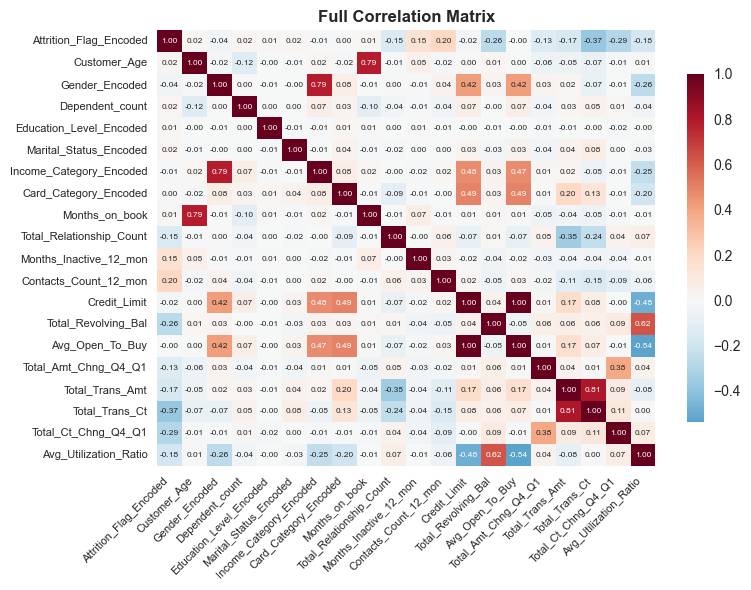

In [118]:

# 1. Full correlation matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            fmt='.2f',
            square=False,
            annot_kws={'fontsize': 6},
            cbar_kws={'shrink': 0.8})
plt.title('Full Correlation Matrix', fontsize=12, fontweight='bold')
plt.xticks(fontsize=8, rotation=45, ha='right')
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.show()


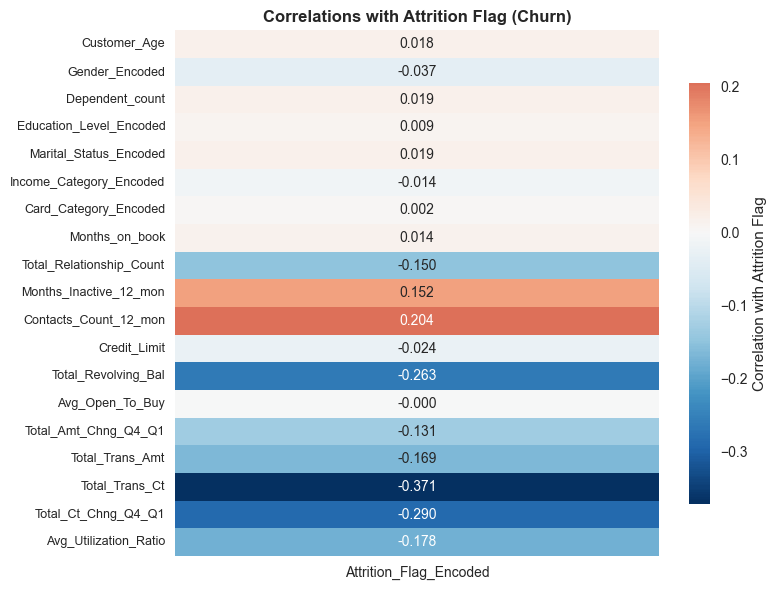

In [121]:

# 2. Correlation with Attrition Flag only
plt.figure(figsize=(8, 6))
attrition_corr_df = attrition_corr.drop('Attrition_Flag_Encoded').to_frame()
sns.heatmap(attrition_corr_df, 
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            fmt='.3f',
            cbar_kws={'label': 'Correlation with Attrition Flag', 'shrink': 0.8},
            annot_kws={'fontsize': 10})
plt.title('Correlations with Attrition Flag (Churn)', fontsize=12, fontweight='bold')
plt.xlabel('')
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.show()


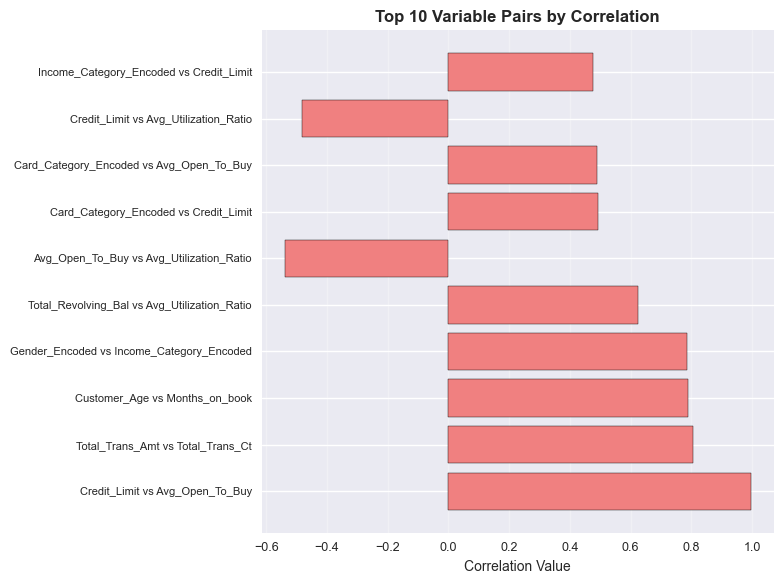

In [ ]:

# 4. Top correlations (excluding self-correlation)
top_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        var1 = correlation_matrix.columns[i]
        var2 = correlation_matrix.columns[j]
        corr_val = correlation_matrix.iloc[i, j]
        if var1 != 'Attrition_Flag_Encoded' and var2 != 'Attrition_Flag_Encoded':
            top_corr_pairs.append((f"{var1} vs {var2}", abs(corr_val), corr_val))

top_corr_pairs.sort(key=lambda x: x[1], reverse=True)
top_10_pairs = top_corr_pairs[:10]

pair_names = [pair[0] for pair in top_10_pairs]
corr_values = [pair[2] for pair in top_10_pairs]

plt.figure(figsize=(8, 6))
plt.barh(range(len(pair_names)), corr_values, color='lightcoral', edgecolor='black')
plt.yticks(range(len(pair_names)), pair_names, fontsize=8)
plt.title('Top 10 Variable Pairs by Correlation', fontsize=12, fontweight='bold')
plt.xlabel('Correlation Value', fontsize=10)
plt.xticks(fontsize=9)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:

# Summary statistics and insights
print("\n" + "="*60)
print("KEY INSIGHTS AND INTERPRETATION GUIDE")
print("="*60)

print("\n1. HOW TO READ CORRELATION VALUES:")
print("   • +1.0 = Perfect positive correlation")
print("   • +0.7 to +1.0 = Strong positive correlation")
print("   • +0.3 to +0.7 = Moderate positive correlation")
print("   • +0.1 to +0.3 = Weak positive correlation")
print("   • -0.1 to +0.1 = No correlation")
print("   • -0.1 to -0.3 = Weak negative correlation")
print("   • -0.3 to -0.7 = Moderate negative correlation")
print("   • -0.7 to -1.0 = Strong negative correlation")
print("   • -1.0 = Perfect negative correlation")

print("\n3. STRONGEST PREDICTORS OF CHURN:")
strongest_predictors = attrition_corr.drop('Attrition_Flag_Encoded').abs().sort_values(ascending=False)[:5]
for i, (var, corr) in enumerate(strongest_predictors.items(), 1):
    actual_corr = attrition_corr[var]
    print(f"   {i}. {var}: {actual_corr:.4f} (absolute: {corr:.4f})")




KEY INSIGHTS AND INTERPRETATION GUIDE

1. HOW TO READ CORRELATION VALUES:
   • +1.0 = Perfect positive correlation
   • +0.7 to +1.0 = Strong positive correlation
   • +0.3 to +0.7 = Moderate positive correlation
   • +0.1 to +0.3 = Weak positive correlation
   • -0.1 to +0.1 = No correlation
   • -0.1 to -0.3 = Weak negative correlation
   • -0.3 to -0.7 = Moderate negative correlation
   • -0.7 to -1.0 = Strong negative correlation
   • -1.0 = Perfect negative correlation

3. STRONGEST PREDICTORS OF CHURN:
   1. Total_Trans_Ct: -0.3714 (absolute: 0.3714)
   2. Total_Ct_Chng_Q4_Q1: -0.2901 (absolute: 0.2901)
   3. Total_Revolving_Bal: -0.2631 (absolute: 0.2631)
   4. Contacts_Count_12_mon: 0.2045 (absolute: 0.2045)
   5. Avg_Utilization_Ratio: -0.1784 (absolute: 0.1784)


### Summary

- Clear that disengaged, low volume customers are primary churn targets
-Evident with transaction count and count change being the top 2 highest correlating, but also relationships and avg utlization ratio having a negative correlation and months inactive having a positive correlation furthering the disengagement theory
-customer contact count should be considered as a unique variable to suggest customers who are speaking to service representatives more are having a negative expereince and can leave quickly as contact count was not closely related to other variables
-age not as important as originally thought could be due to smaller smaple size of old age groups


## Training Models

Implement a Logistic Regression and Random Forest model to predict churned customers. The logistic regression has a default parameter run called Log Reg and one with optimized parameters for recall to minimize false negatives called Tuned Logistic Regression

### Split Data

In [123]:


# 1. Prepare features and target
X = corrmatrix_df[correlation_columns].drop('Attrition_Flag_Encoded', axis=1)
y = corrmatrix_df['Attrition_Flag_Encoded']

# 2. Stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,           # 80% train, 20% test
    random_state=42,         # Reproducible results
    stratify=y               # Maintain churn/non-churn ratio
)
#Validation set used for hyperparameter tuning and model selection
# 3. Further split training into train/validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train,
    test_size=0.25,          # 60% train, 20% val, 20% test
    random_state=42,
    stratify=y_train
)
#scaling helps remove bias from larger numerical values that aren't necessarily more important and giving all columns
# a similar range
#ex transaction amount vs age. Instead standard scaler takes the unit variance of each column,
#it gives a mean of 0 and std dev of 1 for each feature.
# 4. Scale features (important for correlation-based features)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

### Log Reg

In [124]:


# ============================================================================
# 1. BASELINE LOGISTIC REGRESSION MODEL
# ============================================================================

print("\n" + "="*60)
print("1. TRAINING BASELINE LOGISTIC REGRESSION MODEL")
print("="*60)

# Initialize logistic regression with balanced class weights
lr_baseline = LogisticRegression(
    random_state=42,
    class_weight='balanced',  # Handle class imbalance
    max_iter=1000
)

# Train the model on data finding optimal coefficients, takes  scaled training data
#No hyperparameter tuning is done here, this is just a baseline model
lr_baseline.fit(X_train_scaled, y_train_final)

# Make predictions, first 2 lines retun an array of predicted classes, the next two return an array of probabilities
#used for AUC calculation
y_train_pred = lr_baseline.predict(X_train_scaled)
y_val_pred = lr_baseline.predict(X_val_scaled)
y_train_proba = lr_baseline.predict_proba(X_train_scaled)[:, 1]
y_val_proba = lr_baseline.predict_proba(X_val_scaled)[:, 1]

# Print baseline results
print("Baseline Model Performance:")
print(f"Training Accuracy: {accuracy_score(y_train_final, y_train_pred):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Training AUC: {roc_auc_score(y_train_final, y_train_proba):.4f}")
print(f"Validation AUC: {roc_auc_score(y_val, y_val_proba):.4f}")



1. TRAINING BASELINE LOGISTIC REGRESSION MODEL
Baseline Model Performance:
Training Accuracy: 0.8525
Validation Accuracy: 0.8381
Training AUC: 0.9300
Validation AUC: 0.9196


In [ ]:

# ============================================================================
# 2. HYPERPARAMETER TUNING TO FIND OPTIMAL SETTINGS
# ============================================================================

print("\n" + "="*60)
print("2. HYPERPARAMETER TUNING")
print("="*60)

# Define parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],           # Regularization strength
    'penalty': ['l1', 'l2', 'elasticnet'],   # Regularization type
    'solver': ['liblinear', 'saga'],         # Solver algorithms
    'l1_ratio': [0.1, 0.5, 0.9]            # ElasticNet mixing parameter
}

# Create tuned logistic regression model
lr_baseline = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000
)

# Grid search with cross-validation
print("Performing Grid Search (this may take a few minutes)...")
grid_search = GridSearchCV(
    lr_baseline,
    param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='roc_auc',       # Use AUC as scoring metric
    n_jobs=-1,               # Use all available cores
    verbose=1
)

# Fit grid search and re train on scaled training data
grid_search.fit(X_train_scaled, y_train_final)

# Get best model
best_lr = grid_search.best_estimator_
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation AUC: {grid_search.best_score_:.4f}")



2. HYPERPARAMETER TUNING
Performing Grid Search (this may take a few minutes)...
Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best Parameters: {'C': 1, 'l1_ratio': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation AUC: 0.9276


In [126]:

# ============================================================================
# 3. FINAL MODEL EVALUATION
# ============================================================================

print("\n" + "="*60)
print("3. FINAL MODEL EVALUATION")
print("="*60)

# Make predictions with best model
y_train_pred_best = best_lr.predict(X_train_scaled)
y_val_pred_best = best_lr.predict(X_val_scaled)
y_test_pred_best = best_lr.predict(X_test_scaled)

y_train_proba_best = best_lr.predict_proba(X_train_scaled)[:, 1]
y_val_proba_best = best_lr.predict_proba(X_val_scaled)[:, 1]
y_test_proba_best = best_lr.predict_proba(X_test_scaled)[:, 1]

# Performance metrics
print("Final Model Performance:")
print(f"Training Accuracy: {accuracy_score(y_train_final, y_train_pred_best):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val, y_val_pred_best):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_best):.4f}")

print(f"\nTraining AUC: {roc_auc_score(y_train_final, y_train_proba_best):.4f}")
print(f"Validation AUC: {roc_auc_score(y_val, y_val_proba_best):.4f}")
print(f"Test AUC: {roc_auc_score(y_test, y_test_proba_best):.4f}")

# Detailed classification report
print("\nDetailed Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred_best))



3. FINAL MODEL EVALUATION
Final Model Performance:
Training Accuracy: 0.8525
Validation Accuracy: 0.8376
Test Accuracy: 0.8529

Training AUC: 0.9300
Validation AUC: 0.9195
Test AUC: 0.9173

Detailed Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.96      0.86      0.91      1701
           1       0.53      0.82      0.64       325

    accuracy                           0.85      2026
   macro avg       0.74      0.84      0.77      2026
weighted avg       0.89      0.85      0.86      2026




4. FEATURE IMPORTANCE ANALYSIS
Top 10 Most Important Features:
                     Feature  Coefficient  Abs_Coefficient
16            Total_Trans_Ct    -2.980504         2.980504
15           Total_Trans_Amt     1.773654         1.773654
17       Total_Ct_Chng_Q4_Q1    -0.609327         0.609327
10     Contacts_Count_12_mon     0.598811         0.598811
8   Total_Relationship_Count    -0.582874         0.582874
9     Months_Inactive_12_mon     0.575405         0.575405
12       Total_Revolving_Bal    -0.545555         0.545555
1             Gender_Encoded    -0.460567         0.460567
18     Avg_Utilization_Ratio    -0.254456         0.254456
5    Income_Category_Encoded     0.186317         0.186317


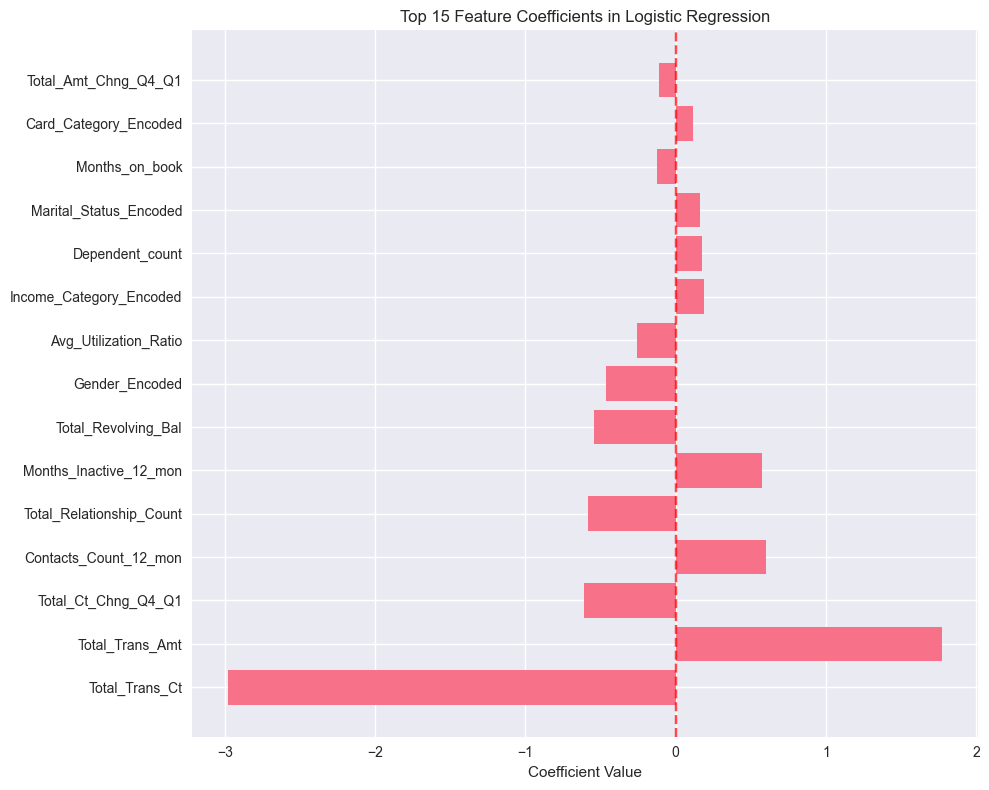

In [127]:

# ============================================================================
# 4. FEATURE IMPORTANCE ANALYSIS
# ============================================================================

print("\n" + "="*60)
print("4. FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature coefficients
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_lr.coef_[0],
    'Abs_Coefficient': np.abs(best_lr.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

# Plot feature importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['Coefficient'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coefficient Value')
plt.title('Top 15 Feature Coefficients in Logistic Regression')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


look at coef functiom above and understand all important fns in code


5. CREATING VISUALIZATIONS


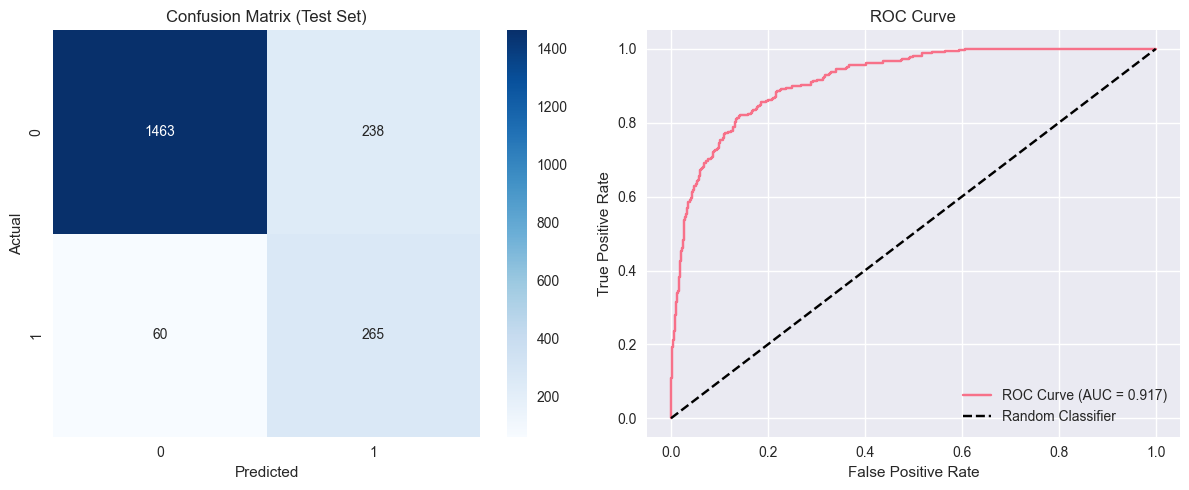

In [128]:

# ============================================================================
# 5. VISUALIZATION OF RESULTS
# ============================================================================

print("\n" + "="*60)
print("5. CREATING VISUALIZATIONS")
print("="*60)

# Create subplots for confusion matrix and ROC curve only
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix (Test Set)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba_best)
axes[1].plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_test_proba_best):.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()


check roc for false neg

In [129]:

# ============================================================================
# 6. MODEL INTERPRETATION
# ============================================================================

print("\n" + "="*60)
print("6. MODEL INTERPRETATION")
print("="*60)

# Positive coefficients (increase churn probability)
positive_coef = feature_importance[feature_importance['Coefficient'] > 0].head(5)
print("Top 5 factors that INCREASE churn probability:")
for idx, row in positive_coef.iterrows():
    print(f"  {row['Feature']}: {row['Coefficient']:.4f}")

# Negative coefficients (decrease churn probability)
negative_coef = feature_importance[feature_importance['Coefficient'] < 0].head(5)
print("\nTop 5 factors that DECREASE churn probability:")
for idx, row in negative_coef.iterrows():
    print(f"  {row['Feature']}: {row['Coefficient']:.4f}")



6. MODEL INTERPRETATION
Top 5 factors that INCREASE churn probability:
  Total_Trans_Amt: 1.7737
  Contacts_Count_12_mon: 0.5988
  Months_Inactive_12_mon: 0.5754
  Income_Category_Encoded: 0.1863
  Dependent_count: 0.1743

Top 5 factors that DECREASE churn probability:
  Total_Trans_Ct: -2.9805
  Total_Ct_Chng_Q4_Q1: -0.6093
  Total_Relationship_Count: -0.5829
  Total_Revolving_Bal: -0.5456
  Gender_Encoded: -0.4606


In [130]:

# ============================================================================
# 7. SAVE MODEL AND RESULTS
# ============================================================================

print("\n" + "="*60)
print("7. MODEL SUMMARY")
print("="*60)

# Model summary
print("Final Model Configuration:")
print(f"  Algorithm: Logistic Regression")
print(f"  Regularization: {best_lr.penalty}")
print(f"  C parameter: {best_lr.C}")
print(f"  Solver: {best_lr.solver}")
print(f"  Class Weight: {best_lr.class_weight}")

print(f"\nModel Performance:")
print(f"  Test Accuracy: {accuracy_score(y_test, y_test_pred_best):.4f}")
print(f"  Test AUC: {roc_auc_score(y_test, y_test_proba_best):.4f}")

# Example of making predictions on new data
print(f"\nTo make predictions on new data:")
print(f"  1. Scale new data using: scaler.transform(new_data)")
print(f"  2. Predict probabilities: best_lr.predict_proba(scaled_new_data)")
print(f"  3. Predict classes: best_lr.predict(scaled_new_data)")



7. MODEL SUMMARY
Final Model Configuration:
  Algorithm: Logistic Regression
  Regularization: l2
  C parameter: 1
  Solver: liblinear
  Class Weight: balanced

Model Performance:
  Test Accuracy: 0.8529
  Test AUC: 0.9173

To make predictions on new data:
  1. Scale new data using: scaler.transform(new_data)
  2. Predict probabilities: best_lr.predict_proba(scaled_new_data)
  3. Predict classes: best_lr.predict(scaled_new_data)


### Tuned Logistic Regression

percision = correctly classified as pos or neg / true pos or neg + false pos or neg
recall aka true positive rate = true positives / tp + fn

0 - existing 
1- attrited
Actual- True Negative, True Positive
True Negative - 0,0
False Positive - Actual 0 Predicted 1
False Negative - Actual 1 Predicted 0
True Positive - 1,1 

-AUC represents the probability that the model, if given a randomly chosen positive and negative example, will rank the positive higher than the negative.
-false negative acceptable amount? adjust to lower as better to have false positives
-learn scaler and train/split code
-compare tweaked model to original and find general churn accuracy info

-make sure no duplicate variables between models

 Typical Bank churn is around 15-20% per year, however "healthy" amount is less than 10%, customer service cited as number one reason for churn

 https://www.qualtrics.com/blog/customer-churn-banking/

In [131]:


# ============================================================================
# 1. BASELINE LOGISTIC REGRESSION MODEL
# ============================================================================

print("\n" + "="*60)
print("1. TRAINING BASELINE LOGISTIC REGRESSION MODEL")
print("="*60)

#  Adjust class weights to penalize false negatives more
# Calculate custom class weights that heavily penalize false negatives


# Option 1: More aggressive class weighting
class_weights = compute_class_weight('balanced', 
                                   classes=np.unique(y_train_final), 
                                   y=y_train_final)
# Increase weight for positive class to reduce false negatives
custom_class_weight = {0: class_weights[0], 1: class_weights[1] * 2}  # Double the positive class weight

# Option 2: Or use a manual ratio (adjust based on your domain knowledge)
# custom_class_weight = {0: 1, 1: 5}  # 5x penalty for missing positive cases

lr_tuned = LogisticRegression(
    random_state=42,
    class_weight=custom_class_weight,  # Use custom weights
    max_iter=1000
)

# Train the model
lr_tuned.fit(X_train_scaled, y_train_final)

# Make predictions
y_train_pred = lr_tuned.predict(X_train_scaled)
y_val_pred = lr_tuned.predicdt(X_val_scaled)
y_train_proba = lr_tuned.predict_proba(X_train_scaled)[:, 1]
y_val_proba = lr_tuned.predict_proba(X_val_scaled)[:, 1]

# Print baseline results
print("Baseline Model Performance:")
print(f"Training Accuracy: {accuracy_score(y_train_final, y_train_pred):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Training AUC: {roc_auc_score(y_train_final, y_train_proba):.4f}")
print(f"Validation AUC: {roc_auc_score(y_val, y_val_proba):.4f}")

# Check false negatives in baseline
from sklearn.metrics import confusion_matrix, recall_score, precision_score
cm_baseline = confusion_matrix(y_val, y_val_pred)
print(f"Validation False Negatives: {cm_baseline[1,0]}")
print(f"Validation False Positives: {cm_baseline[0,1]}")



1. TRAINING BASELINE LOGISTIC REGRESSION MODEL


AttributeError: 'LogisticRegression' object has no attribute 'predicdt'

In [ ]:

# ============================================================================
# 2. HYPERPARAMETER TUNING WITH RECALL FOCUS
# ============================================================================

print("\n" + "="*60)
print("2. HYPERPARAMETER TUNING WITH RECALL OPTIMIZATION")
print("="*60)

# Expand parameter grid and optimize for recall
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],  # Extended range
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['liblinear', 'saga'],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
    # Test different class weight strategies
    'class_weight': [
        'balanced',
        {0: 1, 1: 3},    # 3x weight for positive class
        {0: 1, 1: 5},    # 5x weight for positive class
        {0: 1, 1: 7},    # 7x weight for positive class
    ]
}

# Create logistic regression model
lr_tuned = LogisticRegression(
    random_state=42,
    max_iter=2000  # Increased iterations for convergence
)

# Use recall as primary scoring metric
print("Performing Grid Search optimized for recall...")
grid_search = GridSearchCV(
    lr_tuned,
    param_grid,
    cv=5,
    scoring='recall',  # Optimize for recall (sensitivity) to reduce false negatives
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid_search.fit(X_train_scaled, y_train_final)

# Get best model
best_lr = grid_search.best_estimator_
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Recall: {grid_search.best_score_:.4f}")



2. HYPERPARAMETER TUNING WITH RECALL OPTIMIZATION
Performing Grid Search optimized for recall...
Fitting 5 folds for each of 840 candidates, totalling 4200 fits

Best Parameters: {'C': 0.001, 'class_weight': {0: 1, 1: 7}, 'l1_ratio': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-Validation Recall: 0.9068


In [132]:

# ============================================================================
# 3. THRESHOLD OPTIMIZATION
# ============================================================================

print("\n" + "="*60)
print("3. THRESHOLD OPTIMIZATION TO REDUCE FALSE NEGATIVES")
print("="*60)

# Find optimal threshold that minimizes false negatives


# Get probabilities for validation set
y_val_proba_best = best_lr.predict_proba(X_val_scaled)[:, 1]

# Calculate precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba_best)

# Find threshold that maximizes recall while maintaining reasonable precision
# Adjust min_precision based on your requirements
min_precision = 0.3  # Minimum acceptable precision
valid_indices = precisions >= min_precision

if len(valid_indices) > 0 and np.any(valid_indices):
    # Find threshold with highest recall among valid precisions
    best_threshold_idx = np.where(valid_indices)[0][np.argmax(recalls[valid_indices])]
    optimal_threshold = thresholds[best_threshold_idx]
else:
    # If no valid precision found, use threshold that maximizes recall
    optimal_threshold = thresholds[np.argmax(recalls[:-1])]

print(f"Optimal threshold for reducing false negatives: {optimal_threshold:.4f}")
print(f"Default threshold: 0.5000")



3. THRESHOLD OPTIMIZATION TO REDUCE FALSE NEGATIVES
Optimal threshold for reducing false negatives: 0.1395
Default threshold: 0.5000


In [133]:

# ============================================================================
# 4. FINAL MODEL EVALUATION WITH OPTIMIZED THRESHOLD
# ============================================================================

print("\n" + "="*60)
print("4. FINAL MODEL EVALUATION WITH OPTIMIZED THRESHOLD")
print("="*60)

# Function to make predictions with custom threshold
def predict_with_threshold(model, X, threshold=0.5):
    probas = model.predict_proba(X)[:, 1]
    return (probas >= threshold).astype(int)

# Make predictions with both default and optimized thresholds
y_test_pred_default = best_lr.predict(X_test_scaled)
y_test_pred_optimized = predict_with_threshold(best_lr, X_test_scaled, optimal_threshold)
y_test_proba_best = best_lr.predict_proba(X_test_scaled)[:, 1]

# Performance comparison
print("COMPARISON: Default vs Optimized Threshold")
print("-" * 50)

# Default threshold (0.5)
cm_default = confusion_matrix(y_test, y_test_pred_default)
print("Default Threshold (0.5):")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_default):.4f}")
print(f"Test AUC: {roc_auc_score(y_test, y_test_proba_best):.4f}")
print(f"False Negatives: {cm_default[1,0]}")
print(f"False Positives: {cm_default[0,1]}")
print(f"Recall (Sensitivity): {recall_score(y_test, y_test_pred_default):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_default):.4f}")

print()

# Optimized threshold
cm_optimized = confusion_matrix(y_test, y_test_pred_optimized)
print(f"Optimized Threshold ({optimal_threshold:.4f}):")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_optimized):.4f}")
print(f"Test AUC: {roc_auc_score(y_test, y_test_proba_best):.4f}")
print(f"False Negatives: {cm_optimized[1,0]}")
print(f"False Positives: {cm_optimized[0,1]}")
print(f"Recall (Sensitivity): {recall_score(y_test, y_test_pred_optimized):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_optimized):.4f}")

# Improvement summary
fn_reduction = cm_default[1,0] - cm_optimized[1,0]
print(f"\nFalse Negative Reduction: {fn_reduction} ({fn_reduction/max(cm_default[1,0], 1)*100:.1f}%)")

# Detailed classification report
print("\nDetailed Classification Report (Test Set - Optimized):")
print(classification_report(y_test, y_test_pred_optimized))



4. FINAL MODEL EVALUATION WITH OPTIMIZED THRESHOLD
COMPARISON: Default vs Optimized Threshold
--------------------------------------------------
Default Threshold (0.5):
Test Accuracy: 0.8529
Test AUC: 0.9173
False Negatives: 60
False Positives: 238


NameError: name 'recall_score' is not defined


7. CREATING COMPREHENSIVE VISUALIZATIONS


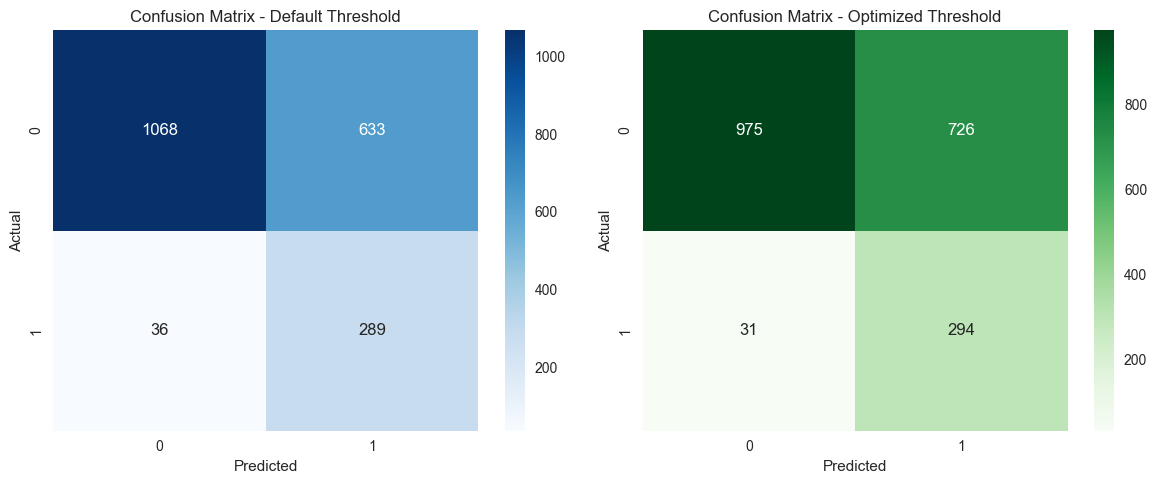

In [ ]:

# ============================================================================
# 7. COMPREHENSIVE VISUALIZATION
# ============================================================================

print("\n" + "="*60)
print("7. CREATING COMPREHENSIVE VISUALIZATIONS")
print("="*60)
# 1. Confusion Matrices (Default & Optimized Threshold)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Default Threshold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix - Optimized Threshold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


Optimized False Negative rate - 1.53%
-Not sure if this is overall better, false negatives are lower but so is total accuracy.
-When scoring set for recall and weights imbalanced accuracy drops, was around 88% before 

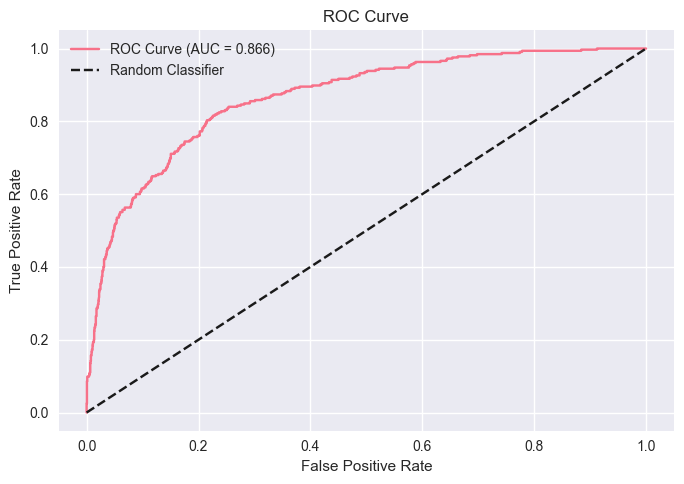

In [ ]:

# 2. Area Under Curve (ROC Curve)
plt.figure(figsize=(7, 5))
fpr, tpr, _ = roc_curve(y_test, y_test_proba_best)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_test_proba_best):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()


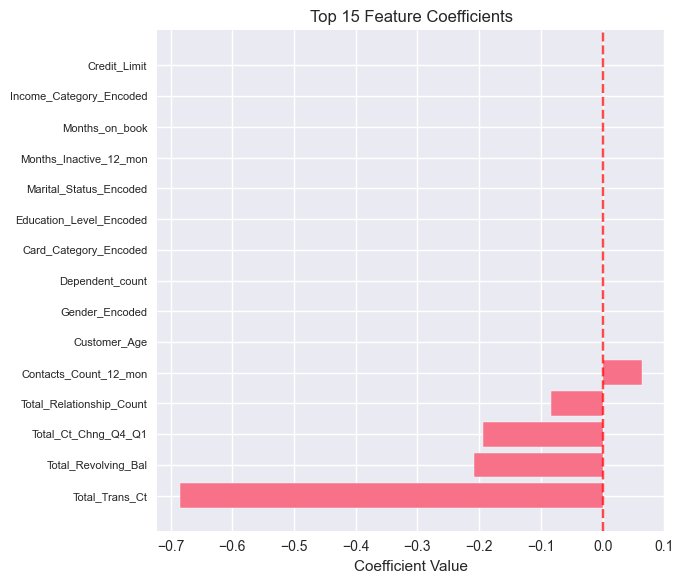

In [ ]:

# 3. Feature Coefficient Matrix
top_features = feature_importance.head(15)
plt.figure(figsize=(7, 6))
plt.barh(range(len(top_features)), top_features['Coefficient'])
plt.yticks(range(len(top_features)), top_features['Feature'], fontsize=8)
plt.xlabel('Coefficient Value')
plt.title('Top 15 Feature Coefficients')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Random Forest

In [134]:

# ============================================================================
# 1. BASELINE RANDOM FOREST MODEL
# ============================================================================

# Ensure X_train_final is defined

print("\n" + "="*60)
print("1. TRAINING BASELINE RANDOM FOREST MODEL")
print("="*60)

# Initialize Random Forest with basic parameters
rf_baseline = RandomForestClassifier(
    n_estimators=100,           # Number of trees
    random_state=42,
    class_weight='balanced',    # Handle class imbalance
    n_jobs=-1                   # Use all available cores
)

# Train the model (using unscaled data - RF doesn't need scaling because it is tree-based,
# order of values instead of magnitudue)
# No hyperparameter tuning is done here, this is just a baseline model
rf_baseline.fit(X_train_final, y_train_final)

# Make predictions
y_train_pred = rf_baseline.predict(X_train_final)
y_val_pred = rf_baseline.predict(X_val)
y_train_proba = rf_baseline.predict_proba(X_train_final)[:, 1]
y_val_proba = rf_baseline.predict_proba(X_val)[:, 1]

# Print baseline results
print("Baseline Random Forest Performance:")
print(f"Training Accuracy: {accuracy_score(y_train_final, y_train_pred):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Training AUC: {roc_auc_score(y_train_final, y_train_proba):.4f}")
print(f"Validation AUC: {roc_auc_score(y_val, y_val_proba):.4f}")



1. TRAINING BASELINE RANDOM FOREST MODEL
Baseline Random Forest Performance:
Training Accuracy: 1.0000
Validation Accuracy: 0.9506
Training AUC: 1.0000
Validation AUC: 0.9862


In [ ]:

# ============================================================================
# 2. HYPERPARAMETER TUNING TO FIND OPTIMAL SETTINGS WITH AUC FOCUS
# ============================================================================

print("\n" + "="*60)
print("2. HYPERPARAMETER TUNING")
print("="*60)

param_grid = {
    'n_estimators': [100, 200],                # Number of trees 
    'max_depth': [10, 20, None],               # Maximum depth of trees 
    'min_samples_split': [2, 5],               # Minimum samples to split 
    'min_samples_leaf': [1, 2],                # Minimum samples in leaf 
    'max_features': ['sqrt', 'log2'],          # Number of features to consider 
    'bootstrap': [True]                        # Bootstrap samples 
}


print(f"Testing {np.prod([len(v) for v in param_grid.values()])} parameter combinations...")

# Create Random Forest model
rf_tuned = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Grid search with cross-validation
print("Performing Grid Search (this may take several minutes)...")
grid_search = GridSearchCV(
    rf_tuned,
    param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='roc_auc',       # Use AUC as scoring metric
    n_jobs=-1,               # Use all available cores
    verbose=1
)

# Fit grid search
grid_search.fit(X_train_final, y_train_final)

# Get best model
best_rf = grid_search.best_estimator_
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation AUC: {grid_search.best_score_:.4f}")



2. HYPERPARAMETER TUNING
Testing 48 parameter combinations...
Performing Grid Search (this may take several minutes)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best Parameters: {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation AUC: 0.9883


In [136]:

# ============================================================================
# 3. FINAL MODEL EVALUATION
# ============================================================================

print("\n" + "="*60)
print("3. FINAL MODEL EVALUATION")
print("="*60)

# These lines generate predicted class labels (0 or 1) for each dataset
y_train_pred_best = best_rf.predict(X_train_final)
y_val_pred_best = best_rf.predict(X_val)
y_test_pred_best = best_rf.predict(X_test)

#These lines generate predicted probabilities of class 1
y_train_proba_best = best_rf.predict_proba(X_train_final)[:, 1]
y_val_proba_best = best_rf.predict_proba(X_val)[:, 1]
y_test_proba_best = best_rf.predict_proba(X_test)[:, 1]

# Performance metrics
print("Final Random Forest Performance:")
print(f"Training Accuracy: {accuracy_score(y_train_final, y_train_pred_best):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val, y_val_pred_best):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_best):.4f}")

print(f"\nTraining AUC: {roc_auc_score(y_train_final, y_train_proba_best):.4f}")
print(f"Validation AUC: {roc_auc_score(y_val, y_val_proba_best):.4f}")
print(f"Test AUC: {roc_auc_score(y_test, y_test_proba_best):.4f}")

#Calculates the difference between training and test accuracy:
#If training is much higher than test, the model overfits (learns training patterns too well but generalizes poorly)
train_test_gap = accuracy_score(y_train_final, y_train_pred_best) - accuracy_score(y_test, y_test_pred_best)
if train_test_gap > 0.05:
    print(f"\n  Warning: Potential overfitting detected (Train-Test gap: {train_test_gap:.4f})")
else:
    print(f"\n Good generalization (Train-Test gap: {train_test_gap:.4f})")

# Detailed classification report
print("\nDetailed Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred_best))



3. FINAL MODEL EVALUATION
Final Random Forest Performance:
Training Accuracy: 1.0000
Validation Accuracy: 0.9531
Test Accuracy: 0.9492

Training AUC: 1.0000
Validation AUC: 0.9879
Test AUC: 0.9848


Detailed Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1701
           1       0.91      0.76      0.83       325

    accuracy                           0.95      2026
   macro avg       0.93      0.87      0.90      2026
weighted avg       0.95      0.95      0.95      2026




4. FEATURE IMPORTANCE ANALYSIS
Top 10 Most Important Features:
                     Feature  Importance
15           Total_Trans_Amt    0.211646
16            Total_Trans_Ct    0.198209
12       Total_Revolving_Bal    0.121345
17       Total_Ct_Chng_Q4_Q1    0.099008
18     Avg_Utilization_Ratio    0.060830
14      Total_Amt_Chng_Q4_Q1    0.060078
8   Total_Relationship_Count    0.051482
9     Months_Inactive_12_mon    0.028658
11              Credit_Limit    0.028541
13           Avg_Open_To_Buy    0.028362


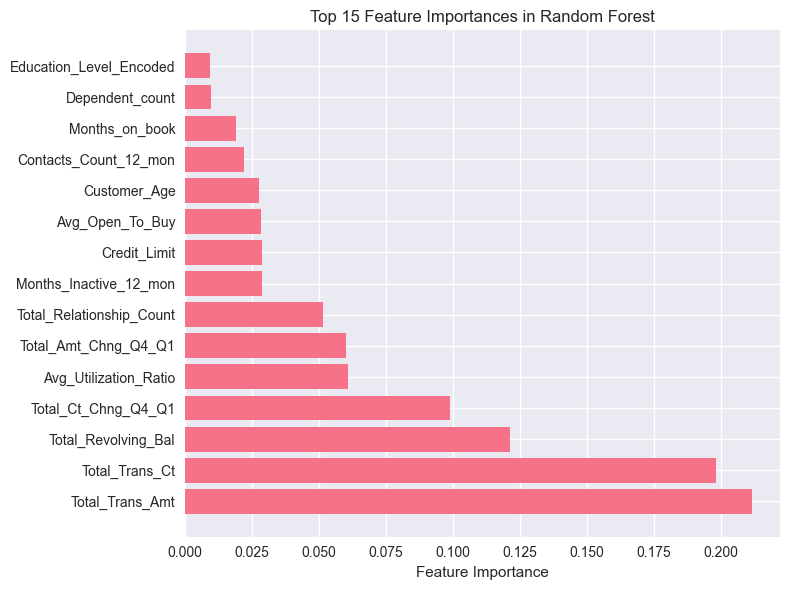

In [137]:

# ============================================================================
# 4. FEATURE IMPORTANCE ANALYSIS
# ============================================================================

print("\n" + "="*60)
print("4. FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

# Plot feature importance
plt.figure(figsize=(8, 6))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances in Random Forest')
plt.tight_layout()
plt.show()



5. CREATING VISUALIZATIONS


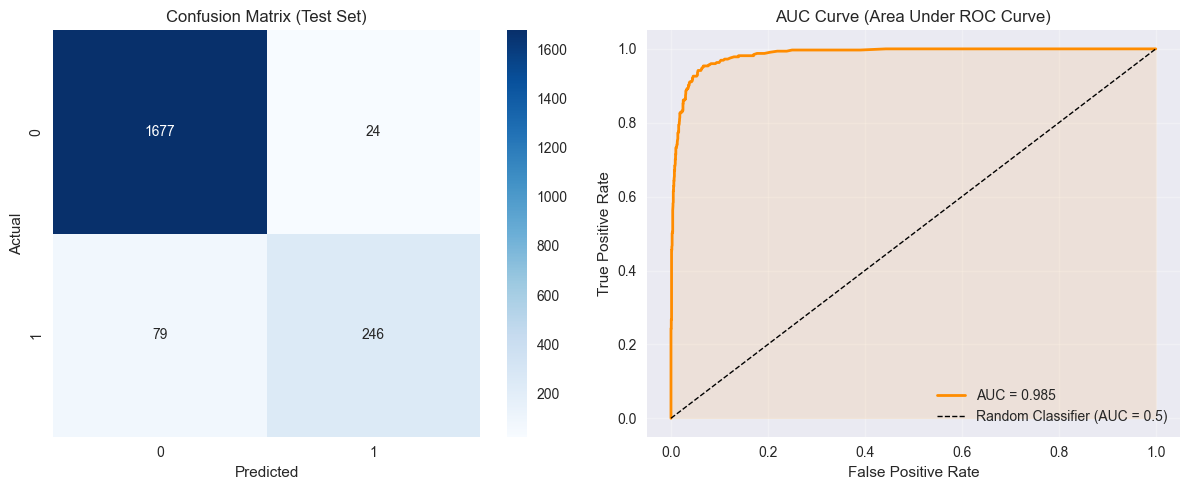

In [147]:

# ============================================================================
# 5. VISUALIZATION OF RESULTS
# ============================================================================

print("\n" + "="*60)
print("5. CREATING VISUALIZATIONS")
print("="*60)

# Create subplots for confusion matrix and AUC curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix (Test Set)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 2. AUC Curve (ROC Curve)
fpr, tpr, _ = roc_curve(y_test, y_test_proba_best)
auc_score = roc_auc_score(y_test, y_test_proba_best)
axes[1].plot(fpr, tpr, linewidth=2, label=f'AUC = {auc_score:.3f}', color='darkorange')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='darkorange')  # Fill area under curve
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('AUC Curve (Area Under ROC Curve)')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:

# ============================================================================
# 6. RANDOM FOREST SPECIFIC ANALYSIS
# ============================================================================

print("\n" + "="*60)
print("6. RANDOM FOREST SPECIFIC ANALYSIS")
print("="*60)

# Tree depth analysis
tree_depths = [tree.get_depth() for tree in best_rf.estimators_]
print(f"Average tree depth: {np.mean(tree_depths):.2f}")
print(f"Min tree depth: {np.min(tree_depths)}")
print(f"Max tree depth: {np.max(tree_depths)}")



# ============================================================================
# 7. MODEL INTERPRETATION
# ============================================================================

print("\n" + "="*60)
print("7. MODEL INTERPRETATION")
print("="*60)

# Model complexity
#Max tree depth here is the setting implemented, 20 is max of actual trees from the model
print(f"\nModel Complexity:")
print(f"  Number of trees: {best_rf.n_estimators}")
print(f"  Maximum tree depth boundary: {best_rf.max_depth}")
print(f"  Minimum samples per split: {best_rf.min_samples_split}")
print(f"  Minimum samples per leaf: {best_rf.min_samples_leaf}")



6. RANDOM FOREST SPECIFIC ANALYSIS
Average tree depth: 14.86
Min tree depth: 12
Max tree depth: 20

7. MODEL INTERPRETATION

Model Complexity:
  Number of trees: 150
  Maximum tree depth boundary: 25
  Minimum samples per split: 2
  Minimum samples per leaf: 4


In [ ]:

# ============================================================================
# 9. MODEL SUMMARY
# ============================================================================

print("\n" + "="*60)
print("9. MODEL SUMMARY")
print("="*60)

# Model summary
print("Final Random Forest Configuration:")
print(f"  Number of trees: {best_rf.n_estimators}")
print(f"  Max depth: {best_rf.max_depth}")
print(f"  Min samples split: {best_rf.min_samples_split}")
print(f"  Min samples leaf: {best_rf.min_samples_leaf}")
print(f"  Max features: {best_rf.max_features}")
print(f"  Bootstrap: {best_rf.bootstrap}")
print(f"  Class weight: {best_rf.class_weight}")

print(f"\nFinal Model Performance:")
print(f"  Test Accuracy: {accuracy_score(y_test, y_test_pred_best):.4f}")
print(f"  Test AUC: {roc_auc_score(y_test, y_test_proba_best):.4f}")

# Get churn-specific metrics
cm = confusion_matrix(y_test, y_test_pred_best)
tn, fp, fn, tp = cm.ravel()
churn_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
churn_recall = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"  Churn Precision: {churn_precision:.4f}")
print(f"  Churn Recall: {churn_recall:.4f}")



9. MODEL SUMMARY
Final Random Forest Configuration:
  Number of trees: 150
  Max depth: 25
  Min samples split: 2
  Min samples leaf: 4
  Max features: 0.7
  Bootstrap: True
  Class weight: {0: 1, 1: 8}

Final Model Performance:
  Test Accuracy: 0.8529
  Test AUC: 0.9173
  Churn Precision: 0.5268
  Churn Recall: 0.8154


### Model Comparisons

Original LogReg Model has:
Final Model Performance:
Training Accuracy: 0.8525
Validation Accuracy: 0.8376
Test Accuracy: 0.8529

Training AUC: 0.9300
Validation AUC: 0.9195
Test AUC: 0.9173

False Negative Rate: 2.96%

Tuned Model with optimal threshold for false negatives:
 Optimized Threshold (0.4774):
Test Accuracy: 0.6264
Test AUC: 0.8658
False Negatives: 31
False Positives: 726
Recall (Sensitivity): 0.9046
Precision: 0.2882

False Negative Rate: 1.53%- decreased to 31 from 60
False Positives increased from 238 to 726 or 11.75% to 48.13%

Changes made from original to tuned: custom class weight, optimized threshold, scoring = recall

Random Forest: 
Final Model Performance:
  Test Accuracy: 0.9492
  Test AUC: 0.9848
  Churn Precision: 0.9111
  Churn Recall: 0.7569

False Negative Rate: 3.89%
False Positive rate: 1.18%
